# Code Initialization

In [1]:
from qiskit import QuantumCircuit, transpile, QuantumRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer
# from qiskit_ibm_runtime import QiskitRuntimeService, Session, Sampler, Estimator, Options
from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options
from qiskit_ibm_runtime import Sampler, SamplerV2
from qiskit.visualization import plot_histogram
from qiskit.circuit.classical import expr

from datetime import datetime
import mysql.connector
import networkx as nx
import matplotlib.pyplot as plt
# plt.rcParams.update({'font.size': 14})

import numpy as np
import pandas as pd
import seaborn as sns
import re
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, reset_error,
    pauli_error, depolarizing_error, thermal_relaxation_error)
import json

from qiskit_ibm_runtime.fake_provider import fake_backend

import copy
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps
from qiskit.visualization import plot_circuit_layout

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RZZGate, RZGate, XGate, IGate
from qiskit.converters import circuit_to_dag, dag_to_circuit

from qiskit.transpiler.passes import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling, PadDelay
from qiskit.transpiler import PassManager
import numpy as np
from qiskit.qasm2 import dumps
from random import randint

import json
from qiskit_ibm_runtime import RuntimeEncoder, RuntimeDecoder

import mthree
import stim
import time


CB_color_cycle = [
    '#006BA4',  # Blue
    '#FF800E',  # Orange
    '#ABABAB',  # Gray
    '#595959',  # Dark Gray
    '#5F9ED1',  # Light Blue
    '#C85200',  # Dark Orange
    '#898989',  # Medium Gray
    '#A2C8EC',  # Pale Blue
    '#FFBC79',  # Light Orange
    '#CFCFCF',  # Light Gray
    '#009E73',  # Green (Colorblind-friendly)
    '#F0E442'   # Yellow (Colorblind-friendly)
]

CB_color_cycle_polar = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

markers = ['o', 'v', '^', 's', '+', '*', 'x', 'd', '<', '>', 'p']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':']

# MySQL connection parameters
mysql_config = {
    'user': 'handy',
    'password': 'handy',
    'host': 'localhost',
    'database': 'framework'
}

shots = 4000

mysql_config_online = {
    'user': 'handy',
    'password': 'handy',
    'host': 'ec2-16-171-135-24.eu-north-1.compute.amazonaws.com',
    'database': 'calibration_data'
}

import os
import sys

#module_path = os.path.abspath(os.path.join('..', 'functions'))
#if module_path not in sys.path:
#    sys.path.append(module_path)

from commons import (
    used_qubits, sum_middle_digits_dict
)

from commons import (Config, convert_utc_to_local, calculate_time_diff, get_count_1q, get_count_2q, 
    calculate_circuit_cost, get_correct_output_dict, calculate_success_rate_nassc, calculate_success_rate_tvd, 
    calculate_success_rate_polar, calculate_hellinger_distance, calculate_success_rate_tvd_new, 
    convert_to_json, is_mitigated, get_initial_mapping_json, normalize_counts, convert_dict_int_to_binary, reverse_string_keys, convert_dict_binary_to_int,
    sum_middle_digits_dict
)

from wrappers.multiprogramming_wrapper import (
    avoid_simultaneous_cnot, add_zz_on_simultaneous_cnot, 
    build_idle_coupling_map, multiprogram_compilation_qiskit, merge_circuits,
    get_LF_presets_cm
)
from wrappers.polar_wrapper import (
        polar_code_p2, get_logical_error_on_accepted_states, get_q1prep_sr, get_i_position, make_polar_qc_based_p2,
divide_half_list, get_q1prep_accepted_states
)

from wrappers.prune_wrapper import (
    create_full_graph, generate_figures, generate_node_errors, generate_edge_errors,
    get_latest_calibration_id, get_edges_threshold, get_readout_threshold, get_LF_qubits
)

from wrappers.dd_wrapper import (
    convert_dt_to_us, count_delay_durations, apply_pad_delay, get_delay_information, get_dd_information, 
    get_delay_and_dd_information_us
)

from wrappers.qiskit_wrapper import (
    apply_dd, get_zz_rates_from_backend_in_hz, get_qubits_T1_T2, get_gates_length, generate_errors_thermal_relaxation, 
generate_thermal_noise_model_on_used_qubits, get_neighbor_zz_rates_by_qubit, create_rzz_operator,
replace_delay_with_rzz, get_initial_layout_from_circuit
)

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

 
# # token = "476ea8c61cc54f36e4a21d70a8442f94203c9d87096eaad0886a3e8154d8c2e79bcad6f927c6050a76335dd68d783f478c1b828504748a4377b441c335c831aa"

# # # frisbee_among.0p@icloud.com
# # token = "04ede7f82299b792eae4daf3581f62415b3af676370f752f52d40e5851c7201d6e357c36e7bd55e4719c80d66bba7474412253f6c62f0ea7577bf056aa92eb62"

# # chores.acetone-0t@icloud.com
# token = "108bce3fd4c7a849d27b3eb41aad83f0c0a4f523cf6f3aa9735390405604613e51b9fc092722ef709554d9bb88a9dccd882eadeeadc590e554a8447fef8c8f97"
# QiskitRuntimeService.save_account(channel="ibm_quantum", token=token, overwrite=True)
# service = QiskitRuntimeService(channel="ibm_quantum", token=token)


# token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
# QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
# service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
service = QiskitRuntimeService()

hw_name = "ibm_marrakesh"
# hw_name = "ibm_sherbrooke"
backend = service.backend(hw_name)

from qiskit.circuit import IfElseOp
backend.target.add_instruction(IfElseOp, name="if_else")

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

## change later back to 3
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
)

def extract_z_syndrome(circuit, target, controls, measure):
    circuit.cx(controls[0], target)
    circuit.cx(controls[1], target)
    circuit.measure(target, measure)

    #with circuit.if_test((measure, True)):
    #    circuit.x(controls[0])

    #circuit.reset(target)

def extract_x_syndrome(circuit, target, controls, measure):
    circuit.h(target)
    circuit.cx(target, controls[0])
    circuit.cx(target, controls[1])
    circuit.h(target)
    circuit.measure(target, measure)





ModuleNotFoundError: No module named 'mthree'

In [ ]:
list_circuit_name = []
list_n = []
list_logical = []
polar_circuits = {}
polar_circuits_meas_data = {}
polar_circuits_x = {}
polar_circuits_x_meas_data = {}

print("-------- z -----------")
for i in range(3,7):
    list_circuit_name.append("polar_z_n{}".format(i))
    list_n.append(i)
    list_logical.append("0")
    polar_circuits[i] = (polar_code_p2(i, base="z"))
    polar_circuits_meas_data[i] = (polar_code_p2(i, meas_data=True, base="z"))
    #polar_circuits_x[i] = (polar_code_p2(i, base="x"))
    #polar_circuits_x_meas_data[i] = (polar_code_p2(i, meas_data=True, base="x"))

print("-------- x -----------")
for i in range(3,7):
    list_circuit_name.append("polar_x_n{}".format(i))
    list_n.append(i)
    list_logical.append("+")
    #polar_circuits[i] = (polar_code_p2(i, base="z"))
    #polar_circuits_meas_data[i] = (polar_code_p2(i, meas_data=True, base="z"))
    polar_circuits_x[i] = (polar_code_p2(i, base="x"))
    polar_circuits_x_meas_data[i] = (polar_code_p2(i, meas_data=True, base="x"))

-------- z -----------
n = 3 , b = 110 (3) , i = 4
n = 3 , b = 110 (3) , i = 4
n = 4 , b = 0110 (6) , i = 7
n = 4 , b = 0110 (6) , i = 7
n = 5 , b = 11100 (7) , i = 8
n = 5 , b = 11100 (7) , i = 8
n = 6 , b = 011010 (22) , i = 23
n = 6 , b = 011010 (22) , i = 23
-------- x -----------
n = 3 , b = 010 (2) , i = 3
n = 3 , b = 010 (2) , i = 3
n = 4 , b = 1010 (5) , i = 6
n = 4 , b = 1010 (5) , i = 6
n = 5 , b = 01100 (6) , i = 7
n = 5 , b = 01100 (6) , i = 7
n = 6 , b = 101010 (21) , i = 22
n = 6 , b = 101010 (21) , i = 22


In [ ]:
def create_line_chart_combined(data, y, opt_values, metric, ax, type, ylabel, xlabel, yticks = None, 
                      y_bot = None, y_top = None, figsize = (12,8), c_idx = 0, reindex = None, 
                               x_index = "header_id", x_labels = [], i=0, hw_name = "", total_data = 0, log_val=False):
    tmp = ()
    
    for idx, opt in enumerate(opt_values):
        # print(idx, opt)
        idx_marker = idx + (len(opt_values) * i)
        # idx = idx 
        pivot = pd.pivot_table(data[data[y] == opt], 
                               values=[metric], 
                               index=x_index, 
                               columns=y, 
                               aggfunc='mean')    

        if len(pivot) == 0:
            continue

        # if hw_name == "brisbane" and opt == "na_triq_lcd" and i == 2:
        #     continue
        
        if reindex != 0:
            if reindex is None:
                if len(tmp) == 0:
                    tmp = pivot.index
                else:
                    pivot = pivot.reindex(tmp)
            else:
                pivot = pivot.reindex(reindex)

        idx_color = (idx % (len(markers)))
        # print(idx_color, idx, len(markers), idx_marker)

        # print (pivot)
         
        pivot.plot(kind='line', color=CB_color_cycle_polar[i], marker=markers[idx], linestyle=linestyles[idx], figsize=figsize, ax=ax)

        mean= pivot.mean().mean()

    if i == total_data-1:
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        
    
        if yticks is not None:
            ax.set_yticks(yticks)
    
        if y_bot is not None and y_top is not None:
            ax.set_ylim(bottom= y_bot, top= y_top)
    
        if x_labels is not None:
            ax.set_xticks(np.arange(len(x_labels)))
            ax.set_xticklabels(x_labels)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

        if log_val:
            ax.set_yscale("log")
    
        ax.grid()


In [ ]:
def show_figure_by_opt_combined(dfs, y, y_values, metric, ylabel, xlabel, legend = None, legends = None, figsize=(10,6), reindex=None, 
                             x_index = "total_2q", x_labels = [], x_lim = [1, 100],
                            y_lim = [0,1], title=None, legend_position=None, circuit_name = "", hw_name = "",
                               log_val = False):
    # y_values = noise_levels

    metrics = [metric]
    row = 1
    col = 1

    fig, ax = plt.subplots(nrows=row, ncols=1)

    yticks = None
    
    for i in range(len(dfs)):
        # print(i)
        create_line_chart_combined(dfs[i], y, y_values, metrics[0], ax, y, ylabel, xlabel, yticks, 
                                   figsize=figsize, reindex=reindex,
                          x_index = x_index, x_labels=x_labels, i=i, hw_name=hw_name, total_data=len(dfs), log_val=log_val)

    # n=[]        
    # n.append(ax.axhline(np.NaN, color="gray", linestyle='-.'))

    # l1 = ax.legend(n, ["Mean"], loc=[0.82, 0.49])

    if legend is None:
            l2 = plt.legend()
    else:
        if legend_position == None:
            l2 = plt.legend(legends)
        else:
            l2 = plt.legend(legends, loc = legend_position)
    
    # plt.tight_layout()
    # ax.add_artist(l1)
    # plt.xticks(range(3,6))
    plt.xlim(x_lim) 
    plt.ylim(y_lim)
    plt.title(title)
    plt.savefig("./output/proposal_1/simulation/{}_{}_{}.png".format(circuit_name, hw_name, x_index), dpi=500, bbox_inches='tight')
    plt.show()
    
    return plt

In [ ]:
def save_results_to_file(result_type, job_ids, service):
    for job_id in job_ids:
        job = service.job(job_id)
        result = job.result()
        
        with open(f"output/proposal_1/result_{result_type}_{job_id}.json", "w") as file:
            json.dump(result, file, cls=RuntimeEncoder)

def load_results_from_file(result_type):
    folder_path = f'output/proposal_1/'
    files = [f for f in os.listdir(folder_path) if f.startswith(f"result_{result_type}_")]
    results = []

    for file_name in files:
        with open(f"output/proposal_1/{file_name}", "r") as file:
            result = json.load(file, cls=RuntimeDecoder)

        results.append(result)

    return results

def save_result_to_file(result, hw_name, circuit_name, exp_type, error_scale, seed_simulator):
    with open(f"output/proposal_1/simulation/{hw_name}/{circuit_name}_{exp_type}_{error_scale}_{seed_simulator}.json", "w") as file:
        json.dump(result, file, cls=RuntimeEncoder)

def load_results_simulations_from_file(hw_name, circuit_name, exp_type, error_scale):
    folder_path = f'output/proposal_1/simulation/{hw_name}/'
    files = [f for f in os.listdir(folder_path) if f.startswith(f"{circuit_name}_{exp_type}_{error_scale}")]
    results = []

    for file_name in files:
        with open(f'output/proposal_1/simulation/{hw_name}/{file_name}', "r") as file:
            result = json.load(file, cls=RuntimeDecoder)

        results.append(result)

    return results




In [ ]:
def generate_circuit_extraction_syndrome(k, meas_type, x_first = False):
    num_qbits = (2**k) + (2**(k-1))
    num_cbits = 2**(k-1)

    qc = QuantumCircuit(num_qbits, num_cbits)

    data_qubits = []
    ancillas = []
    for i in range(2**(k-1)):
        ancillas.append(i *3 + 2)

    for i in range(num_qbits):
        if i not in ancillas:
            data_qubits.append(i)

    d1, d2 = divide_half_list(data_qubits)
    #print(d1,d2, ancillas)

    for idx in range(len(d1)):

        if meas_type.lower() == "x":

            if x_first:
                qc.h(d1[idx])
                qc.cx(d1[idx], d2[idx])
            else:
                qc.h(ancillas[idx])
                qc.cx(ancillas[idx], d1[idx])
                qc.cx(ancillas[idx], d2[idx])
                qc.h(ancillas[idx])
                
                # qc.measure(ancillas[idx], idx)
                # qc.reset(ancillas[idx])

        elif meas_type.lower() == "z":
            qc.cx(d1[idx], ancillas[idx])
            qc.cx(d2[idx], ancillas[idx])

            # qc.measure(ancillas[idx], idx)
            # qc.reset(ancillas[idx])
    
    return qc

qc_x1 = generate_circuit_extraction_syndrome(1, "x", False)
qc_x1_first = generate_circuit_extraction_syndrome(1, "x", True)
qc_x2 = generate_circuit_extraction_syndrome(2, "x")
qc_x3 = generate_circuit_extraction_syndrome(3, "x")
qc_x4 = generate_circuit_extraction_syndrome(4, "x")
qc_x5 = generate_circuit_extraction_syndrome(5, "x")

qc_z2 = generate_circuit_extraction_syndrome(2, "z")
qc_z3 = generate_circuit_extraction_syndrome(3, "z")
qc_z4 = generate_circuit_extraction_syndrome(4, "z")
qc_z5 = generate_circuit_extraction_syndrome(5, "z")



#qc_x2.draw("mpl")



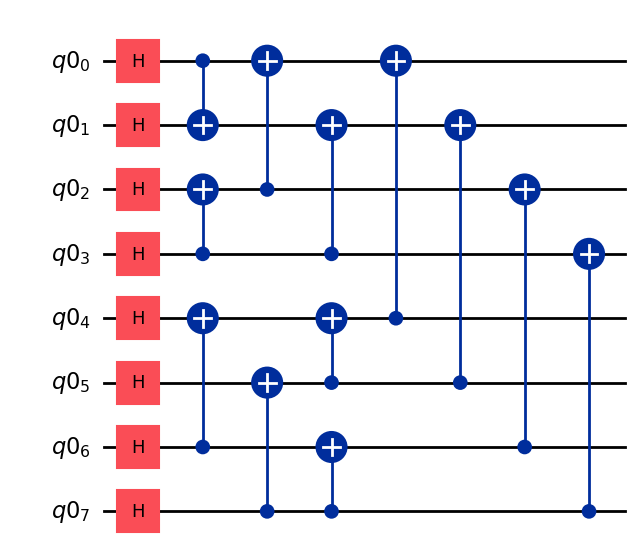

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister
import numpy as np

def encode_qrm(qc, qubits, m, r):
    """
    Recursive QRM encoding: (u+v, u)
    qubits: list of qubits to encode
    m: number of levels (log2(N))
    r: order of the RM code
    """
    N = 2**m
    if r == 0:
        # repetition code: all qubits same as first
        for i in range(1, N):
            qc.cx(qubits[0], qubits[i])
        return

    if r == m:
        # full space: apply "butterfly" CNOTs (same as encode_mm_code)
        k = N // 2
        while k > 0:
            for j in range(0, N, 2*k):
                for i in range(k):
                    qc.cx(qubits[j + k + i], qubits[j + i])
            k //= 2
        return

    # recursive case (u+v, u)
    N_half = N // 2
    encode_qrm(qc, qubits[:N_half], m-1, r-1)    # v part
    encode_qrm(qc, qubits[N_half:], m-1, r)      # u part
    # XOR left half with right half (u+v)
    for i in range(N_half):
        qc.cx(qubits[N_half + i], qubits[i])

# Example usage
m = 3
r = 2
N = 2**m
qr = QuantumRegister(N)
qc = QuantumCircuit(qr)

# Prepare input logical qubits in |+> (superposition)
for i in range(N):
    qc.h(qr[i])

encode_qrm(qc, qr, m, r)

qc.draw("mpl")


# Optimizing factory-based approach of state preparation of quantum polar code by using Dynamic Circuits

## Motivation

- The control-flow operation (IfElseOp) can be used to reduce number of gates depends on the previous mid-circuit measurement results.
- In the state preparation of quantum polar code, by using the error detection gadget, we could skip gates if error is detected
- Skipping gates also reduce the usage of quantum resources (iif dynamic circuit speed has been improved)



## Goal

- Reducing the usage of quantum and classical resources while maintaining the preparation rate and logical error rate

## Hyphotheses

1. By skipping gates if an error is detected will reduce the usage of quantum resource.
2. Using classical bits (cbits) as a flag can reduce the classical resource usage as discarding the flagged measurement result.


### Hyphothesis 1: Reducing the Quantum Resource

__NOTE: based on the information here (https://docs.quantum.ibm.com/announcements/product-updates/2025-03-03-new-version-dynamic-circuits)__

To accelerate the rollout, we have deprecated the following capabilities:
- The `while`, `for`, and `switch` control flow constructs
- The ability to use control flow instructions inside the body of a branch (as in, nested control flow)
- Conditional measurements

#### Goal

__To reduce the usage of quantum resource by skipping gates if an error is detected at earlier stage__

#### Metric

1. Number of Operations 
2. Quantum Resource usage (simulation + real hardware)
3. Preparation rate + logical error rate


### Hyphothesis 2: Reducing the Classical Resource

#### Goal

__To reduce the usage of classical resource by skipping flagged measurement result__

#### Metric

1. Detection time
2. Decoding time


## Methodology

### Circuit Synthesize

As in our case, we initialized all the qubits in |0>, we can simplify the first layer from:


In [8]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

qc.cx(0,2)
qc.cx(1,2)

qc.measure(2,0)

qc.draw("mpl").savefig("./output/proposal_1/syndrome_zz.png", dpi=300, bbox_inches='tight')

In [9]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

qc.h(2)
qc.cx(2,0)
qc.cx(2,1)
qc.h(2)

qc.measure(2,0)

qc.draw("mpl").savefig("./output/proposal_1/syndrome_xx.png", dpi=300, bbox_inches='tight')

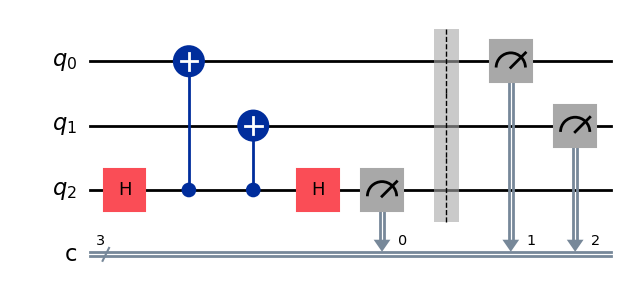

In [10]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

for i in range(1):
    start = i * 3 
    qc.append(qc_x1, range(start, start + 3), [i])

qc.measure(2,0)
qc.barrier()
qc.measure(0,1)
qc.measure(1,2)

qc.decompose().draw("mpl")

if $q_2$ is measured in $|0\rangle$, then qubits $q_0$, and $q_1$ will be in $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$, otherwise it would be $|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$.



In [11]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'000': 1007, '111': 1046, '001': 965, '110': 982}

As all qubits are initialized in $|0\rangle$, we can modify the circuit with mid-circuit measurement and feed-forward control

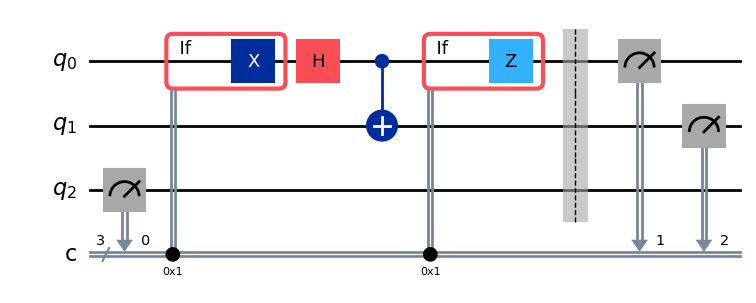

In [12]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

qc.measure(2,0)

with qc.if_test((creg,1)) as else_:
    qc.x(0)

qc.h(0)
qc.cx(0,1)
with qc.if_test((creg,1)) as else_:
    qc.z(0)

qc.barrier()
qc.measure(0,1)
qc.measure(1,2)
qc.draw("mpl")



In [13]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'110': 2023, '000': 1977}

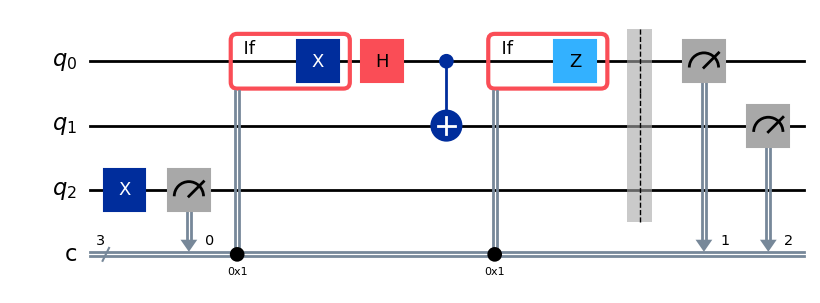

In [14]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

qc.x(2)
qc.measure(2,0)

with qc.if_test((creg,1)) as else_:
    qc.x(0)

qc.h(0)
qc.cx(0,1)
with qc.if_test((creg,1)) as else_:
    qc.z(0)

qc.barrier()
qc.measure(0,1)
qc.measure(1,2)
qc.draw("mpl")



In [15]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count

{'001': 1974, '111': 2026}

The result are the same it differs only by the global phase if the measurement of $q_2 = 1$.

Now, to simplify this more, as we now that all the qubits are initialized in $|0\rangle$, we can change the circuit to:

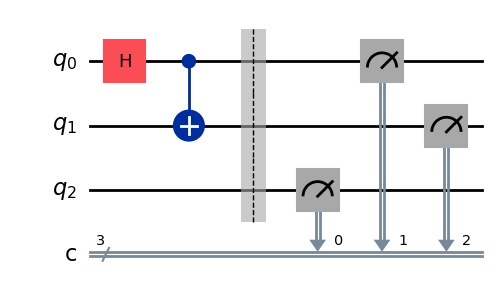

In [16]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

qc.h(0)
qc.cx(0,1)

qc.barrier()
qc.measure(2,0)
qc.measure(0,1)
qc.measure(1,2)
qc.draw("mpl")

In [17]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count

{'000': 1981, '110': 2019}

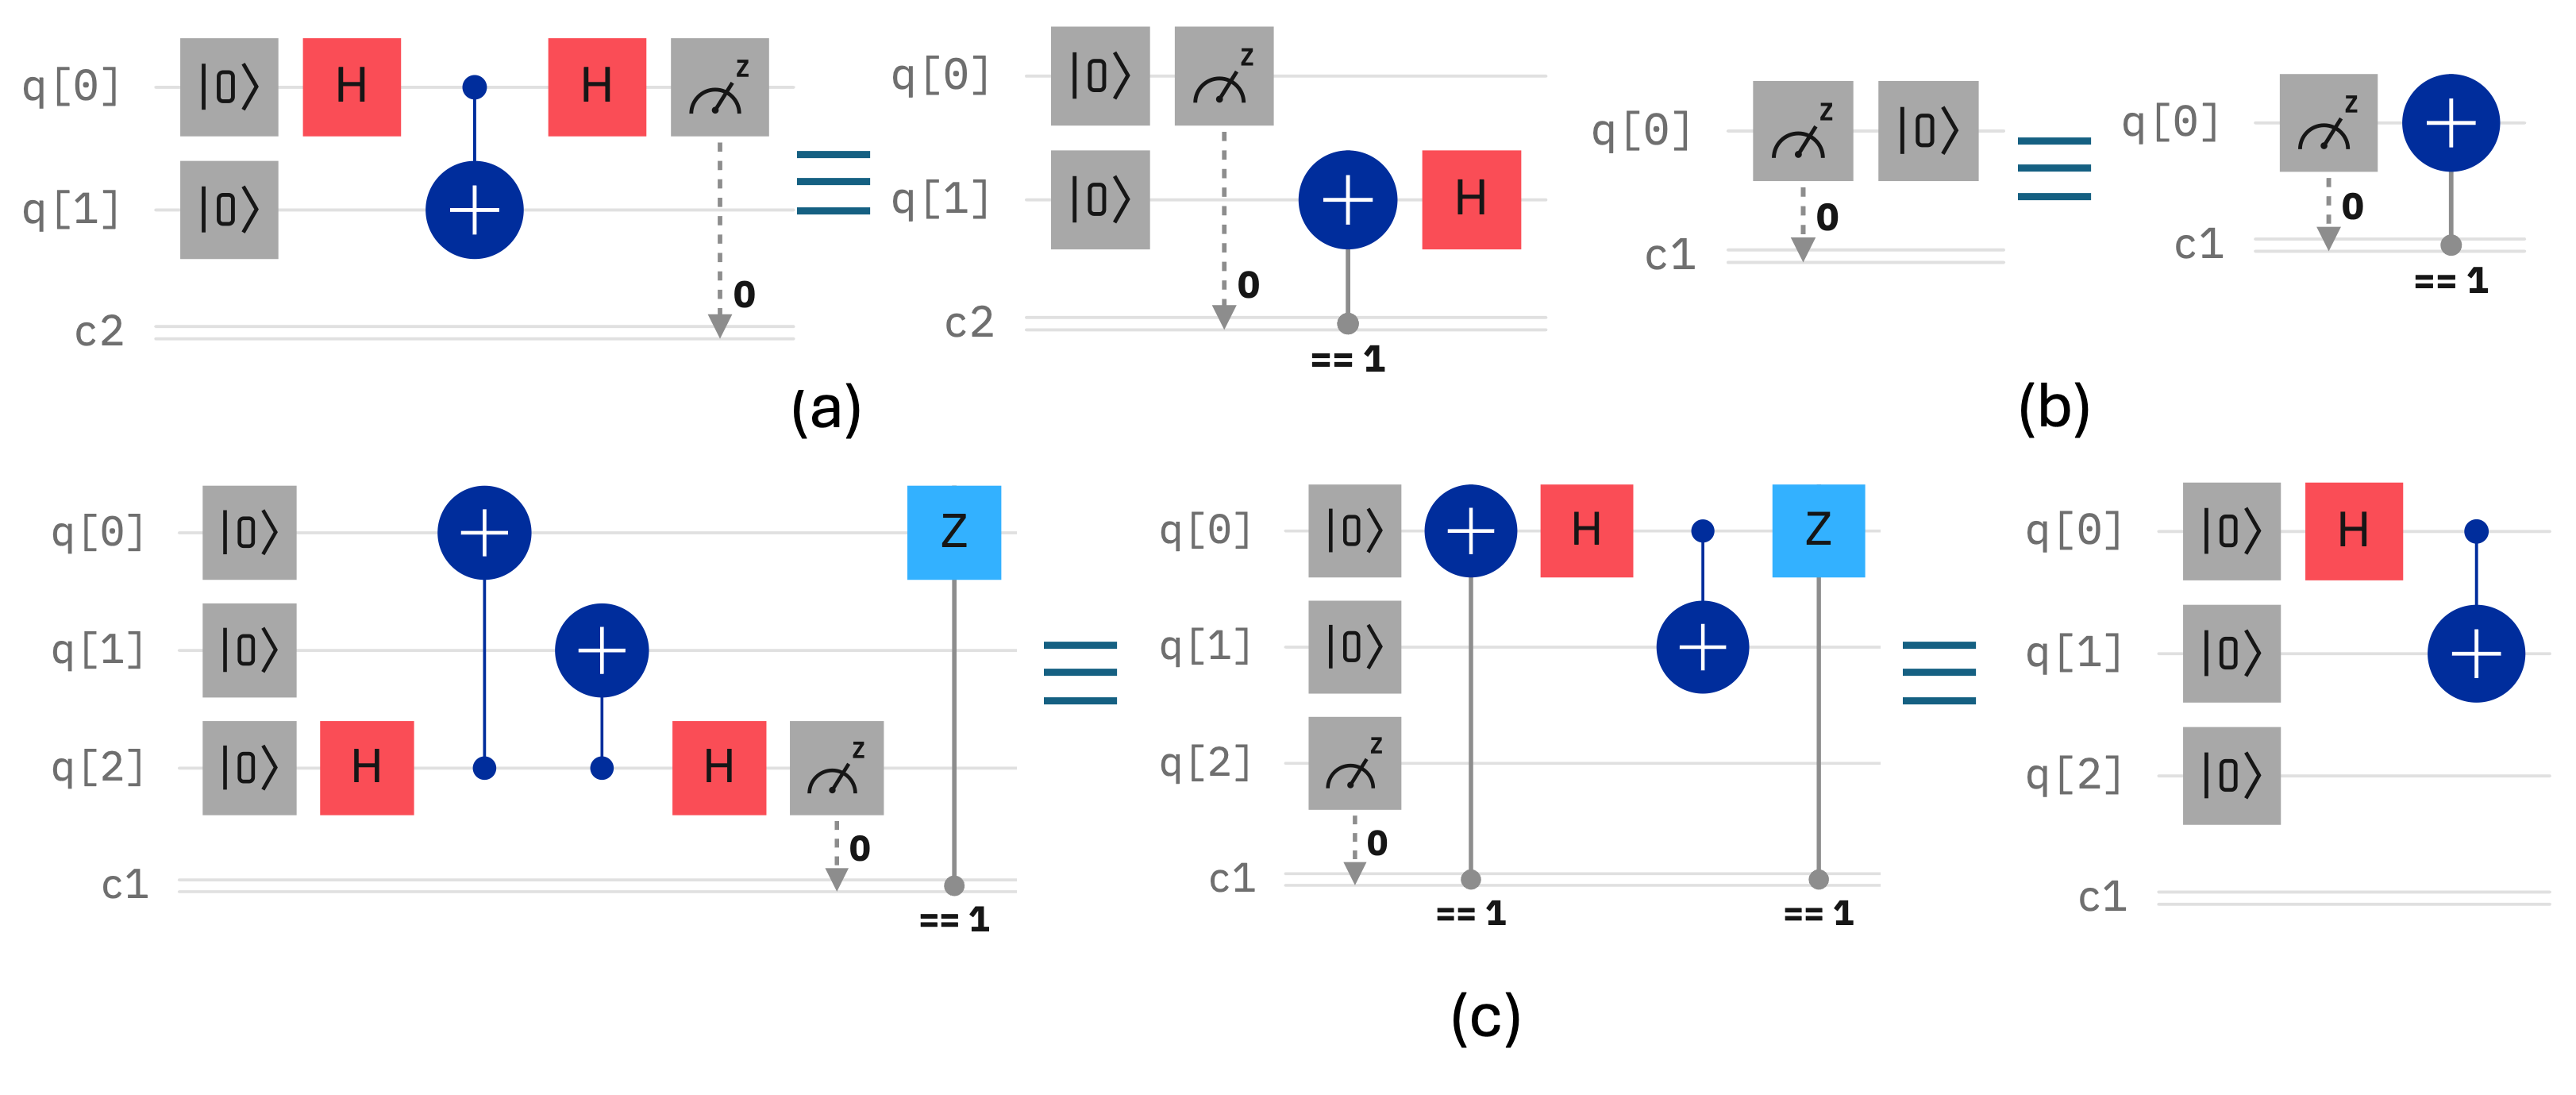

The goal of this approach is:
- to simplify the variance in the entanglement
- to reduce the number of gates and operation as the error rate at the first layer is small

### Quantum Circuit

In [18]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(2, name="c")
qc = QuantumCircuit(qreg,creg)

qc.h(0)
qc.cx(0,1)
qc.cx(1,2)
qc.cx(0,1)
qc.h(0)
qc.measure([0, 2], [0, 1])
qc.draw("mpl").savefig("./output/proposal_1/classical_circuit.png", dpi=300, bbox_inches='tight')


In [19]:
qreg = QuantumRegister(3, name="q")
mid = ClassicalRegister(1, name="mid")
creg = ClassicalRegister(1, name="c")
qc = QuantumCircuit(qreg, mid, creg)

qc.h(0)
qc.measure([0], [0])
qc.reset(0)

with qc.if_test((mid,1)) as else_:
    qc.x(2)

qc.h(2)

qc.measure([2], [1])

qc.draw("mpl").savefig("./output/proposal_1/dynamic_circuit.png", dpi=300, bbox_inches='tight')


### Error Detection

As the correct states have been known, we can detect if there is an error from the syndrome extraction circuit.

For example with this circuit, it has both z-syndrome extraction and x-syndrome extraction.

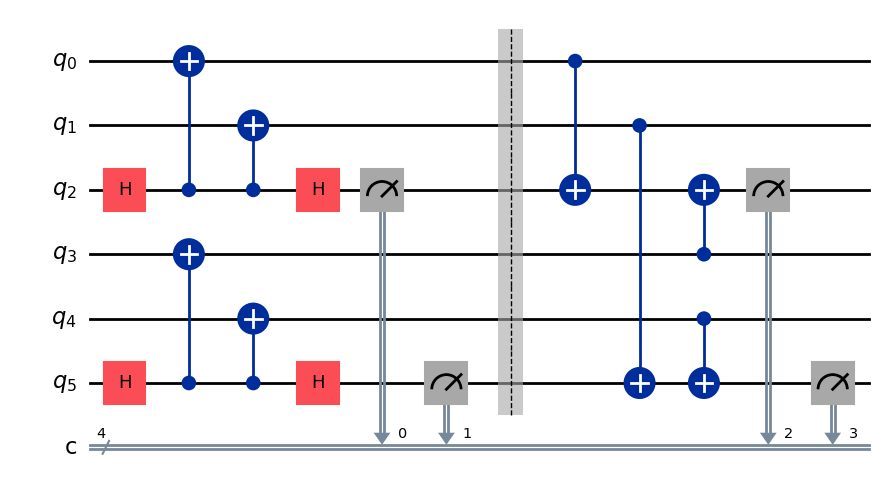

In [20]:
qreg = QuantumRegister(6, name="q")
creg = ClassicalRegister(4, name="c")
qc = QuantumCircuit(qreg,creg)

for i in range(2):
    start = i * 3 
    qc.append(qc_x1, range(start, start + 3), [i])


qc.measure(2,0)
qc.measure(5,1)

qc.barrier()

qc.append(qc_z2, range(6), range(2))

qc.measure(2,2)
qc.measure(5,3)

qc.decompose().draw("mpl")


In [21]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'1111': 497,
 '0110': 530,
 '0101': 488,
 '1100': 524,
 '1001': 492,
 '0000': 540,
 '1010': 468,
 '0011': 461}

In this case we can apply this simplification from the "Circuit Synthesize" to the circuit above:

In [22]:
qreg = QuantumRegister(7, name="q")
creg = ClassicalRegister(2, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg, mid)

for i in range(2):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])


qc.barrier()

qc.append(qc_z2, range(6), range(2))

qc.measure(2,0)
qc.measure(5,1)

qc = qc.decompose()

expr_1 = expr.not_equal(creg[0], creg[1])
with qc.if_test(expr_1) as else_:
    qc.x(6)
with else_:
    qc.id(0)

# with the new update from IBM, measurement inside the control-flow is not possible
qc.measure(6,mid)
qc.reset(6)
    
qc.draw("mpl").savefig("./output/proposal_1/qc_error_detection.png", dpi=300, bbox_inches='tight')

In [23]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'0 00': 2004, '0 11': 1996}

So, the possible outcome in the absence of noise from the above entangled states are either "00" or "11". So, if we simulate them on the noisy simulator we will have:

In [24]:
tqc = pm.run(qc)
result = sim_noisy.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'0 01': 1,
 '1 00': 15,
 '1 10': 137,
 '1 01': 139,
 '0 10': 2,
 '0 00': 1842,
 '1 11': 13,
 '0 11': 1851}

So, know we can determine if the result that we get other than "00" and "11", there will be some error somewhere along the circuit.



#### Generalized Error Detection

In [25]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# # Example data
# cases = ['n=3,log0', 'n=4,log0', 'n=5,log0', 'n=3,log+', 'n=4,log+', 'n=5,log+']
# methods = ['Normal', 'Dynamic']
# adjusted_time = [120, 150, 180, 100, 130, 160, 60, 80, 90, 40, 50, 70]  # just an example
# accepted_states = [500, 600, 700, 450, 550, 650, 480, 580, 680, 460, 560, 660]

# # Create DataFrame
# df = pd.DataFrame({
#     'Case': cases * 2,
#     'Method': ['Normal'] * 6 + ['Dynamic'] * 6,
#     'Adjusted_Time': adjusted_time,
#     'Accepted_States': accepted_states
# })

# # Scatter plot
# plt.figure(figsize=(8, 6))
# sns.scatterplot(data=df, x='Adjusted_Time', y='Accepted_States',
#                 hue='Method', style='Case', s=100)

# # # Ideal region marker
# # plt.axhline(y=max(df['Accepted_States']) * 0.8, color='gray', linestyle='--')
# # plt.axvline(x=min(df['Adjusted_Time']) * 1.2, color='gray', linestyle='--')

# plt.title('Performance Comparison: Adjusted Time vs Accepted States')
# plt.xlabel('Adjusted Time (lower is better)')
# plt.ylabel('Accepted States (higher is better)')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()


## Implementation

### Experimental Setup

- Backend: __ibm_sherbrooke__ (v.1.6.112 as of 22 June 2025)
- Shots: __5000__
- Connectivity: __2/3__
- Circuits: __State preparation of Quantum Polar Code__

Error rates:
- 2Q error (best) : 2.33e-3
- 2Q error (layered) : 1.43e2
  

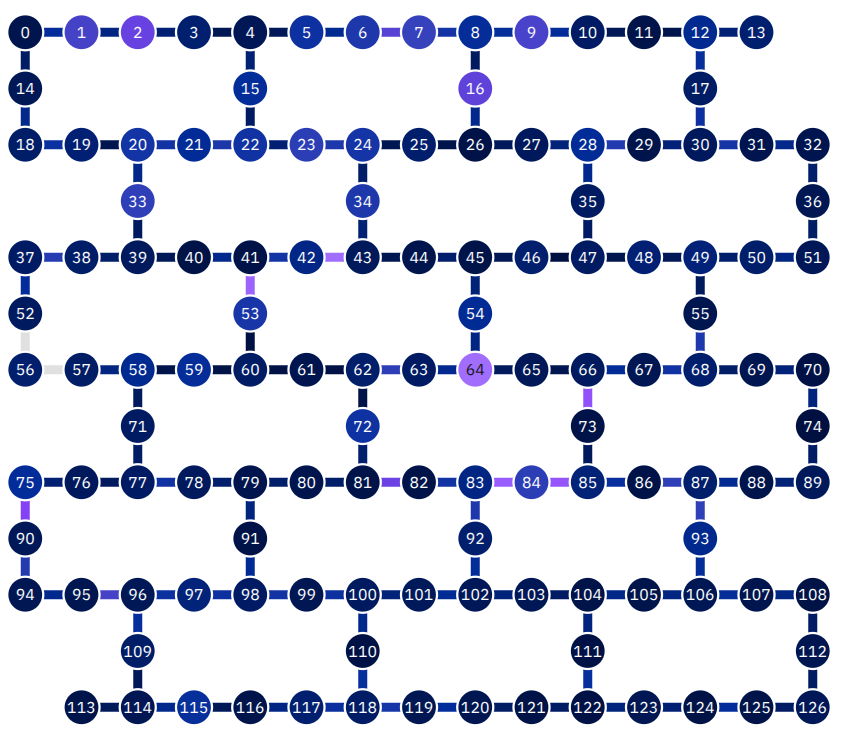

### $n=3$, $i=4$ for logical $|0\rangle$, b = 110


0 2
1 5
2 8
3 11


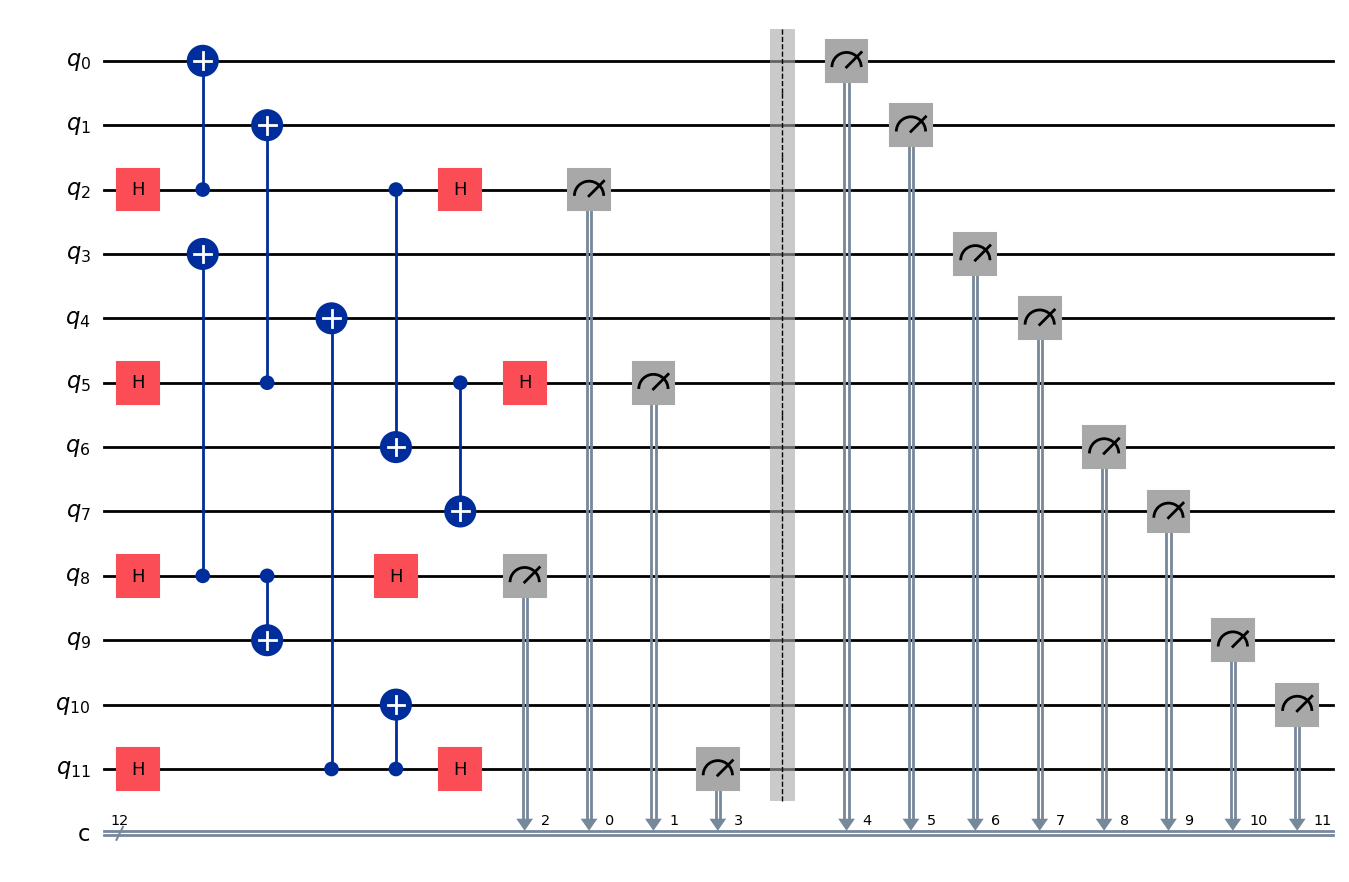

In [26]:
# polar_n3_z_meas_data = polar_code_p2(3, True, "z", True)
# polar_n3_z_meas_data.draw("mpl", fold=-1)

qreg = QuantumRegister(12, name="q")
creg = ClassicalRegister(12, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg)

for i in range(1):
    start = i * 3 
    qc.append(qc_x3, range(12), [8,9,10,11])

m_idx = 0
for offset, qb in enumerate(range(2, 12, 3)): 
    print(offset, qb)
    qc.measure(qb, m_idx + offset)

qc.barrier()

qc = qc.decompose()

m_idx = 4
for i in range(12):
    if i in [2,5,8,11]:
        continue

    # qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

polar_n3_z_meas_data = qc
polar_n3_z_meas_data.draw("mpl", fold=-1)

For this code length, as it is started with two one's (ZZ measurement) at the beginning, it will give the result close to 100% of preparation rate. So, for both cases before and after will be a little difference. But, applying the simplification will reduce the number of gates (CNOT, measurement and reset)

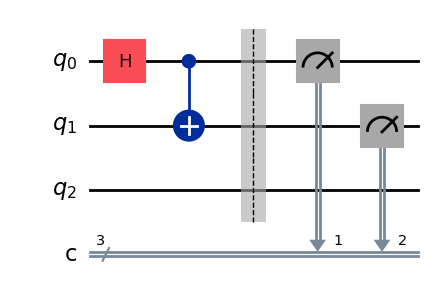

In [27]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg)

for i in range(1):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

qc.barrier()

qc = qc.decompose()

m_idx = 1
for i in range(2):
    if i in [2,5,8,11]:
        continue

    # qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

qc_dynamic_n3_z = qc
qc_dynamic_n3_z.draw("mpl", fold=-1)

#### Metric: Number of Operations

In [28]:
polar_n3_z_meas_data.count_ops()

OrderedDict([('measure', 12), ('h', 8), ('cx', 8), ('barrier', 1)])

In [29]:
qc_dynamic_n3_z.count_ops()

OrderedDict([('measure', 2), ('h', 1), ('cx', 1), ('barrier', 1)])

With the technique above, we will save:
- 4 measure gates
- 4 cnot gates
- 4 reset gates
- 4 hadamard gates

#### Metric: Quantum Resources

In [30]:
def convert_dict_to_list(source_dict):
    result = []
    for key, value in source_dict.items():
        for i in range(value):
            result.append(key)

    return result

In [31]:
def run_simulation_n3(qc, shots, sim, seed_simulator):
    tqc = pm.run(qc)
    tmp_start_time  = time.perf_counter()
    result = sim.run(tqc, shots = shots, seed_simulator=seed_simulator).result()
    tmp_end_time = time.perf_counter()
    sim_time = tmp_end_time - tmp_start_time
    print("Simulation time: {} seconds".format(sim_time))

    count = result.get_counts()
    
    return count, sim_time

seed_simulator = randint(1, 9999999)
shots = 50
seed_simulator

res_normal_ideal = run_simulation_n3(polar_n3_z_meas_data, shots, sim_ideal, seed_simulator)

n = 3
lstate = "Z"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_normal_ideal[0])


print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal, 1 - ler)


Simulation time: 0.0027398800011724234 seconds
50 0 0 1.0 0.004881810018559918 -0.0007520600047428161 0.0


In [32]:
tqc_h1s = [] 

tmp = pm.run(qc_dynamic_n3_z)
tqc_h1s.append(tmp)
print(tmp.count_ops())
# print(get_initial_layout_from_circuit(tmp))

used_qbts = get_initial_layout_from_circuit(tmp)

for i in range(3):

    # used_qbts = used_qubits(tqc_h1_1)
    

    cm = backend.coupling_map
    cm = build_idle_coupling_map(cm, used_qbts)

    pm_3 = generate_preset_pass_manager(
            optimization_level=3, backend=backend, coupling_map=cm
        )
    tmp = pm_3.run(qc_dynamic_n3_z)
    tqc_h1s.append(tmp)

    # print(tmp.count_ops())
    # print(get_initial_layout_from_circuit(tmp))

    qbts = get_initial_layout_from_circuit(tmp)

    for q in qbts:
        used_qbts.append(q)

print(used_qbts)


OrderedDict({'rz': 9, 'sx': 5, 'measure': 2, 'ecr': 1, 'barrier': 1})
[71, 58, 0, 4, 3, 0, 8, 7, 0, 12, 11, 0]


/tmp/ipykernel_1663056/854963251.py:18: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm_3 = generate_preset_pass_manager(


In [33]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n3_z_meas_data)
# # tqc_h1_1 = pm_1.run(qc_h1)
# # tqc_h1_2 = pm_2.run(qc_h1)

# pubs_1 = [tqc_1]
# pubs_2 = tqc_h1s

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options,
#              )
# sampler = Sampler(mode=backend, options=options)
# # sampler.options.experimental = {"execution_path" : "gen3-experimental"}
# job = sampler.run(pubs_1)
# print(job.job_id(), hw_name)

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [34]:


# job_ids = ["d20bshs3s4ss73ckvv0g", "d20bt543s4ss73ckvvi0", "d20btiklir9s73ahq0ug"]

# # save_results_to_file("n3_z_normal", job_ids, service)
# save_results_to_file("n3_z_dynamic", job_ids, service)

In [35]:
# 23 July 2025
# d209dnrni11c73fcenh0 ibm_brisbane normal -- saved
# d209doclir9s73ahnmjg ibm_brisbane dynamic -- saved

# d209rcbni11c73fcf400 ibm_brisbane normal -- saved
# d209rcjni11c73fcf410 ibm_brisbane dynamic -- saved

# d20a083ni11c73fcf8dg ibm_brisbane normal -- saved
# d20a08clir9s73aho7kg ibm_brisbane dynamic -- saved

# ---------------------------------------

# d20bshk3s4ss73ckvv00 ibm_sherbrooke normal (9s)
# d20bshs3s4ss73ckvv0g ibm_sherbrooke dynamic (7s)

# d20bt4k3s4ss73ckvvhg ibm_sherbrooke normal (5s)
# d20bt543s4ss73ckvvi0 ibm_sherbrooke dynamic (7s)

# d20bticlir9s73ahq0u0 ibm_sherbrooke normal (9s)
# d20btiklir9s73ahq0ug ibm_sherbrooke dynamic (7s)

result = load_results_from_file("n3_z_normal")[0]
res_1 = result[0].data.c.get_counts()

new_res = {}
for key, values in res_1.items():
    new_key = key[-12:]
    
    new_res[new_key] = values    

n = 3
lstate = "Z"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, new_res)

print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)


count_memory = []
result = load_results_from_file("n3_z_dynamic")[0]

for i in range(4):
    res_1 = result[i].join_data().get_counts()
    list_res_1 = convert_dict_to_list(res_1)

    count_memory.append(list_res_1)


shots = 5000

final_combined_states = {}
for idx in range(shots):
    keys = []

    for i in range(4): # this is the number of repeating
        keys.append(count_memory[i][idx])

    new_key = ""
    for idx in range(3): # this is the number of measurement each circuit
        idx = idx + 1

        for key in keys:
            new_key =  key[-idx] + new_key

    if new_key in final_combined_states:
        final_combined_states[new_key] = final_combined_states[new_key] + 1
    else:
        final_combined_states[new_key] = 1


n = 3
lstate = "Z"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)


5000 1932 1825 0.6136 0.12629437699797563 0.07424258402897976
5000 292 165 0.9416 0.001057587011018768 0.00024404999567195773


### $n=3$, $i=4$ for logical $|+\rangle$, b = 010

Here we have a circuit for Q1 State Preparation Quantum Polar Code with $n=3$, $i=4$ for logical $|+\rangle$

n = 3 , b = 010 (2) , i = 3


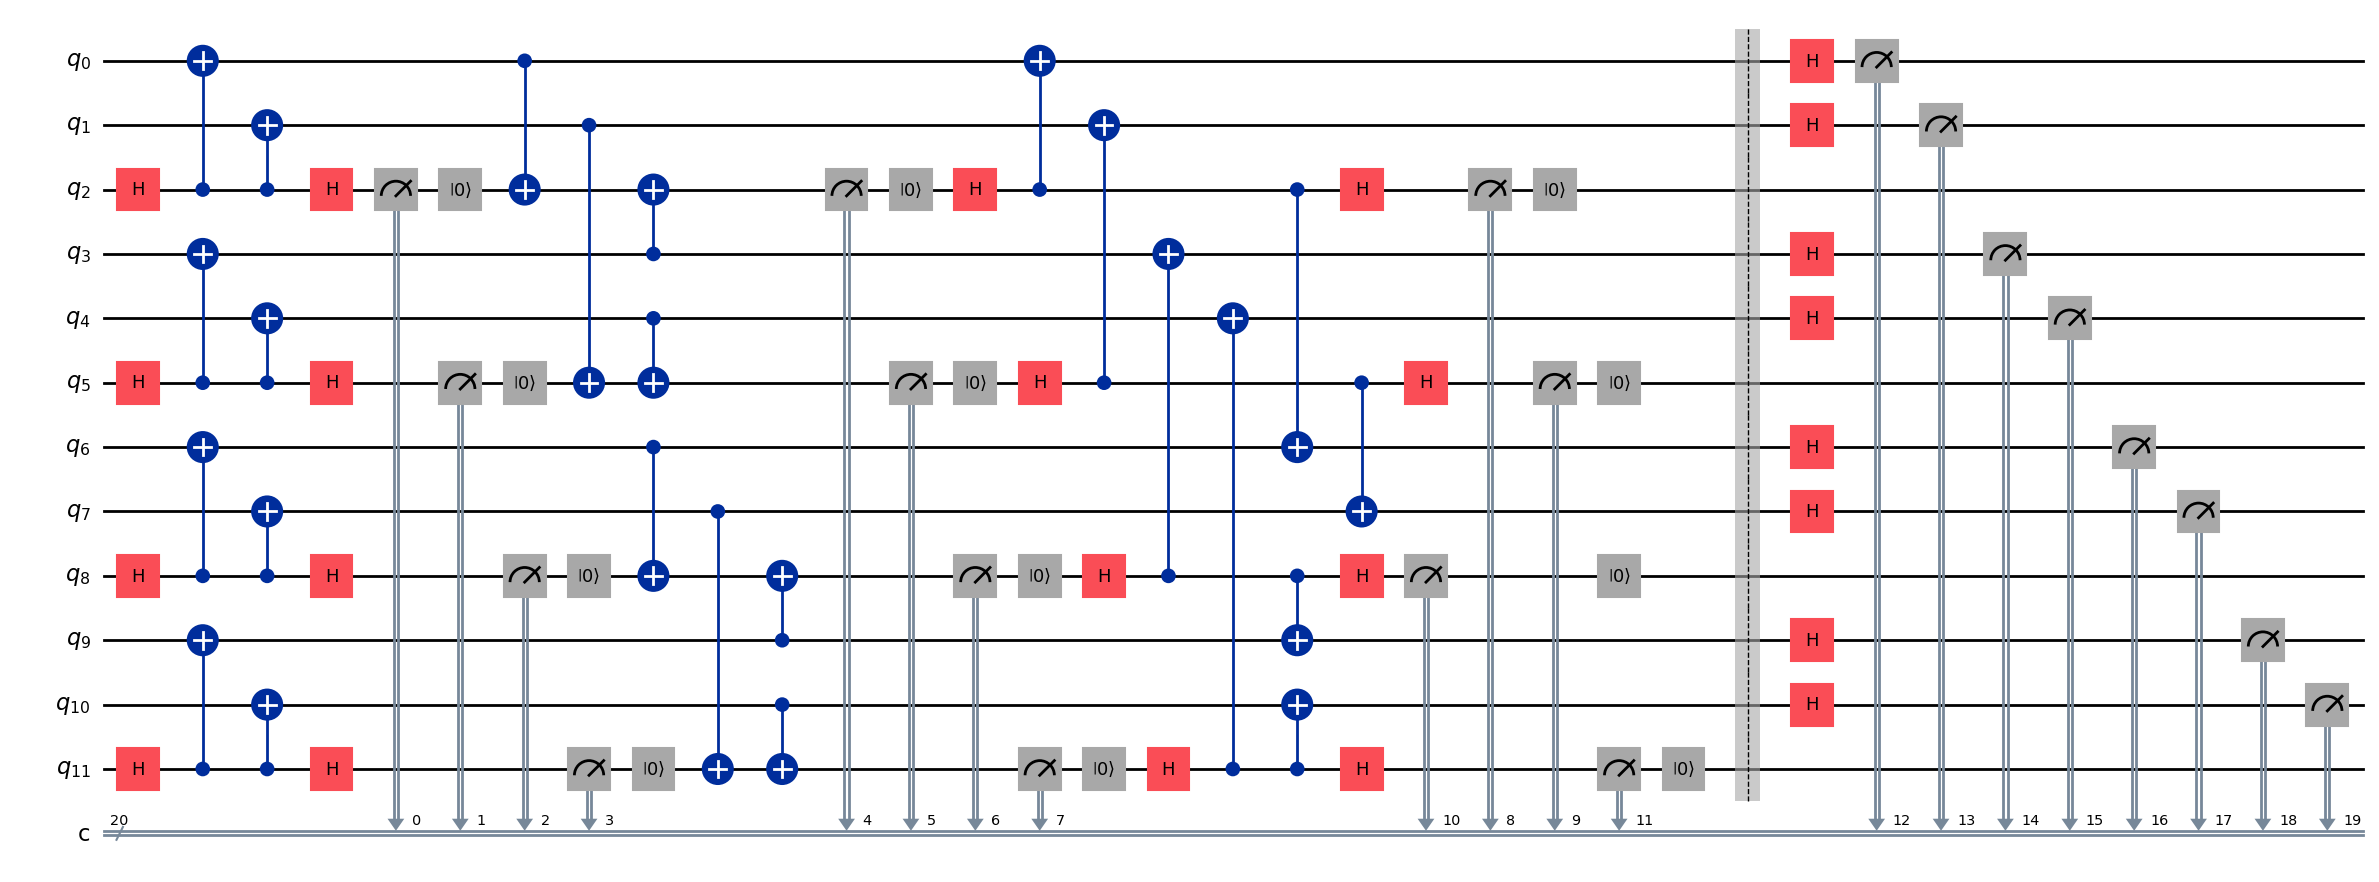

In [36]:
polar_n3_x_meas_data = polar_code_p2(3, True, "x", True)
polar_n3_x_meas_data.draw("mpl", fold=-1)

After applying the simplification, it will become:

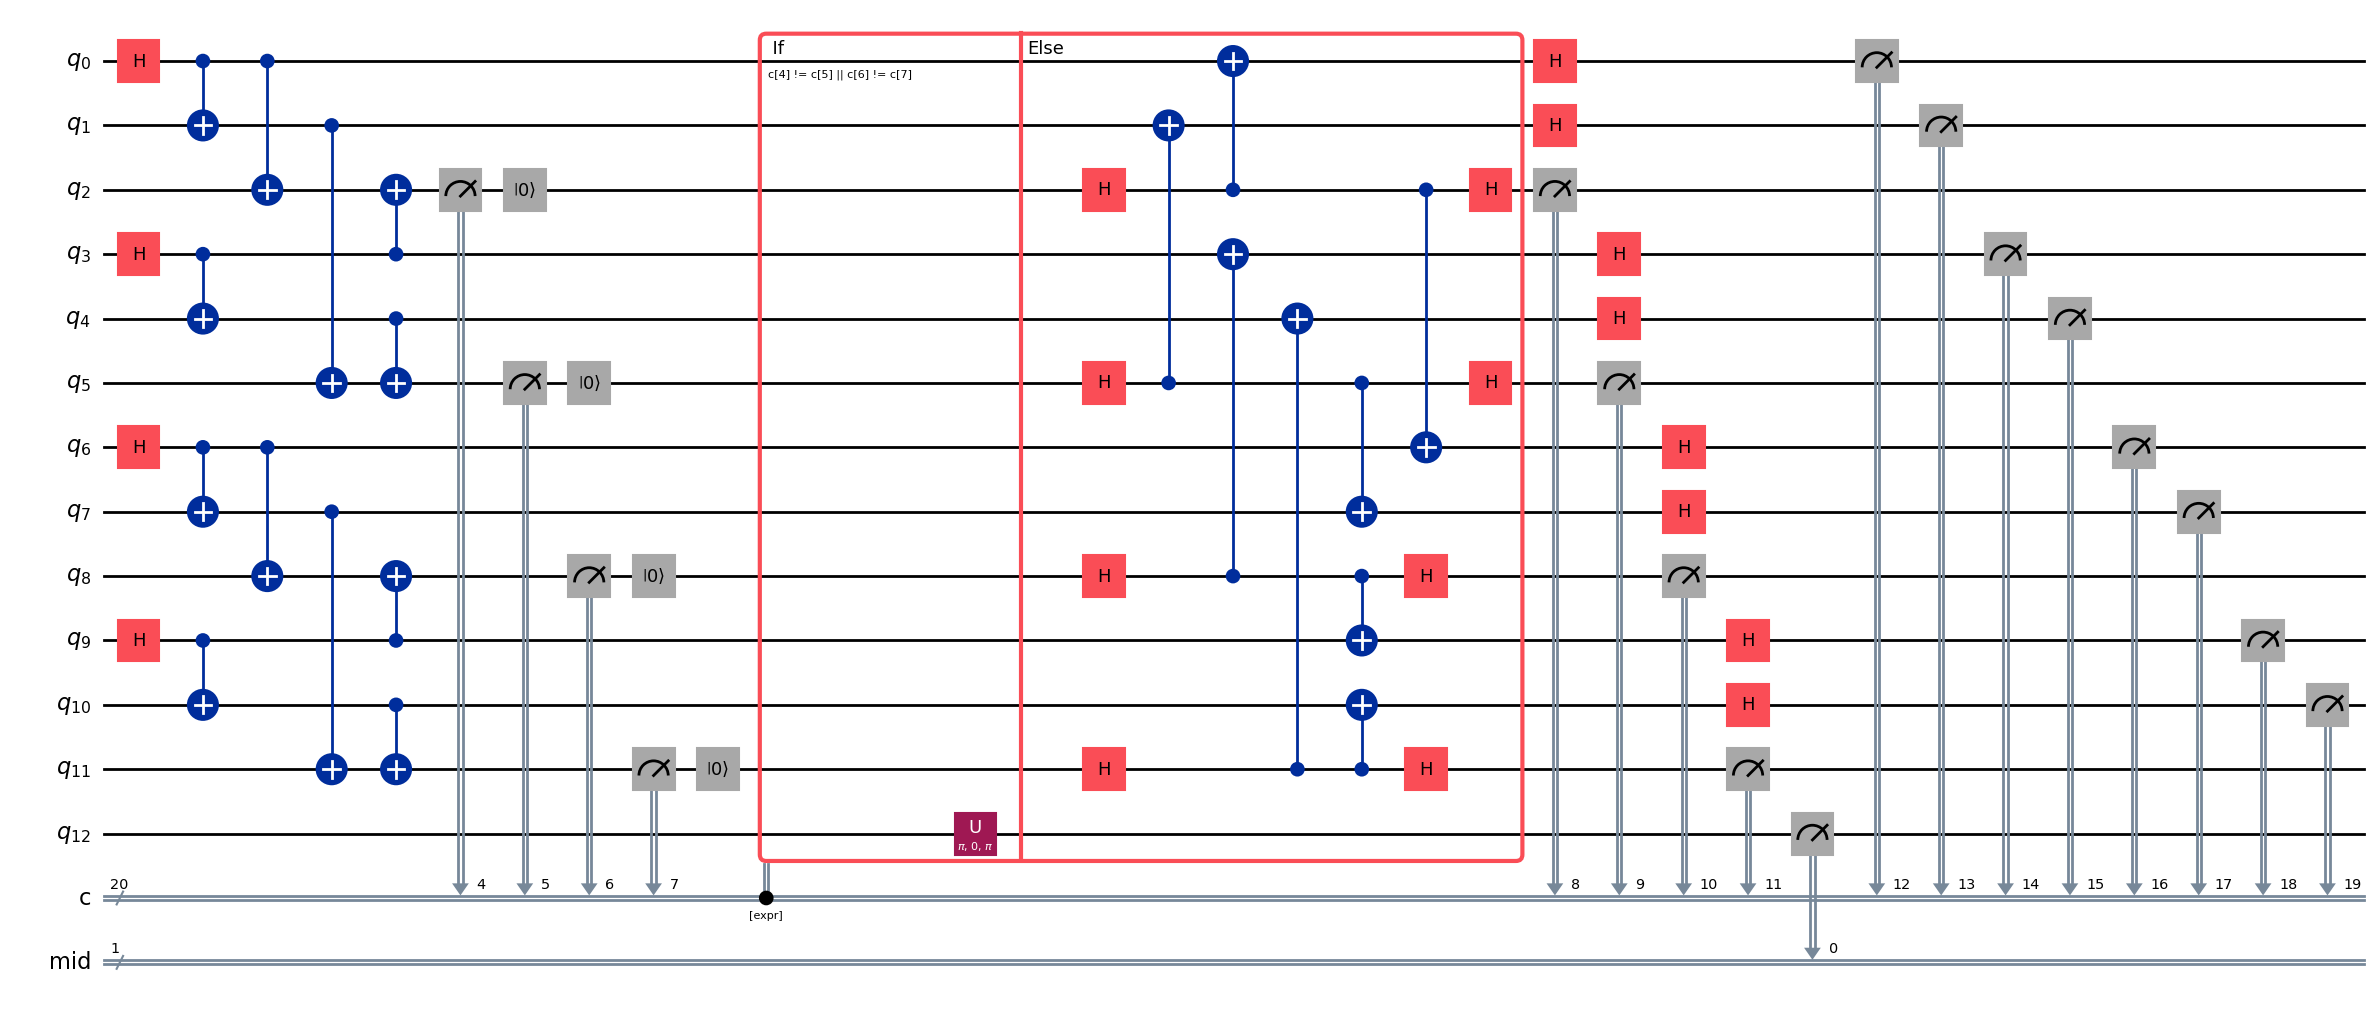

In [37]:
qreg = QuantumRegister(13, name="q")
creg = ClassicalRegister(20, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(4):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(2):
    start = i * 6 
    qc.append(qc_z2, range(start, start + 6), range(2))


m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    qc.reset(i)
    m_idx = m_idx + 1

# qc.barrier()

expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
with qc.if_test(expr_1) as else_:
    qc.x(12)
with else_:
    # qc.append(qc_z3, range(12), [8,9,10,11])
    qc.append(qc_x3, range(12), [8,9,10,11])

qc.measure(12, mid)

# m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    # qc.reset(i)
    m_idx = m_idx + 1

qc = qc.decompose()

# qc.barrier()

m_idx = 12
for i in range(12):
    if i in [2,5,8,11]:
        continue

    qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

qc_dynamic_n3_x = qc
qc_dynamic_n3_x.draw("mpl", fold=-1)

In [38]:
qc_dynamic_n3_x.draw("mpl", fold=-1).savefig("./output/proposal_1/qc_dynamic_n3_x.png", dpi=500, bbox_inches='tight')

#### Metric: Number of Operations

In [39]:
polar_n3_x_meas_data.count_ops()

OrderedDict([('h', 24),
             ('cx', 24),
             ('measure', 20),
             ('reset', 12),
             ('barrier', 1)])

In [40]:
qc_dynamic_n3_x.count_ops()

OrderedDict([('measure', 17),
             ('h', 12),
             ('cx', 12),
             ('reset', 4),
             ('if_else', 1)])

If an error is detected at the second layer, in total it will have less:
- 8 hadamard gates
- 8 CNOT gates
- 3 measure gates
- 4 reset gates

However, the current problem is the current technology of mid-circuit measurement and feed-forward operation is costly and takes a lot of time. 

Hopefully soon IBM will upgrade their Quantum Processor with the new Dynamic Circuit (https://docs.quantum.ibm.com/announcements/service-alerts/2025-05-25-dynamic-circuits-upgrade) which will be 75x faster and less noisy.

#### Metric: Quantum Resource (Simulation)

In [41]:
def run_simulation_n3(qc, shots, sim, seed_simulator):
    tqc = pm.run(qc)
    tmp_start_time  = time.perf_counter()
    result = sim.run(tqc, shots = shots, seed_simulator=seed_simulator).result()
    tmp_end_time = time.perf_counter()
    sim_time = tmp_end_time - tmp_start_time
    print("Simulation time: {} seconds".format(sim_time))

    count = result.get_counts()
    
    return count, sim_time
    
def get_layers_n3(count):

    layers = []
    layer_1 = {}
    layer_2 = {}
    layer_3 = {}
    layer_mid = {}
    for key, value in count.items():
        key = key.lstrip()

        l1 = key[-4:]
        l2 = key[-8:-4]
        l3 = key[-12:-8]
        lm = key[0]

        if l1 not in layer_1:
            layer_1[l1] = value
        else:
            layer_1[l1] = layer_1[l1] + value

        if l2 not in layer_2:
            layer_2[l2] = value
        else:
            layer_2[l2] = layer_2[l2] + value

        if l3 not in layer_3:
            layer_3[l3] = value
        else:
            layer_3[l3] = layer_3[l3] + value

        if lm not in layer_mid:
            layer_mid[lm] = value
        else:
            layer_mid[lm] = layer_mid[lm] + value

    layers.append(layer_1)
    layers.append(layer_2)
    layers.append(layer_3)
    layers.append(layer_mid)

    return layers

In [42]:
seed_simulator = randint(1, 9999999)
shots = 50
seed_simulator

2707284

In [43]:
# res_normal_ideal = run_simulation_n3(polar_n3_x_meas_data, shots, sim_ideal, seed_simulator)
# res_h1_ideal = run_simulation_n3(qc_dynamic_n3_x, shots, sim_ideal, seed_simulator)

In [44]:
# res_normal_noisy = run_simulation_n3(polar_n3_x_meas_data, shots, sim_noisy, seed_simulator)
# res_h1_noisy = run_simulation_n3(qc_dynamic_n3_x, shots, sim_noisy, seed_simulator)

##### Run to real backend

In [45]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n3_x_meas_data)
# tqc_2 = pm.run(qc_dynamic_n3_x)

# pubs_1 = [tqc_1]
# pubs_2 = [tqc_2]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
#              )
# sampler = Sampler(mode=backend, options=options) 
# sampler.options.experimental = {"execution_path" : "gen3-experimental"}
# job = sampler.run(pubs_1)
# print(job.job_id(), hw_name)

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [46]:
# d20a12tofqqs73dbgu50 ibm_brisbane -> normal (3s) -- saved
# d20a134lir9s73aho8fg ibm_brisbane -> dynamic (3s) -- saved

# d1anhb55z6q0008pg7p0 ibm_sherbrooke -> normal (14s), 606, 0.5016 -- saved
# d1anhcxn2txg008e5xsg ibm_sherbrooke -> with dynamic circuit (10s), 1661, 0.4936 -- saved
 
# d1ansk6n2txg008e60r0 ibm_sherbrooke -> normal (14s) -- saved
# d1anxgyn2txg008e6310 ibm_sherbrooke -> with dynamic circuit (10s) -- saved

# d1cnsadmya70008njs00 ibm_sherbrooke -> normal (14s) # chores.acetone-0t@icloud.com -- saved
# d1cnsaxqf56g00803kn0 ibm_sherbrooke -> with dynamic circuit (10) # chores.acetone-0t@icloud.com -- saved

In [47]:
# job_ids = ["d20a134lir9s73aho8fg"]

# # save_results_to_file("bris_n3_x_normal", job_ids, service)
# save_results_to_file("bris_n3_x_dynamic", job_ids, service)

In [48]:
print("Normal :")
for res in load_results_from_file("bris_n3_x_normal"):
    print(res.metadata["execution"]["execution_spans"].duration)

print("Dynamic :")
for res in load_results_from_file("bris_n3_x_dynamic"):
    print(res.metadata["execution"]["execution_spans"].duration)

Normal :
2.092086
Dynamic :
2.141472


In [49]:
# job_normal = service.job("d1cnsadmya70008njs00")
# result = job_normal.result()

result = load_results_from_file("bris_n3_x_normal")[0]
res_1 = result[0].data.c.get_counts()
shots = sum(res_1.values())

n = 3
lstate = "X"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)


In [50]:
def update_count_dict_n3_t2_discard(count_ideal):
    creg_counts = {}
    total_discard = 0
    for key, value in count_ideal.items():
        key = key.replace(" ", "")  # remove spaces, just in case
        creg_part = key[-20:]
        mid_part = key[0]
        
        if "1" in mid_part:
            total_discard = total_discard + value
            continue

        creg_counts[creg_part] = creg_counts.get(creg_part, 0) + value

    # print("Total discarded :", total_discard)
    return creg_counts, total_discard


In [51]:
def update_count_dict_discard(mid_idx, creg_idx, count_ideal):
    creg_counts = {}
    total_discard = 0
    
    for key, value in count_ideal.items():
        key = key.replace(" ", "")  # remove spaces, just in case
        creg_part = key[creg_idx:]
        mid_part = key[mid_idx:creg_idx]
        
        if "1" in mid_part:
            total_discard = total_discard + value
            continue

        creg_counts[creg_part] = creg_counts.get(creg_part, 0) + value

    return creg_counts, total_discard


In [52]:
# job_h1 = service.job("d1cnsaxqf56g00803kn0")
# result_h1 = job_h1.result()

result_h1 = load_results_from_file("bris_n3_x_dynamic")[0]
res_1 = result_h1[0].join_data().get_counts()

tmp_start_time  = time.perf_counter()
creg_counts, total_discard = update_count_dict_n3_t2_discard(res_1)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time
count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)


In [53]:
print("time old : ", detect_normal + decoding_normal)
print("time new : ", detect_h1 + decoding_h1 + dec_filter_time, total_discard)

time old :  0.2817854300083127
time new :  0.1278155180043541 2986


In [54]:
print(shots)

5000


In [55]:
print("old :", count_accept / shots, ler)
print("M1 :", count_accept_h1 / (shots - total_discard), ler_h1)

print("Count accept : ", count_accept, count_accept_h1)
print("Count logerror : ", count_logerror, count_logerror_h1)
print("Count undecided : ", count_undecided, count_undecided_h1)

print("Time detect : ", detect_normal, detect_h1)
print("Time decoding : ", decoding_normal, decoding_h1)

old : 0.1184 0.5
M1 : 0.4637537239324727 0.49678800856531047
Count accept :  592 934
Count logerror :  296 470
Count undecided :  516 824
Time detect :  0.23202810500515625 0.10725201299646869
Time decoding :  0.04975732500315644 0.019989768014056608


In [56]:
# old : 0.1212 0.5016501650165016
# M1 : 0.3328 0.49399038461538464
# Count accept :  606 1664
# Count logerror :  302 842
# Count undecided :  531 1531
# Time detect :  0.22877241400055937 0.20858470099847182
# Time decoding :  -0.005671039001754252 0.024920874002418714

In [57]:
# Time needed

result_h1[0].data.mid.get_counts()

{'1': 2986, '0': 2014}

### $n=4$, $i=7$ for logical $|0\rangle$, b = 0110

Here we have a circuit for Q1 State Preparation Quantum Polar Code with $n=3$, $i=4$ for logical $|0\rangle$, b = 0110

n = 4 , b = 0110 (6) , i = 7


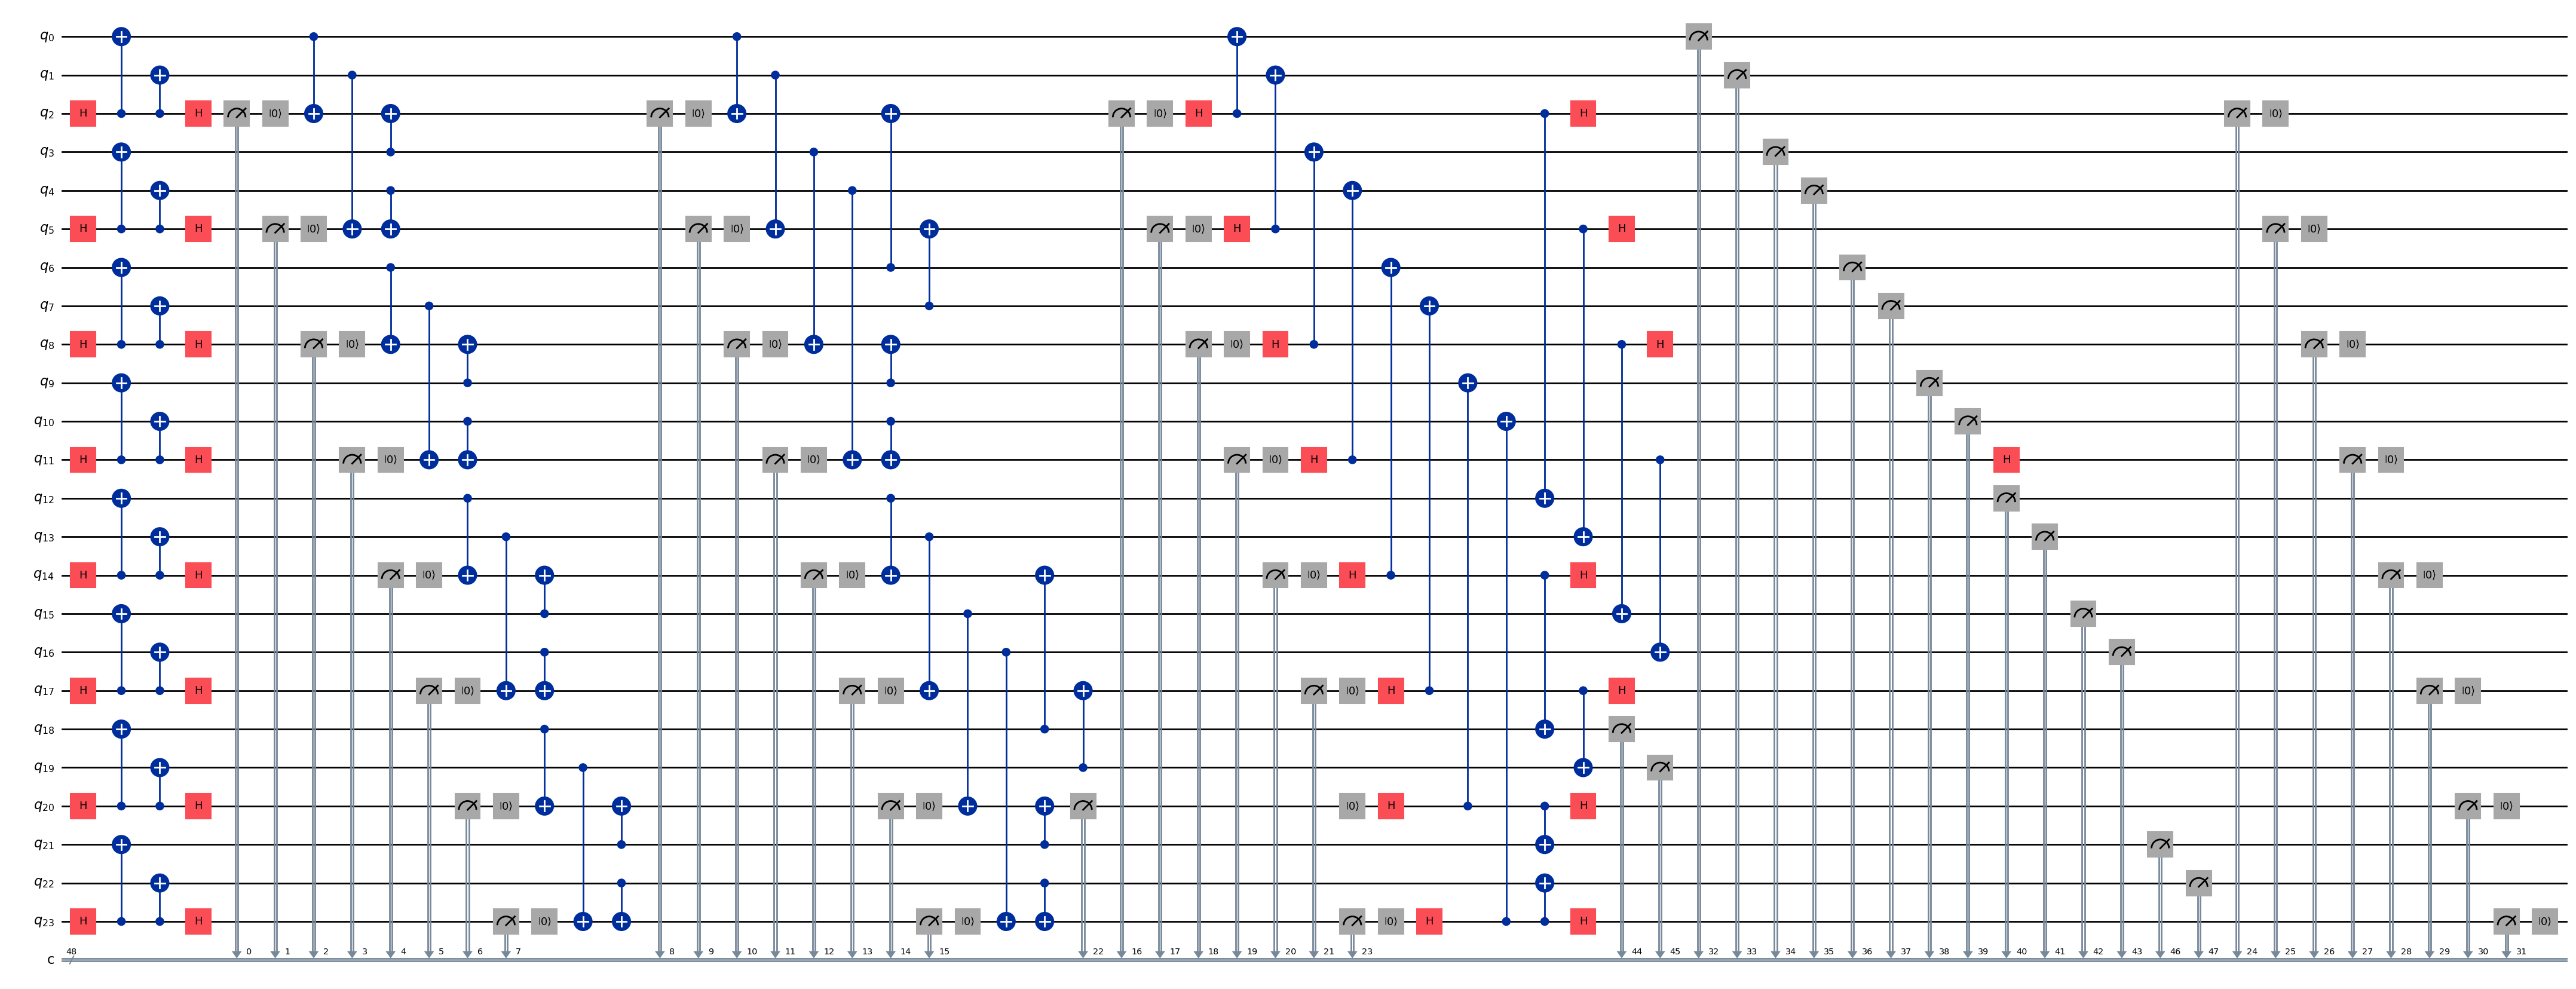

In [58]:
polar_n4_z_meas_data = polar_code_p2(4, True, "z", False)
polar_n4_z_meas_data.draw("mpl", fold=-1)

Applying the simplification it will become:

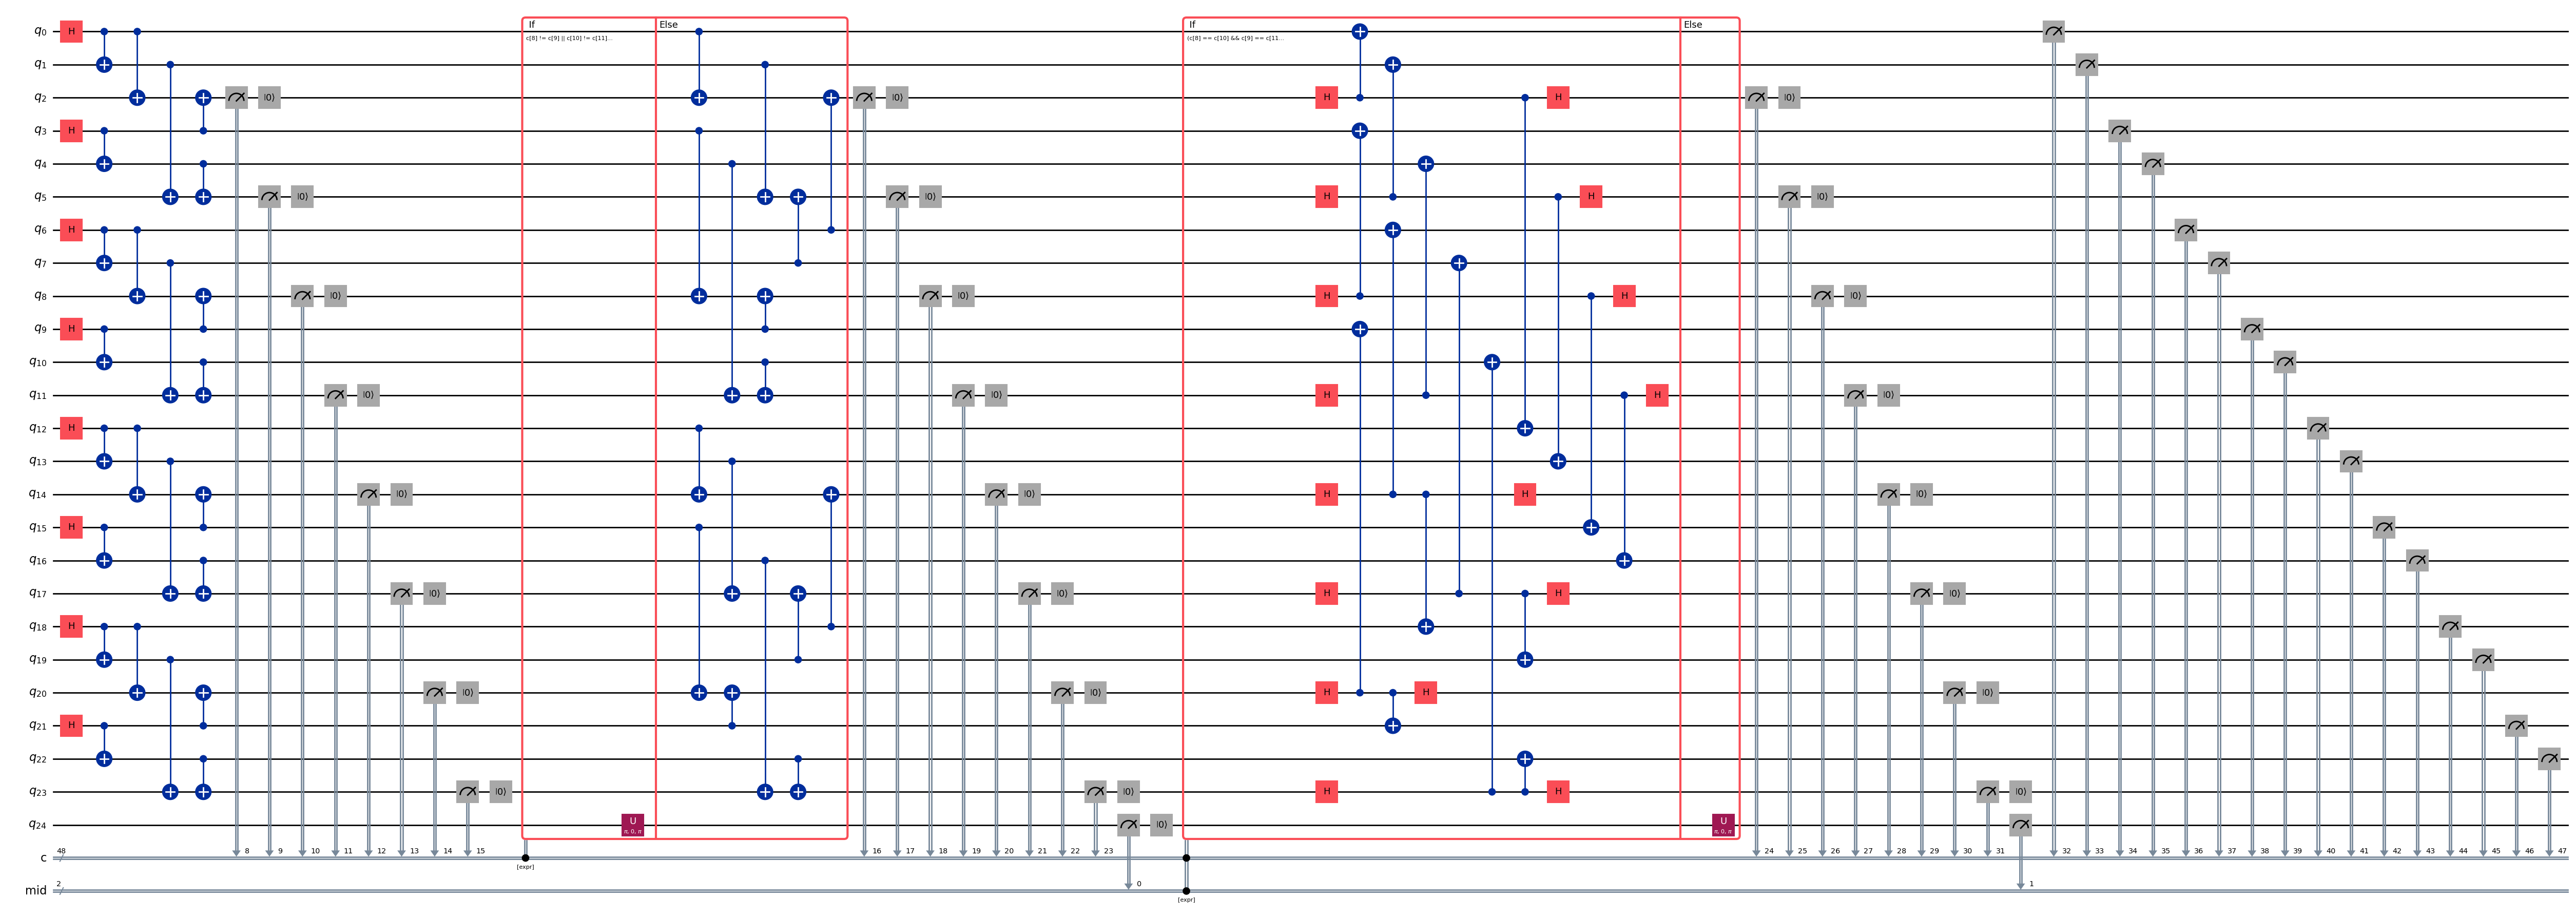

In [59]:
qreg = QuantumRegister(25, name="q")
creg = ClassicalRegister(48, name="c")
mid = ClassicalRegister(2, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(8):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(4):
    start = i * 6
    qubits = range(start, start + 6)       
    clbits = range(2 * i + 4, 2 * i + 6)  
    qc.append(qc_z2, qubits, clbits)

m_idx = 8
for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

# expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
expr_1 = expr.logic_or(
expr.logic_or( expr.not_equal(creg[8], creg[9]), expr.not_equal(creg[10], creg[11]) ),
expr.logic_or( expr.not_equal(creg[12], creg[13]), expr.not_equal(creg[14], creg[15]) )
)
with qc.if_test(expr_1) as else_:
    qc.x(24)

with else_:

    for i in range(2):    
        start = i * 12
        qubits = range(start, start + 12)
        clbits = range(4)
        qc.append(qc_z3, qubits, clbits)

qc.measure(24, mid[0])
qc.reset(24)

for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

expr_2 = expr.logic_and( 
            expr.logic_or( 
            expr.logic_and(
                
            expr.logic_and(expr.equal(creg[8], creg[10]) , expr.equal(creg[9], creg[11])) ,
            expr.logic_and(expr.equal(creg[12], creg[14]) , expr.equal(creg[13], creg[15])) 
            ),
            expr.logic_and(
            expr.logic_and(expr.equal(creg[8], creg[10]) , expr.equal(creg[9], creg[11])) ,
            expr.logic_and(expr.equal(creg[12], creg[14]) , expr.equal(creg[13], creg[15])) 
            )
           ),
        expr.equal(mid, 0b00)
        )
    
with qc.if_test(expr_2) as else_:
    qc.append(qc_x4, range(24), range(8))

with else_:
    qc.x(24)

qc.measure(24, mid[1])

for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

qc = qc.decompose()

for i in (j for j in range(24) if j % 3 != 2):
    qc.measure(i, m_idx)
    m_idx += 1

qc_dynamic_n4_z = qc
qc_dynamic_n4_z.draw("mpl", fold=-1)

#### Run Noiseless Simulation

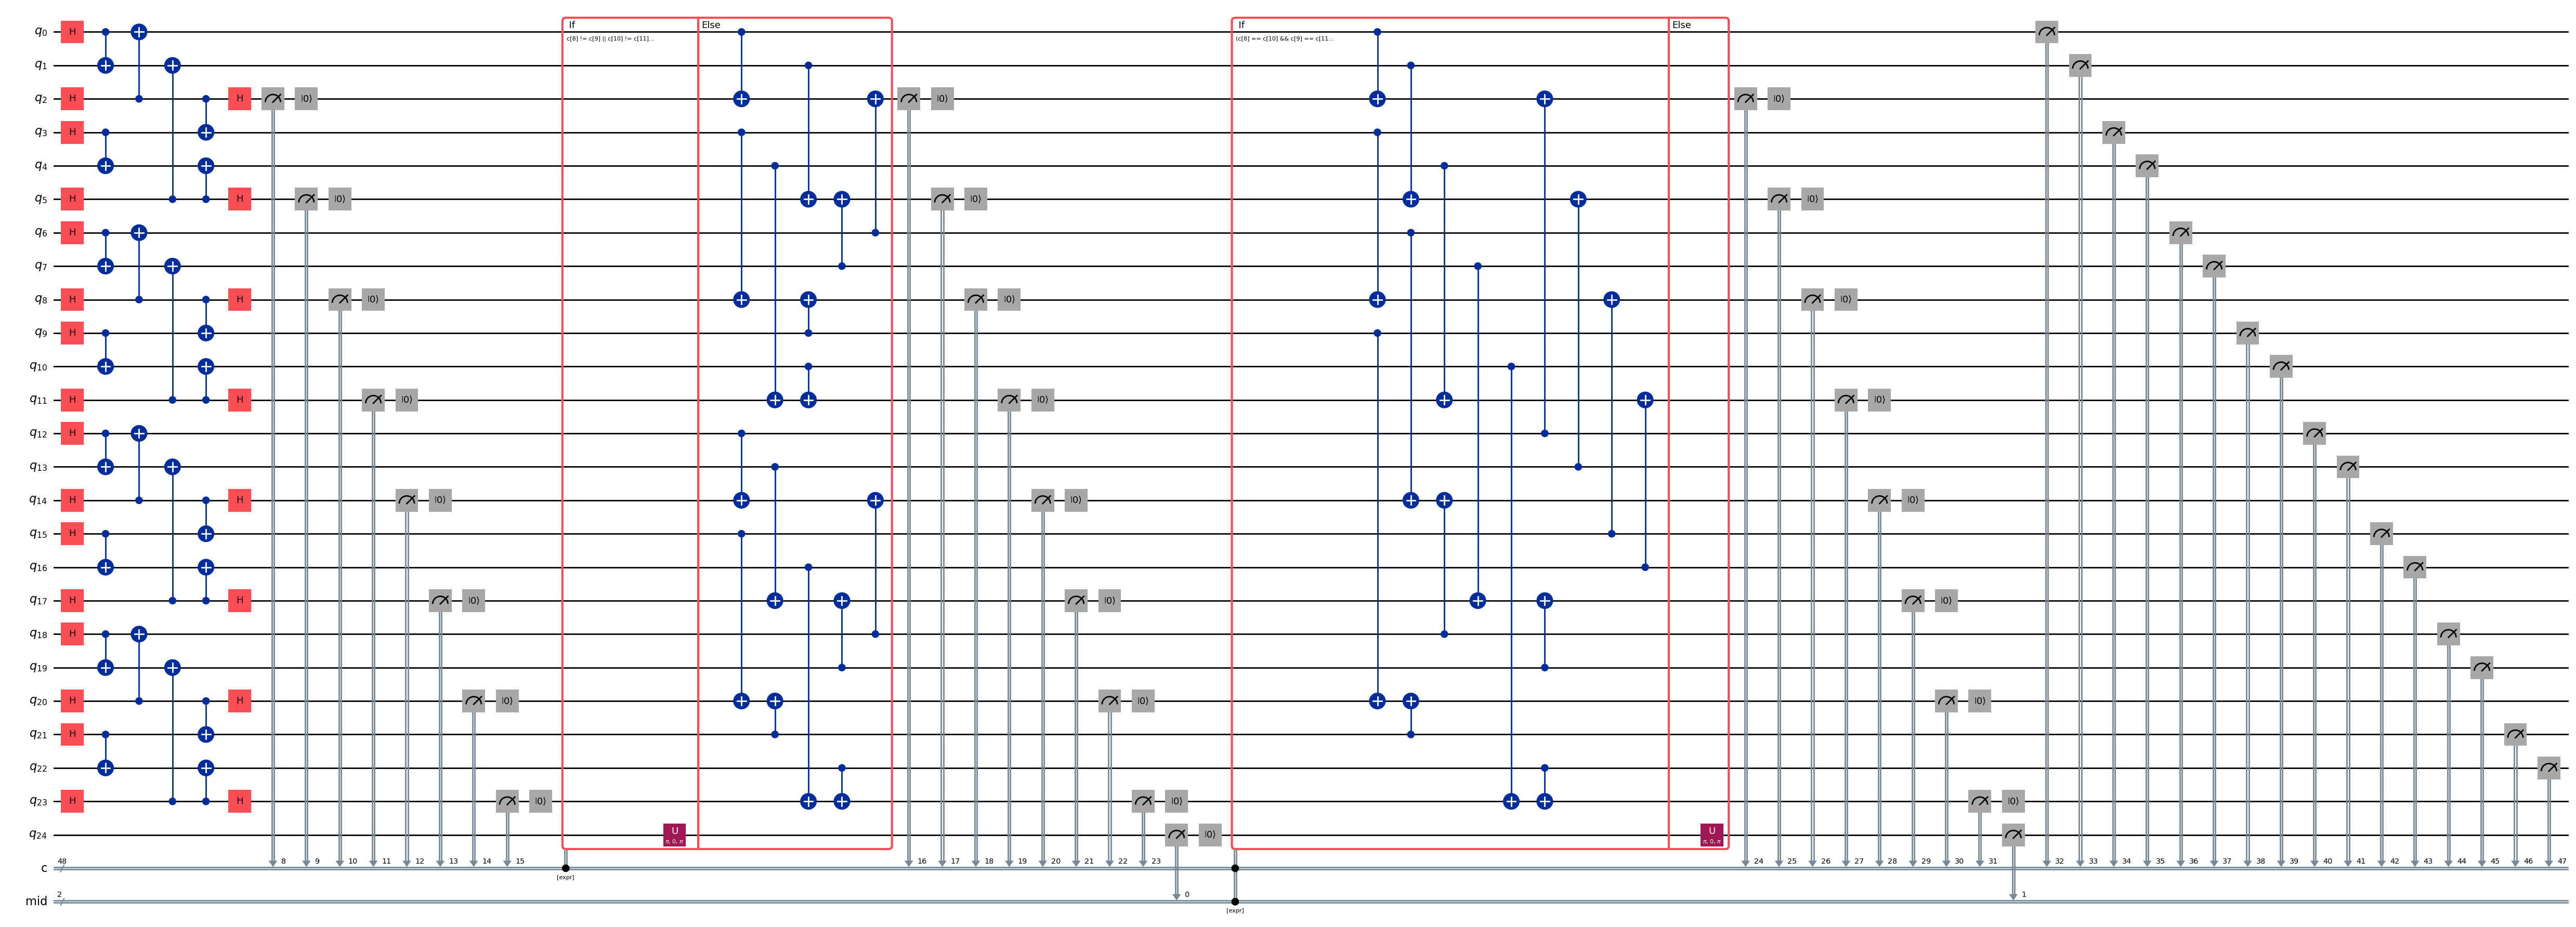

In [60]:
qreg = QuantumRegister(25, name="q")
creg = ClassicalRegister(48, name="c")
mid = ClassicalRegister(2, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(8):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(4):
    start = i * 6
    qubits = range(start, start + 6)       
    clbits = range(2 * i + 4, 2 * i + 6)  
    qc.append(qc_x2, qubits, clbits)

m_idx = 8
for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

# expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
expr_1 = expr.logic_or(
expr.logic_or( expr.not_equal(creg[8], creg[9]), expr.not_equal(creg[10], creg[11]) ),
expr.logic_or( expr.not_equal(creg[12], creg[13]), expr.not_equal(creg[14], creg[15]) )
)
with qc.if_test(expr_1) as else_:
    qc.x(24)

with else_:

    for i in range(2):    
        start = i * 12
        qubits = range(start, start + 12)
        clbits = range(4)
        qc.append(qc_z3, qubits, clbits)

qc.measure(24, mid[0])
qc.reset(24)

for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

expr_2 = expr.logic_and( 
            expr.logic_or( 
            expr.logic_and(
                
            expr.logic_and(expr.equal(creg[8], creg[10]) , expr.equal(creg[9], creg[11])) ,
            expr.logic_and(expr.equal(creg[12], creg[14]) , expr.equal(creg[13], creg[15])) 
            ),
            expr.logic_and(
            expr.logic_and(expr.equal(creg[8], creg[10]) , expr.equal(creg[9], creg[11])) ,
            expr.logic_and(expr.equal(creg[12], creg[14]) , expr.equal(creg[13], creg[15])) 
            )
           ),
        expr.equal(mid, 0b00)
        )
    
with qc.if_test(expr_2) as else_:
    qc.append(qc_z4, range(24), range(8))

with else_:
    qc.x(24)

qc.measure(24, mid[1])

for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

qc = qc.decompose()

for i in (j for j in range(24) if j % 3 != 2):
    qc.measure(i, m_idx)
    m_idx += 1

qc_dynamic_n4_z_13 = qc
qc_dynamic_n4_z_13.draw("mpl", fold=-1)

In [61]:
# aaaa

In [62]:
# # tqc = pm.run(polar_n4_z_meas_data)

# polar_n4_z_meas_data = polar_code_p2(4, True, "z", False)
# polar_n5_z_meas_data = polar_code_p2(5, True, "z", False)

# # tqc = polar_n4_z_meas_data
# tqc = qc_dynamic_n4_z_13

# shots = 100
# result = sim_ideal.run(tqc, shots = shots).result()
# count = result.get_counts()

# n = 4
# lstate = "Z"
# count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, count)

# print(count_accept, ler)


In [63]:
# polar_n5_z_meas_data.draw("mpl", fold=40)

In [64]:
# aaaa

#### Metric: Number of Operations

In [65]:
polar_n4_z_meas_data.count_ops()

OrderedDict([('cx', 64), ('measure', 48), ('h', 32), ('reset', 32)])

In [66]:
qc_dynamic_n4_z.count_ops()

OrderedDict([('measure', 42),
             ('reset', 25),
             ('cx', 24),
             ('h', 8),
             ('if_else', 2)])

If an error is detected at the second layer, in total it will have less:
- 24 hadamard gates
- 40 CNOT gates
- 6 measure gates
- 8 reset gates

#### Metric: Quantum Resources

In [67]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n4_z_meas_data)
# tqc_2 = pm.run(qc_dynamic_n4_z)

# pubs_1 = [tqc_1]
# pubs_2 = [tqc_2]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
#              )
# sampler = Sampler(mode=backend, options=options) 
# sampler.options.experimental = {"execution_path" : "gen3-experimental"}
# job = sampler.run(pubs_1)
# print(job.job_id(), hw_name)

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [68]:
# d20a5jjni11c73fcfdag ibm_brisbane normal (3s) -- saved
# d20a8fjni11c73fcfg00 ibm_brisbane normal (3s) -- saved

# d20a5js3s4ss73ckubig ibm_brisbane dynamic (3s) -- saved
# d20a8ftofqqs73dbh51g ibm_brisbane dynamic (3s) -- saved

# d1anyv35z6q0008pgd70 ibm_sherbrooke normal (32s) -- saved
# d1anywkv3z50008ab6vg ibm_sherbrooke dynamic (11s) -- saved

# d1ap65rv3z50008ab9pg ibm_sherbrooke normal (32s) -- saved
# d1ap670mya70008nb9rg ibm_sherbrooke dynamic (14s) -- saved

# d1apt3rqf56g008zwbd0 ibm_sherbrooke normal (31s) -- saved
# d1apt58mya70008nbeng ibm_sherbrooke normal (13s) -- saved

# d1b7k2c5z6q0008pkk40 ibm_sherbrooke normal (36s) -- saved

#------
# d1ar9vfmya70008nbpcg ibm_sherbrooke normal (33s) -- saved
# d1awj505z6q0008phhvg ibm_sherbrooke normal (33s) -- saved
# d1axhtqn2txg008e7k7g ibm_sherbrooke normal (33s) -- saved



In [69]:
# job_ids = ["d20a8fjni11c73fcfg00"]

# save_results_to_file("bris_n4_z_normal", job_ids, service)
# # save_results_to_file("bris_n4_z_dynamic", job_ids, service)

In [70]:
print("Normal :")
for res in load_results_from_file("bris_n4_z_normal"):
    print(res.metadata["execution"]["execution_spans"].duration)

print("Dynamic :")
for res in load_results_from_file("bris_n4_z_dynamic"):
    print(res.metadata["execution"]["execution_spans"].duration)

Normal :
2.5416
2.554653
Dynamic :
2.827685
2.990216


In [71]:
def update_count_dict_n4_t2_discard(count_ideal):
    creg_counts = {}
    total_discard = 0
    for key, value in count_ideal.items():
        key = key.replace(" ", "")  # remove spaces, just in case
        creg_part = key[-48:]
        mid_part = key[:1]
        
        if "1" in mid_part:
            total_discard = total_discard + value
            continue

        creg_counts[creg_part] = creg_counts.get(creg_part, 0) + value

    print("Total discarded :", total_discard)
    return creg_counts, total_discard


In [72]:
# job_normal = service.job("d1apt3rqf56g008zwbd0")
# result = job_normal.result()

result = load_results_from_file("bris_n4_z_normal")[1]
res_1 = result[0].data.c.get_counts()

n = 4
lstate = "Z"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)

# job_h1 = service.job("d1apt58mya70008nbeng")
# result_h1 = job_h1.result()

result_h1 = load_results_from_file("bris_n4_z_dynamic")[1]
res_1 = result_h1[0].join_data().get_counts()

tmp_start_time  = time.perf_counter()
creg_counts, total_discard = update_count_dict_n4_t2_discard(res_1)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time

count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)


Total discarded : 3931


In [73]:
print("time old : ", detect_normal + decoding_normal)
print("time new : ", detect_h1 + decoding_h1 + dec_filter_time)

time old :  0.35988086499855854
time new :  0.0827989810204599


In [74]:
result_h1[0].data.mid.get_counts()



{'11': 3202, '10': 729, '00': 628, '01': 441}

In [75]:
print("old :", count_accept / shots, ler)
print("M1 :", count_accept_h1 / (shots - total_discard ), ler_h1)

print("Count accept : ", count_accept, count_accept_h1)
print("Count logerror : ", count_logerror, count_logerror_h1)
print("Count undecided : ", count_undecided, count_undecided_h1)

print("Time detect : ", detect_normal, detect_h1)
print("Time decoding : ", decoding_normal, decoding_h1)

old : 0.0006 0.3333333333333333
M1 : 0.0 0
Count accept :  3 0
Count logerror :  2 0
Count undecided :  3 0
Time detect :  0.3973515029938426 0.0866479980177246
Time decoding :  -0.03747063799528405 -0.004827936005312949


### $n=4$, $i=6$ for logical $|+\rangle$, b = 1010

n = 4 , b = 1010 (5) , i = 6


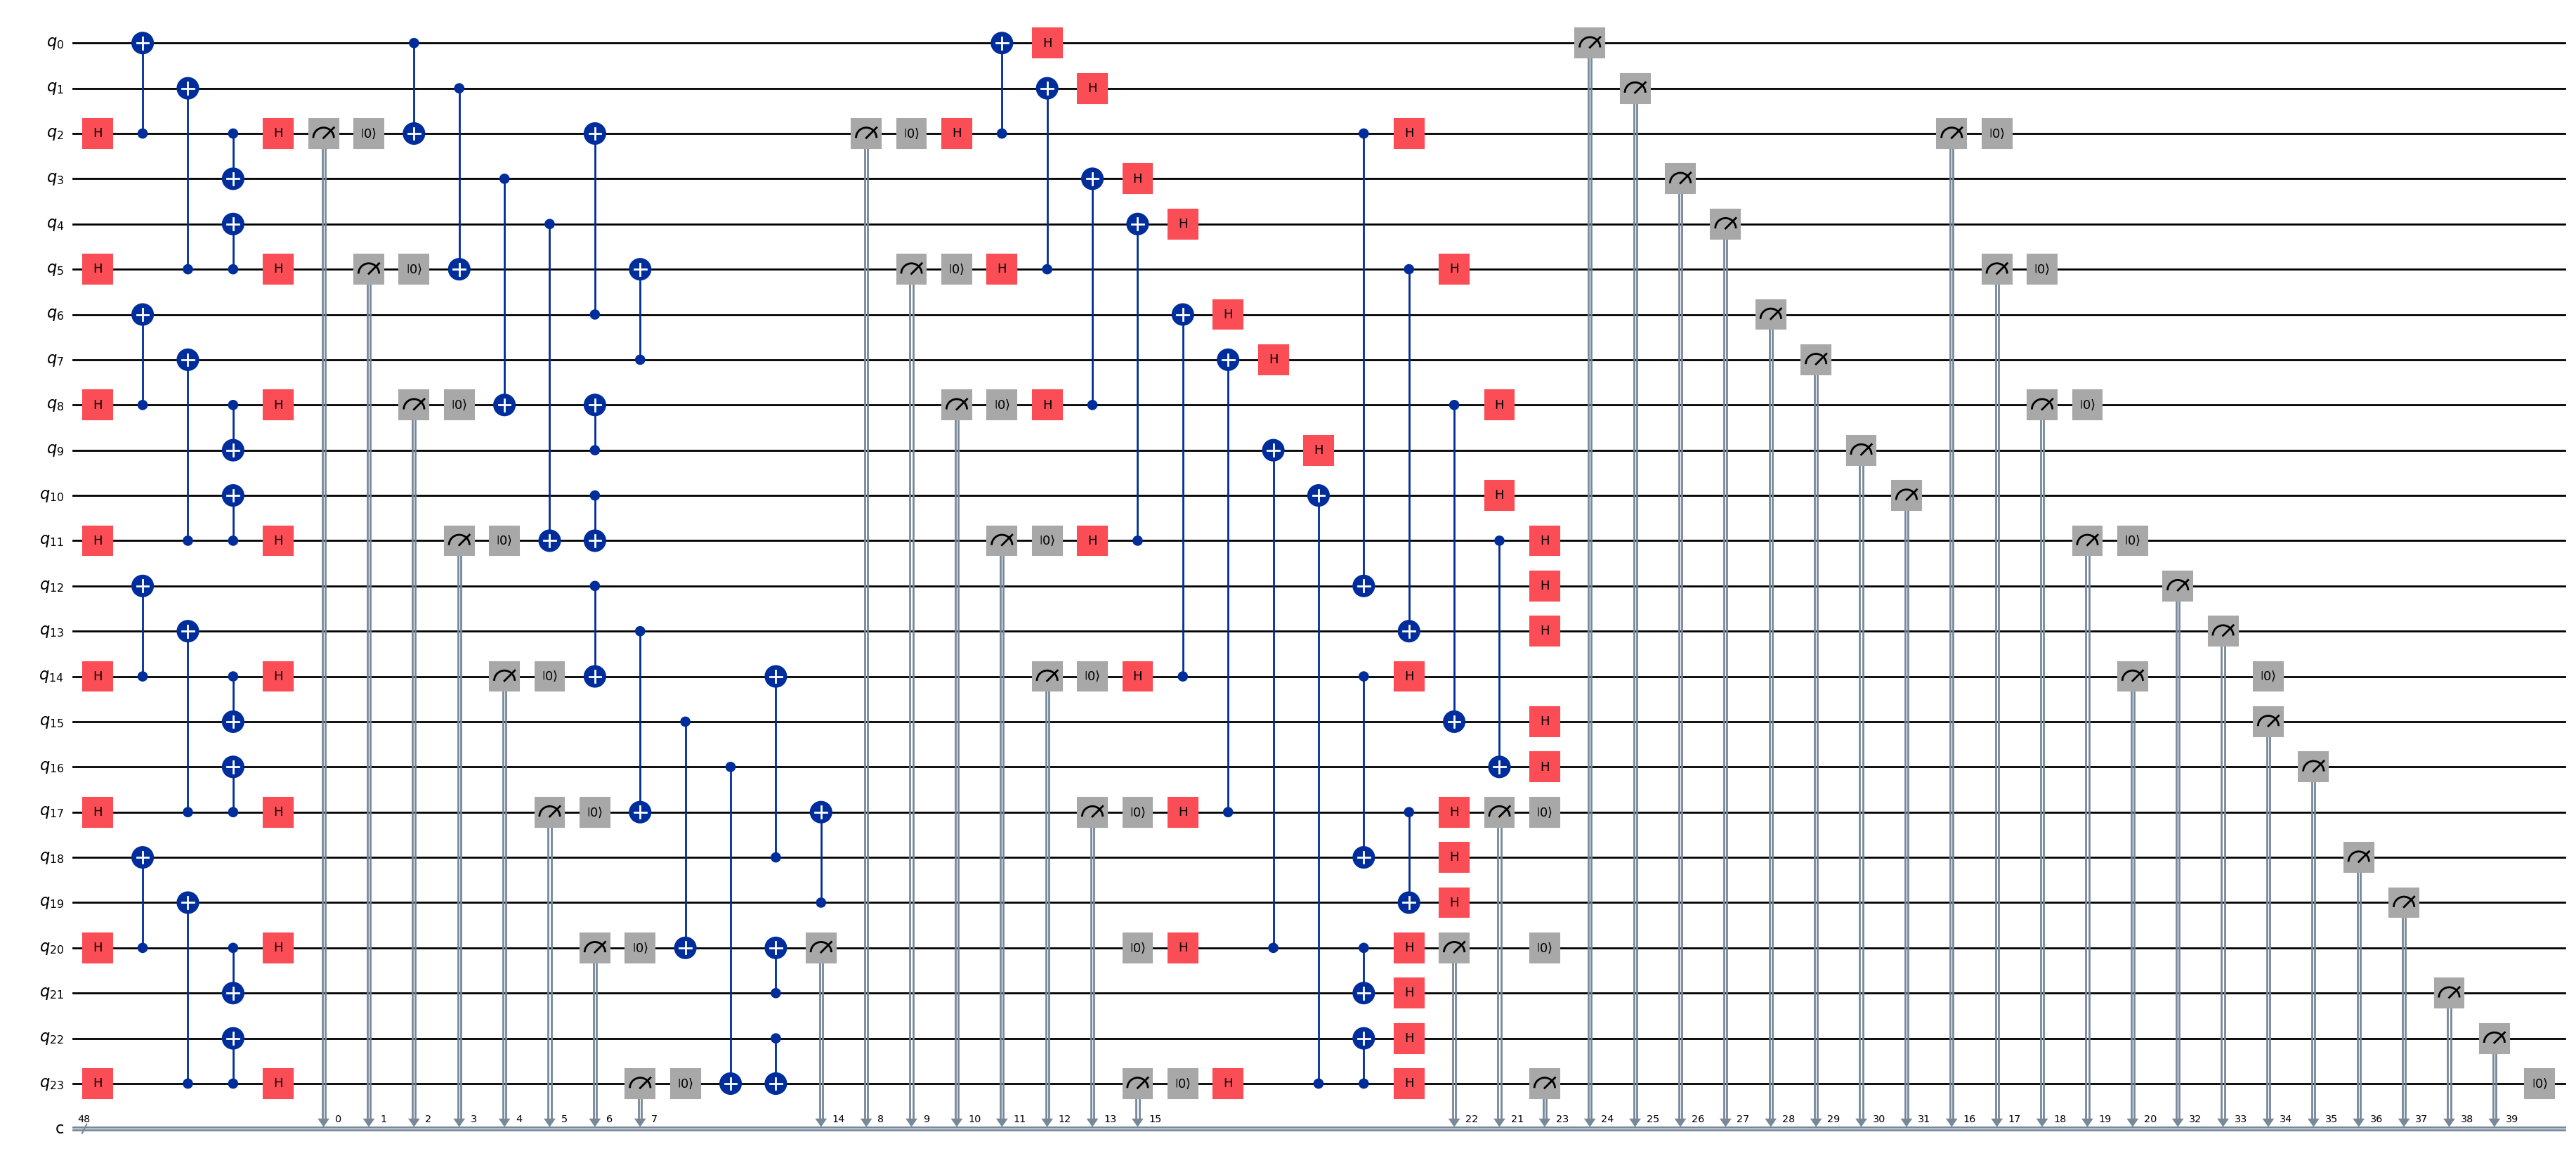

In [76]:
polar_n4_x_meas_data = polar_code_p2(4, True, "x", False)
polar_n4_x_meas_data.draw("mpl", fold=-1)

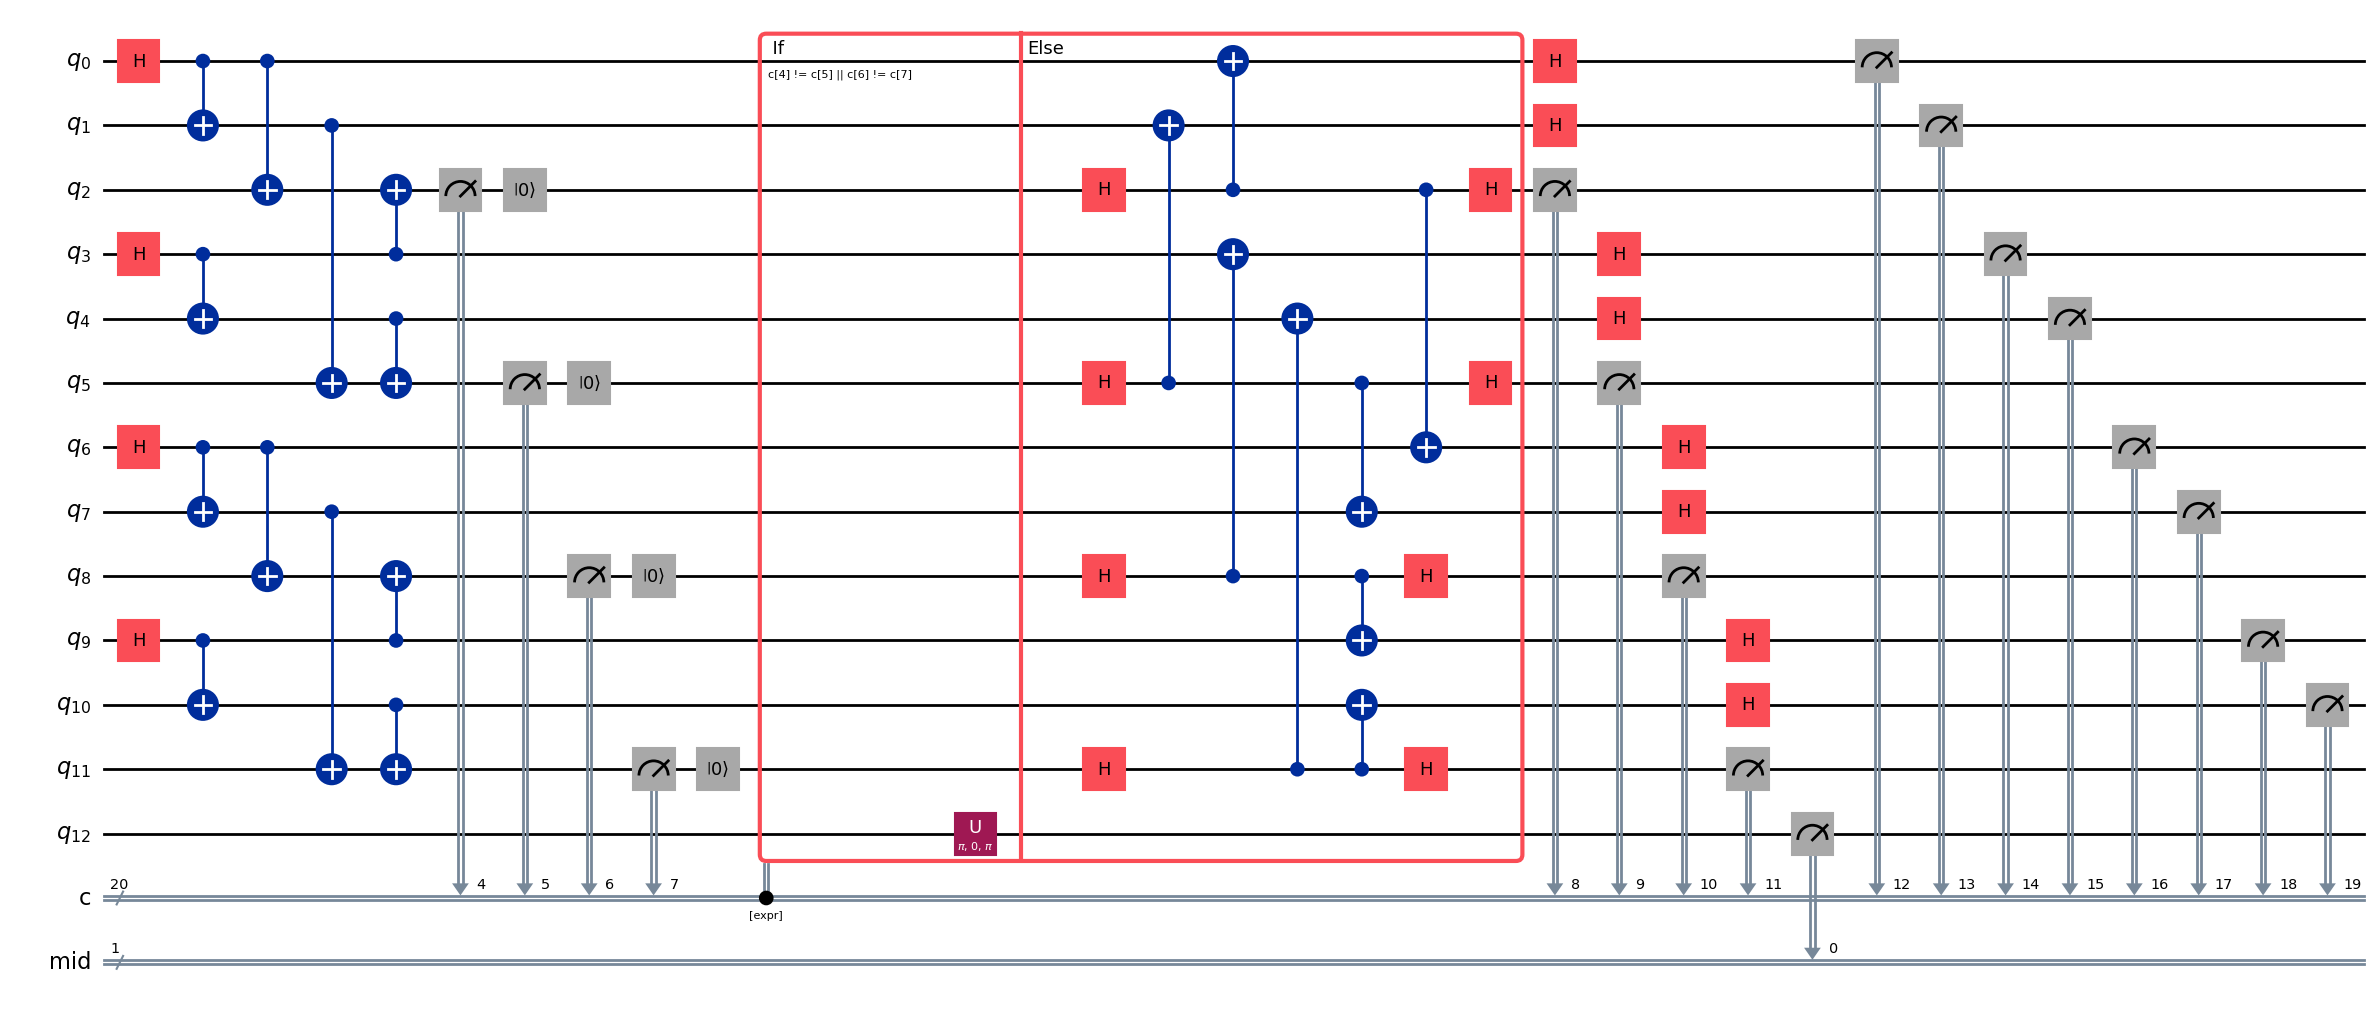

In [77]:
# n3 x 

qreg = QuantumRegister(13, name="q")
creg = ClassicalRegister(20, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(4):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(2):
    start = i * 6 
    qc.append(qc_z2, range(start, start + 6), range(2))

m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    qc.reset(i)
    m_idx = m_idx + 1

# qc.barrier()

expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
with qc.if_test(expr_1) as else_:
    qc.x(12)
with else_:
    # qc.append(qc_z3, range(12), [8,9,10,11])
    qc.append(qc_x3, range(12), [8,9,10,11])

qc.measure(12, mid)

# m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    # qc.reset(i)
    m_idx = m_idx + 1

qc = qc.decompose()

# qc.barrier()

m_idx = 12
for i in range(12):
    if i in [2,5,8,11]:
        continue

    qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

qc_dynamic_n4_x = qc
qc_dynamic_n4_x.draw("mpl", fold=-1)

In [78]:
# circ = polar_n3_x_meas_data
# circ_name = "n3_x"
# reps = 2
# compiled_circuits = multiprogram_compilation_qiskit([circ]*reps,backend)

# init_1 = compiled_circuits[0]["initial_layout"]
# init_2 = compiled_circuits[1]["initial_layout"]
# mc = merge_circuits(compiled_circuits, backend)

# used_qbts = []
# for i in init_1:
#     used_qbts.append(i)

# for i in init_2:
#     used_qbts.append(i)

# print(init_1)
# print(init_2)

# best_qubits = [72,122,108,91,70,123,26,124,40]
# # Combine init_1 and init_2 into used_qbts
# used_qbts = init_1 + init_2

# # Select up to 2 qubits from best_qubits that are not in used_qbts
# chosen_qubits = [q for q in best_qubits if q not in used_qbts][:2]

# # Add chosen qubits to used_qbts and distribute to init_1 and init_2
# used_qbts.extend(chosen_qubits)
# if len(chosen_qubits) == 2:
#     init_1.append(chosen_qubits[0])
#     init_2.append(chosen_qubits[1])

# # Optional: debugging prints
# print("Chosen:", chosen_qubits)
# print("Init 1:", init_1)
# print("Init 2:", init_2)

# pm_1 = generate_preset_pass_manager(
#     optimization_level=3, 
#     backend=backend,
#     initial_layout=init_1
# )

# pm_2 = generate_preset_pass_manager(
#     optimization_level=3, 
#     backend=backend,
#     initial_layout=init_2
# )

# tqc_h1_1 = pm_1.run(qc_h1)
# tqc_h1_2 = pm_2.run(qc_h1)

# tqc_h1_1.count_ops()


In [79]:
tqc_h1_1 = pm.run(qc_dynamic_n4_x)
print(tqc_h1_1.count_ops())
print(get_initial_layout_from_circuit(tqc_h1_1))

# used_qbts = used_qubits(tqc_h1_1)
used_qbts = get_initial_layout_from_circuit(tqc_h1_1)

cm = backend.coupling_map
cm = build_idle_coupling_map(cm, used_qbts)

pm_3 = generate_preset_pass_manager(
        optimization_level=3, backend=backend, coupling_map=cm
    )
tqc_h1_2 = pm_3.run(qc_dynamic_n4_x)

print(tqc_h1_2.count_ops())
print(used_qubits(tqc_h1_2))


OrderedDict({'rz': 119, 'sx': 64, 'ecr': 26, 'measure': 17, 'x': 5, 'reset': 4, 'if_else': 1})
[5, 4, 6, 8, 7, 3, 19, 20, 18, 33, 39, 38, 118]
OrderedDict({'rz': 126, 'sx': 67, 'ecr': 30, 'measure': 17, 'x': 7, 'reset': 4, 'if_else': 1})
[93, 106, 107, 108, 112, 119, 120, 121, 122, 123, 124, 126]


/tmp/ipykernel_84425/3302781113.py:11: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm_3 = generate_preset_pass_manager(


In [80]:
# op_types = []
# for g in tqc_h1_1:
#     op_types.append(g.name)

#     if g.name == "if_else":
#         break

# list(set(op_types))
# g

#### Merging the circuit

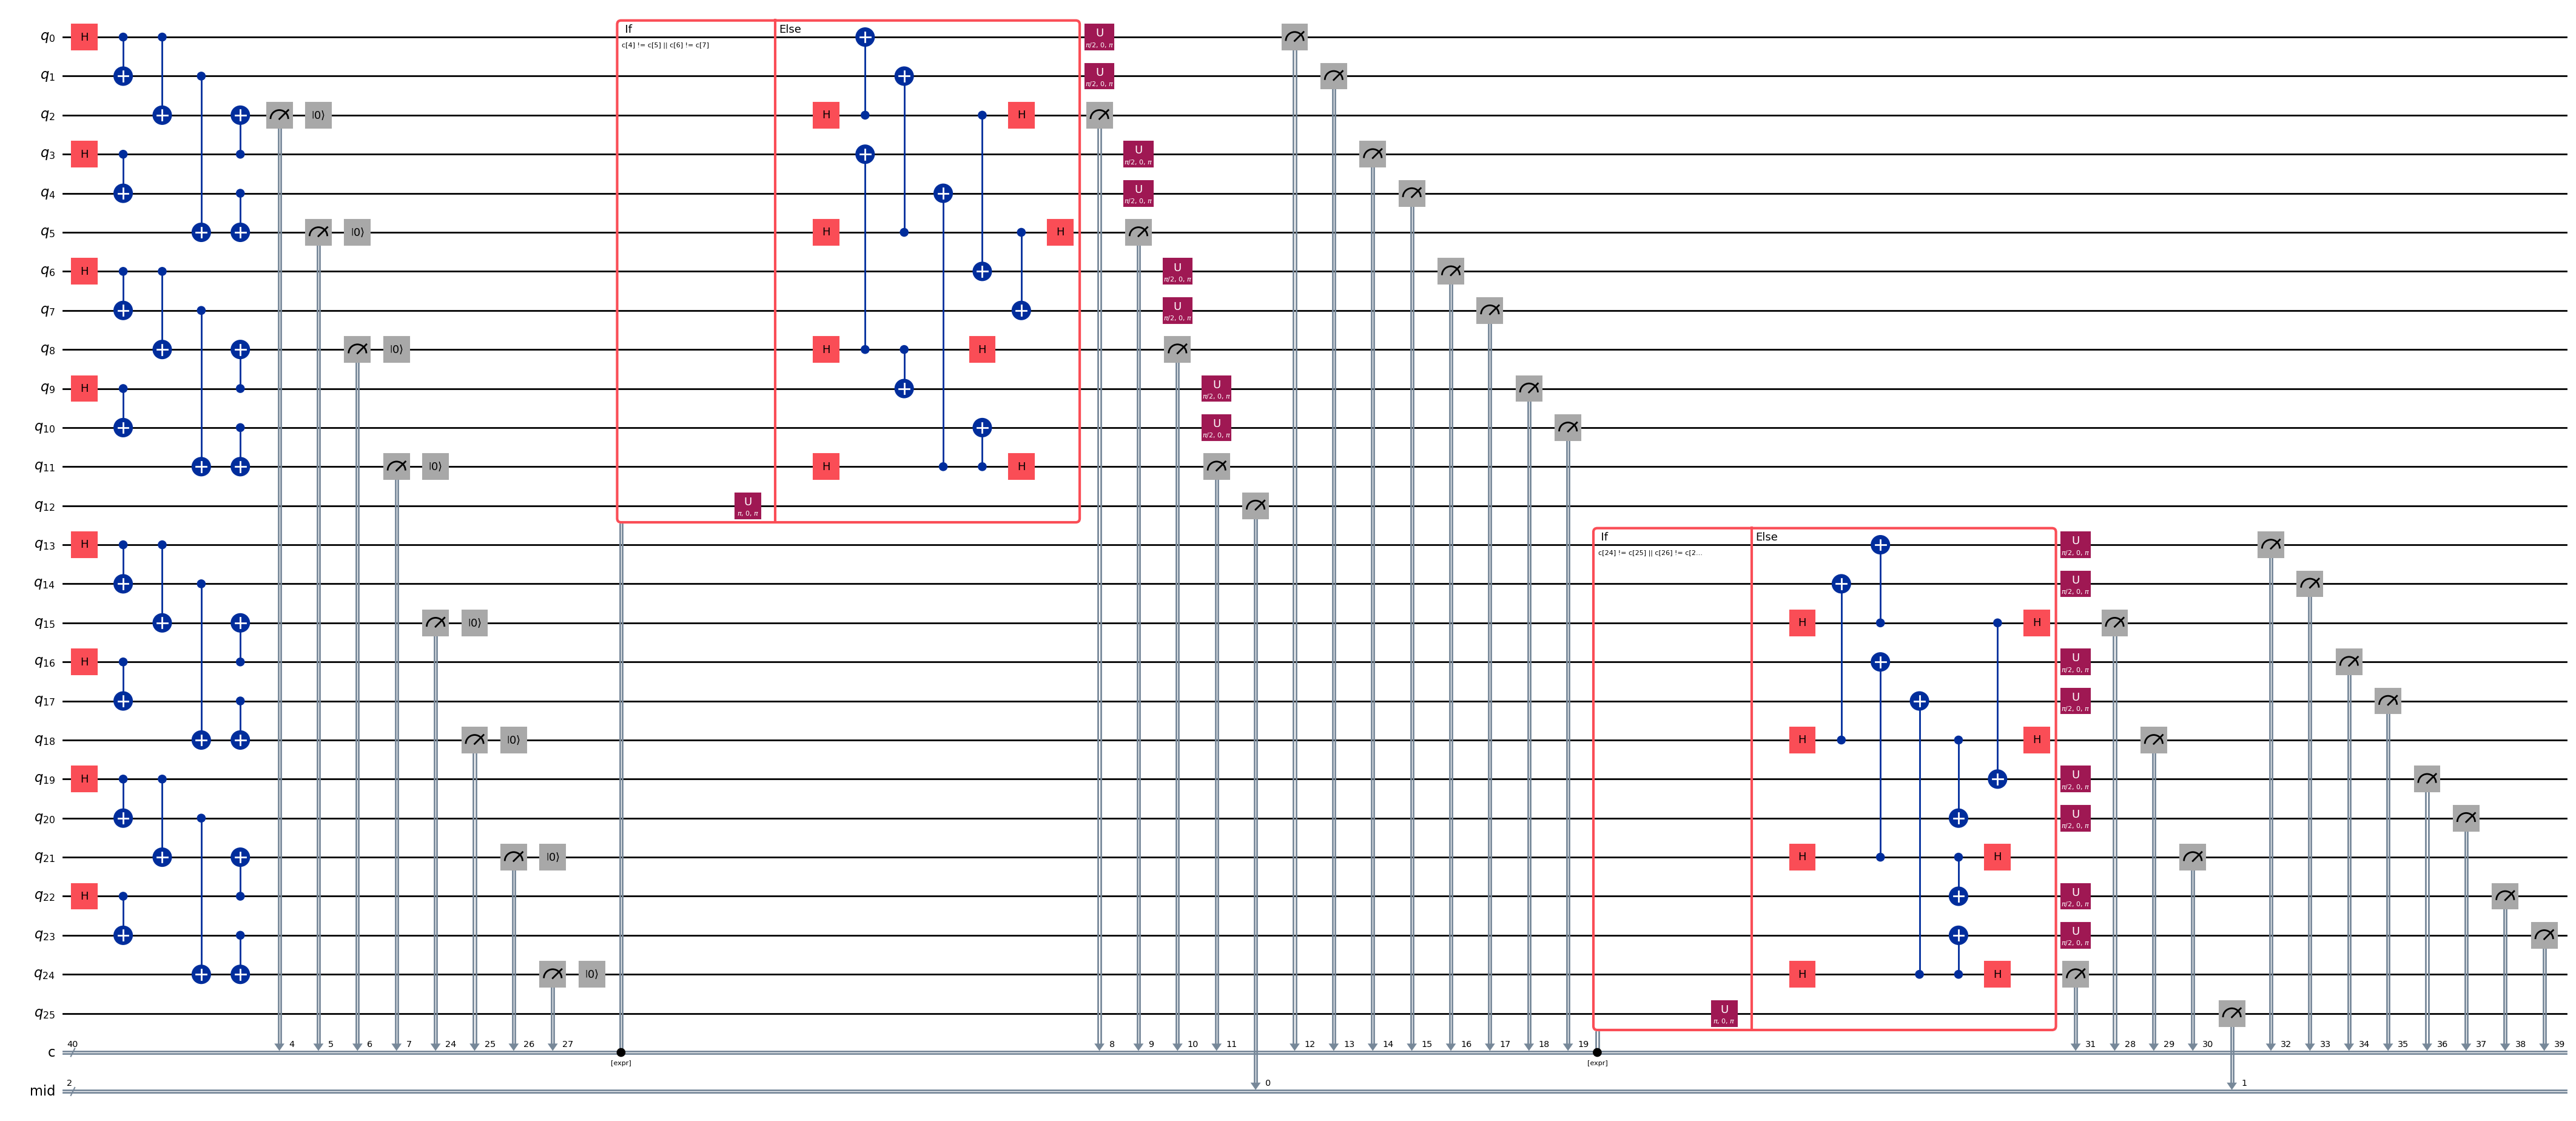

In [81]:
# n3 x 

qreg = QuantumRegister(26, name="q")
creg = ClassicalRegister(40, name="c")
mid = ClassicalRegister(2, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(4):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(2):
    start = i * 6 
    qc.append(qc_z2, range(start, start + 6), range(2))

m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    qc.reset(i)
    m_idx = m_idx + 1

# qc.barrier()

expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
with qc.if_test(expr_1) as else_:
    qc.x(12)
with else_:
    # qc.append(qc_z3, range(12), [8,9,10,11])
    qc.append(qc_x3, range(12), [8,9,10,11])

qc.measure(12, mid[0])

# m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    # qc.reset(i)
    m_idx = m_idx + 1

m_idx = 12
for i in range(12):
    if i in [2,5,8,11]:
        continue

    qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1


# ------------------------------

for i in range(4):
    start = i * 3 + 13
    qc.append(qc_x1_first, range(start, start + 3), [i])

for i in range(2):
    start = i * 6 + 13
    qc.append(qc_z2, range(start, start + 6), range(2))

m_idx += 4
for i in [15,18,21,24]:
    qc.measure(i, m_idx )
    qc.reset(i)
    m_idx = m_idx + 1

expr_1 = expr.logic_or( expr.not_equal(creg[24], creg[25]), expr.not_equal(creg[26], creg[27]) )
with qc.if_test(expr_1) as else_:
    qc.x(25)
with else_:
    # qc.append(qc_z3, range(12), [8,9,10,11])
    qc.append(qc_x3, range(13,25), [8,9,10,11])

qc.measure(25, mid[1])

for i in [15,18,21,24]:
    qc.measure(i, m_idx )
    m_idx = m_idx + 1

for i in range(13,25):
    if i in [15,18,21,24]:
        continue

    qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

# -------------------------------

qc = qc.decompose()

# qc.barrier()



qc_dynamic_n4_x_merged = qc
qc_dynamic_n4_x_merged.draw("mpl", fold=-1)

#### Metric: Number of Operations


In [82]:
polar_n4_x_meas_data.count_ops()

OrderedDict([('h', 32), ('cx', 32), ('measure', 32), ('reset', 16)])

In [83]:
tqc_h1_2.count_ops()

OrderedDict([('rz', 126),
             ('sx', 67),
             ('ecr', 30),
             ('measure', 17),
             ('x', 7),
             ('reset', 4),
             ('if_else', 1)])

If error are detected at layer 2, it will save:
- 6 measure
- 24 cx gates
- 12 reset gates
- 24 h gates

In [84]:
qc_dynamic_n4_x_merged.count_ops()

OrderedDict([('measure', 34),
             ('cx', 24),
             ('u', 16),
             ('h', 8),
             ('reset', 8),
             ('if_else', 2)])

#### Metric : Quantum Resource

In [85]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n4_x_meas_data)
# # tqc_h1_1 = pm_1.run(qc_h1)
# # tqc_h1_2 = pm_2.run(qc_h1)

# tqc_3 = pm.run(qc_dynamic_n4_x_merged)

# pubs_1 = [tqc_1]
# pubs_2 = [tqc_h1_1, tqc_h1_2]
# pubs_3 = [tqc_3]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
                
#              )
# sampler = Sampler(mode=backend, options=options)
# sampler.options.experimental = {"execution_path" : "gen3-experimental"}
# # job = sampler.run(pubs_1)
# # print(job.job_id(), hw_name)

# # job = sampler.run(pubs_2)
# # print(job.job_id(), hw_name)

# job = sampler.run(pubs_3)
# print(job.job_id(), hw_name)

In [86]:
# d20abeklir9s73ahoi50 ibm_brisbane normal (3s) --saved
# d20abeslir9s73ahoi60 ibm_brisbane dynamic (4s) --saved
# d20abf5ofqqs73dbh7og ibm_brisbane merged (3s) --saved

# d20adl3ni11c73fcfkpg ibm_brisbane normal (3s) 
# d20adldofqqs73dbh9tg ibm_brisbane dynamic (4s)
# d20ae0tofqqs73dbha80 ibm_brisbane merged (4s)

# -----------------------------------

# d1bdppav3z50008af5yg ibm_sherbrooke normal (25s) chores.acetone-0t@icloud.com -- saved
# d1ar9wzqf56g008zwm20 ibm_sherbrooke dynamic (11s) -- saved

# d1bdq1mv3z50008af600 ibm_sherbrooke normal (25s) chores.acetone-0t@icloud.com -- saved
# d1awj60n2txg008e7880 ibm_sherbrooke dynamic (12s) -- saved

# d1bdq4cmya70008nf8b0 ibm_sherbrooke normal (24s) chores.acetone-0t@icloud.com -- saved
# d1axm1gmya70008ncngg ibm_sherbrooke dynamic (12s) -- saved


# d1b6tf1qf56g008zz4cg ibm_sherbrooke dynamic (10s) -- saved

# ------------------------- merged --------------- chores.acetone-0t@icloud.com
# d1enapa3grvg008n8qmg ibm_sherbrooke dynamic merged (6s) -- saved
# d1f7n6wmya70008nvqxg ibm_sherbrooke dynamic merged (11s) -- saved
# d1f7yz3mya70008nvrqg ibm_sherbrooke dynamic merged (10s) -- saved
# d1f7z5wqf56g0080cff0 ibm_sherbrooke dynamic merged (11s) -- saved

In [87]:
# job_ids = ["d20adl3ni11c73fcfkpg"]

# save_results_to_file("bris_n4_x_normal", job_ids, service)
# # save_results_to_file("bris_n4_x_dynamic", job_ids, service)
# # save_results_to_file("bris_n4_x_merged", job_ids, service)

In [88]:
print("Normal :")
for res in load_results_from_file("bris_n4_x_normal"):
    print(res.metadata["execution"]["execution_spans"].duration)

print("Dynamic :")
for res in load_results_from_file("bris_n4_x_dynamic"):
    print(res.metadata["execution"]["execution_spans"].duration)

print("Dynamic merge:")
for res in load_results_from_file("bris_n4_x_merged"):
    print(res.metadata["execution"]["execution_spans"].duration)

Normal :
2.300277
2.345111
Dynamic :
3.905551
3.819519
Dynamic merge:
2.395617
3.384919


In [89]:
# load_results_from_file("n4_x_dynamic")[2].metadata

In [90]:
# job_normal = service.job("d1bdq4cmya70008nf8b0")
# result = job_normal.result()

result = load_results_from_file("bris_n4_x_normal")[1]
res_1 = result[0].data.c.get_counts()

n = 4
lstate = "X"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)


In [91]:
print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)

0 0 0 0 0.11023187999944639 -0.00829354199959198


In [92]:
from qiskit.primitives import SamplerPubResult, PrimitiveResult
from qiskit.primitives import SamplerPubResult, PrimitiveResult

# job_h1 = service.job("d1axm1gmya70008ncngg")
# result: PrimitiveResult = job_h1.result()

result = load_results_from_file("bris_n4_x_dynamic")[1]
res_1 = result[0].join_data().get_counts()
res_2 = result[1].join_data().get_counts()

list_res_1 = convert_dict_to_list(res_1)
list_res_2 = convert_dict_to_list(res_2)

res_pub:SamplerPubResult = result[0]

In [93]:
n = 3
lstate = "X"

tmp_start_time  = time.perf_counter()
creg_counts_1, total_discard_1 = update_count_dict_n3_t2_discard(res_1)
creg_counts_2, total_discard_2 = update_count_dict_n3_t2_discard(res_2)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time


print(get_logical_error_on_accepted_states(n, lstate, creg_counts_1))
print(get_logical_error_on_accepted_states(n, lstate, creg_counts_2))

list_clean_res_1 = convert_dict_to_list(creg_counts_1)
list_clean_res_2 = convert_dict_to_list(creg_counts_2)

print(len(list_clean_res_1), len(list_clean_res_2))


(607, 302, 543, 0.5024711696869851, 0.0860703790003754, 0.0006399209996743593)
(865, 429, 822, 0.5040462427745664, 0.10031399599938595, 0.02479342800052109)
1268 1913


In [94]:
final_combined_states = {}
clean_num = len(list_clean_res_1) if len(list_clean_res_1) < len(list_clean_res_2) else len(list_clean_res_2)
total_discard_d = total_discard_2 if total_discard_1 < total_discard_2 else total_discard_1

print(clean_num, total_discard_d)
for idx in range(clean_num):
    keys = []

    keys.append(list_clean_res_1[idx])
    keys.append(list_clean_res_2[idx])

    new_key = ""
    for idx in range(20): # this is the number of measurement each circuit
        idx = idx + 1

        for key in keys:
            new_key =  key[-idx] + new_key

    if new_key in final_combined_states:
        final_combined_states[new_key] = final_combined_states[new_key] + 1
    else:
        final_combined_states[new_key] = 1

n = 4
lstate = "X"
count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1, count_accept_h1/shots)

1268 3732


TypeError: Incorrect number of entries in input argument 'meas'

In [ ]:
# job_h1_m = service.job("d1f7z5wqf56g0080cff0")
# result_m: PrimitiveResult = job_h1_m.result()

result_m = load_results_from_file("bris_n4_x_merged")[1]
res_m = result_m[0].join_data().get_counts()

res_1 = {}
res_2 = {}

for key, value in res_m.items():
    key_1 = key[1] + key[-20:]
    key_2 = key[0] + key[-40:-20]
    mid = key[:2]

    if key_1 in res_1:
        res_1[key_1] += value
    else:
        res_1[key_1] = value

    if key_2 in res_2:
        res_2[key_2] += value
    else:
        res_2[key_2] = value

n = 3
lstate = "X"

tmp_start_time  = time.perf_counter()
creg_counts_1, total_discard_1 = update_count_dict_n3_t2_discard(res_1)
creg_counts_2, total_discard_2 = update_count_dict_n3_t2_discard(res_2)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time


print(get_logical_error_on_accepted_states(n, lstate, creg_counts_1))
print(get_logical_error_on_accepted_states(n, lstate, creg_counts_2))



In [ ]:
"123456"[:2]

In [ ]:
final_combined_states = {}
discard_count = 0

tmp_start_time  = time.perf_counter()
for key, value in res_m.items():
    keys = []

    key_1 = key[-20:]
    key_2 = key[-40:-20]
    mid_part = key[:2]

    keys.append(key_1)
    keys.append(key_2)

    if "1" in mid_part:
        discard_count += value
        continue


    new_key = ""
    for idx in range(20): # this is the number of measurement each circuit
        idx = idx + 1

        for key in keys:
            new_key =  key[-idx] + new_key

    if new_key in final_combined_states:
        final_combined_states[new_key] = final_combined_states[new_key] + 1
    else:
        final_combined_states[new_key] = 1

tmp_end_time = time.perf_counter()
dec_filter_time_m = tmp_end_time - tmp_start_time

print("Total Discard :", discard_count)

n = 4
lstate = "X"
count_accept_h1_m, count_logerror_h1_m, count_undecided_h1_m, ler_h1, detect_h1_m, decoding_h1_m = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

print(count_accept_h1_m, count_logerror_h1_m, count_undecided_h1_m, ler_h1, detect_h1_m, decoding_h1_m, count_accept_h1_m/ (shots-total_discard))

In [ ]:
print("time old : ", detect_normal + decoding_normal)
print("time new : ", detect_h1 + decoding_h1 + dec_filter_time)
print("time new merged : ", detect_h1_m + decoding_h1_m + dec_filter_time_m)

In [ ]:
print("old :", count_accept / shots, ler)
print("M1 :", count_accept_h1 / (shots - total_discard_d), ler_h1, total_discard_d)
print("M2 :", count_accept_h1_m / (shots - total_discard), ler_h1, total_discard)

print("Count accept : ", count_accept, count_accept_h1, count_accept_h1_m)
print("Count logerror : ", count_logerror, count_logerror_h1, count_logerror_h1_m)
print("Count undecided : ", count_undecided, count_undecided_h1, count_undecided_h1_m)

print("Time detect : ", detect_normal, detect_h1)
print("Time decoding : ", decoding_normal, decoding_h1)

The result from the normal procedure doesn't have any accepted state. Means we cannot commpare the decoding time

### $n=5$, $i=8$ for logical $|0\rangle$, b = 11100

In [ ]:
polar_n5_z_meas_data = polar_code_p2(5, True, "z", False)
polar_n5_z_meas_data.draw("mpl", fold=-1)

In [ ]:
# 00

qreg = QuantumRegister(7, name="q")
creg = ClassicalRegister(8, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(2):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

qc.barrier()

for i in range(1):
    start = i * 6 
    qc.append(qc_x2, range(start, start + 6), range(2))

m_idx = 2
for offset, qb in enumerate(range(2, 6, 3)): 
    qc.measure(qb, m_idx + offset)

m_idx += 2    

qc.barrier()

for i in (j for j in range(6) if j % 3 != 2):
    qc.measure(i, m_idx)
    m_idx += 1

qc_dynamic_n5_z = qc.decompose()
qc_dynamic_n5_z.draw("mpl", fold=-1)

In [ ]:
tqc = pm.run(qc_dynamic_n5_z)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


In [ ]:
def get_layers_n2(count):

    layers = []
    layer_1 = {}
    layer_2 = {}
    layer_3 = {}
    layer_mid = {}
    for key, value in count.items():
        key = key.lstrip()

        l1 = key[-2:]
        l2 = key[-4:-2]
        l3 = key[-8:-4]
        lm = key[0]

        if l1 not in layer_1:
            layer_1[l1] = value
        else:
            layer_1[l1] = layer_1[l1] + value

        if l2 not in layer_2:
            layer_2[l2] = value
        else:
            layer_2[l2] = layer_2[l2] + value

        if l3 not in layer_3:
            layer_3[l3] = value
        else:
            layer_3[l3] = layer_3[l3] + value

        if lm not in layer_mid:
            layer_mid[lm] = value
        else:
            layer_mid[lm] = layer_mid[lm] + value

    layers.append(layer_1)
    layers.append(layer_2)
    layers.append(layer_3)
    layers.append(layer_mid)

    return layers

In [ ]:
layers = get_layers_n2(count)

##### Metric: Number of Operations


In [ ]:
polar_n5_z_meas_data.count_ops()

In [ ]:
qc_dynamic_n5_z.count_ops()

Using the implementation above, we will have less:
- 16 hadamard gates
- 16 cnot gates
- 16 measured gates
- 16 reset gates

##### Metric : Quantum Resource

In [ ]:
tqc_h1s = [] 

tmp = pm.run(qc_dynamic_n5_z)
tqc_h1s.append(tmp)
print(tmp.count_ops())
# print(get_initial_layout_from_circuit(tmp))

used_qbts = get_initial_layout_from_circuit(tmp)

for i in range(7):

    # used_qbts = used_qubits(tqc_h1_1)
    

    cm = backend.coupling_map
    cm = build_idle_coupling_map(cm, used_qbts)

    pm_3 = generate_preset_pass_manager(
            optimization_level=3, backend=backend, coupling_map=cm
        )
    tmp = pm_3.run(qc_dynamic_n5_z)
    tqc_h1s.append(tmp)

    # print(tmp.count_ops())
    # print(get_initial_layout_from_circuit(tmp))

    qbts = get_initial_layout_from_circuit(tmp)

    for q in qbts:
        used_qbts.append(q)

print(used_qbts)


In [ ]:
len(tqc_h1s)

In [ ]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n5_z_meas_data)
# # tqc_h1_1 = pm_1.run(qc_h1)
# # tqc_h1_2 = pm_2.run(qc_h1)

# pubs_1 = [tqc_1]
# pubs_2 = tqc_h1s

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
                
#              )
# sampler = Sampler(mode=backend, options=options)
# sampler.options.experimental = {"execution_path" : "gen3-experimental"}

# job = sampler.run(pubs_1)
# print(job.job_id(), hw_name)

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [ ]:
# d20bihclir9s73ahpmp0 ibm_brisbane normal (3s)
# d20bihjni11c73fcgnag ibm_brisbane dynamic (12s)


# ---------------------------------------------

# d1b7pkav3z50008ae9k0 ibm_sherbrooke normal (37s) -- saved
# d1b7k2w5z6q0008pkk4g ibm_sherbrooke dynamic (11s) -- saved

# ------- chores.acetone-0t@icloud.com

# d1cpgt35z6q0008pr3n0 ibm_sherbrooke normal (34s) -- saved
# d1cpgv3v3z50008ajsr0 ibm_sherbrooke dynamic (19s) -- saved

# d1cqnvzqf56g00803seg ibm_sherbrooke normal (33s) -- saved
# d1cqnwqn2txg008eds9g ibm_sherbrooke dynamic (20s) -- saved

In [ ]:
job_ids = ["d20bihjni11c73fcgnag"]

# save_results_to_file("bris_n5_z_normal", job_ids, service)
save_results_to_file("bris_n5_z_dynamic", job_ids, service)

In [ ]:
print("Normal :")
for res in load_results_from_file("bris_n5_z_normal"):
    print(res.metadata["execution"]["execution_spans"].duration)

print("Dynamic :")
for res in load_results_from_file("bris_n5_z_dynamic"):
    print(res.metadata["execution"]["execution_spans"].duration)

In [ ]:
# job_normal = service.job("d1b7pkav3z50008ae9k0")
# result = job_normal.result()

result = load_results_from_file("bris_n5_z_normal")[0]
res_1 = result[0].data.c.get_counts()

n = 5
lstate = "Z"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)

print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)


In [ ]:
from qiskit.primitives import SamplerPubResult, PrimitiveResult

# job_h1 = service.job("d1b7k2w5z6q0008pkk4g")
# result: PrimitiveResult = job_h1.result()

count_memory = []
result = load_results_from_file("bris_n5_z_dynamic")[0]

tmp_start_time  = time.perf_counter()

for i in range(8):
    res_1 = result[i].join_data().get_counts()
    list_res_1 = convert_dict_to_list(res_1)

    count_memory.append(list_res_1)

tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time





In [ ]:
len(list_res_1)

In [ ]:
shots = 5000

final_combined_states = {}

tmp_start_time  = time.perf_counter()

for idx in range(shots):
    keys = []

    for i in range(8): # this is the number of repeating
        keys.append(count_memory[i][idx])

    new_key = ""
    for idx in range(8): # this is the number of measurement each circuit
        idx = idx + 1

        for key in keys:
            new_key =  key[-idx] + new_key

    if new_key in final_combined_states:
        final_combined_states[new_key] = final_combined_states[new_key] + 1
    else:
        final_combined_states[new_key] = 1


tmp_end_time = time.perf_counter()
combine_time = tmp_end_time - tmp_start_time




In [ ]:
n = 5
lstate = "Z"

count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

In [ ]:
print("time old : ", detect_normal + decoding_normal)
print("time new : ", detect_h1 + decoding_h1 + combine_time)

In [ ]:
print("old :", count_accept / shots, ler)
print("M1 :", count_accept_h1 / shots, ler_h1)

print("Count accept : ", count_accept, count_accept_h1)
print("Count logerror : ", count_logerror, count_logerror_h1)
print("Count undecided : ", count_undecided, count_undecided_h1)

print("Time detect : ", detect_normal, detect_h1)
print("Time decoding : ", decoding_normal, decoding_h1)

### $n=5$, $i=7$ for logical $|+\rangle$, b = 01100

In [ ]:
polar_n5_x_meas_data = polar_code_p2(5, True, "x", False)
polar_n5_x_meas_data.draw("mpl", fold=-1)

In [ ]:
qreg = QuantumRegister(49, name="q")
creg = ClassicalRegister(112, name="c")
mid = ClassicalRegister(2, name="mid")
qc = QuantumCircuit(qreg,creg,mid)
m_idx = 0

for i in range(16):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(8):
    start = i * 6
    qubits = range(start, start + 6)       
    clbits = range(2 * i + 4, 2 * i + 6)  
    qc.append(qc_z2, qubits, clbits)

# fix this it shold start from 16
m_idx = 16
for offset, qb in enumerate(range(2, 48, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

# expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
expr_1 = expr.logic_or(
    expr.logic_or(
    expr.logic_or( expr.not_equal(creg[16], creg[17]), expr.not_equal(creg[18], creg[19]) ),
    expr.logic_or( expr.not_equal(creg[20], creg[21]), expr.not_equal(creg[22], creg[23]) )
    ),
    expr.logic_or(
    expr.logic_or( expr.not_equal(creg[24], creg[25]), expr.not_equal(creg[26], creg[27]) ),
    expr.logic_or( expr.not_equal(creg[28], creg[29]), expr.not_equal(creg[30], creg[31]) )
    )
)
with qc.if_test(expr_1) as else_:
    qc.x(48)

with else_:
    for i in range(4):    
        start = i * 12
        qubits = range(start, start + 12)
        clbits = range(4)
        qc.append(qc_z3, qubits, clbits)

qc.measure(48, mid[0])


for offset, qb in enumerate(range(2, 48, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

expr_2 = expr.logic_and(  
            expr.logic_and( 
                expr.logic_or( 
                    expr.logic_and(
                        expr.logic_and(expr.equal(creg[32], creg[34]) , expr.equal(creg[33], creg[35])),
                        expr.logic_and(expr.equal(creg[36], creg[38]) , expr.equal(creg[37], creg[39])) 
                    ),
                    expr.logic_and(
                        expr.logic_and(expr.not_equal(creg[32], creg[34]) , expr.not_equal(creg[33], creg[35])),
                        expr.logic_and(expr.not_equal(creg[36], creg[38]) , expr.not_equal(creg[37], creg[39])) 
                    )
                ),
                expr.logic_or( 
                    expr.logic_and(
                        expr.logic_and(expr.equal(creg[40], creg[42]) , expr.equal(creg[41], creg[43])),
                        expr.logic_and(expr.equal(creg[44], creg[46]) , expr.equal(creg[45], creg[47])) 
                    ),
                    expr.logic_and(
                        expr.logic_and(expr.not_equal(creg[40], creg[42]) , expr.not_equal(creg[41], creg[43])),
                        expr.logic_and(expr.not_equal(creg[44], creg[46]) , expr.not_equal(creg[45], creg[47])) 
                    )
                )
            ),
            expr.equal(mid, 0b00)
        )

    
with qc.if_test(expr_2) as else_:
    for i in range(2):    
        start = i * 24
        qubits = range(start, start + 24)
        clbits = range(8)
        qc.append(qc_x4, qubits, clbits)

with else_:
    qc.x(48)

qc.measure(48, mid[1])

for offset, qb in enumerate(range(2, 48, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

expr_3 = expr.equal(mid, 0b00)
with qc.if_test(expr_3):
    for i in range(1):    
        start = i * 48
        qubits = range(start, start + 48)
        clbits = range(16)
        qc.append(qc_x5, qubits, clbits)

for offset, qb in enumerate(range(2, 48, 3)): 
    qc.measure(qb, m_idx + offset)

m_idx = m_idx + offset + 1

# qc.barrier()

qc = qc.decompose()

for i in (j for j in range(48) if j % 3 != 2):
    qc.h(i)
    qc.measure(i, m_idx)
    m_idx += 1

qc_dynamic_n5_x = qc
qc_dynamic_n5_x.draw("mpl", fold=-1)

In [ ]:
m_idx

#### Metric: Number of Operations


In [ ]:
polar_n5_x_meas_data.count_ops()

In [ ]:
qc_dynamic_n5_x.count_ops()

If an error is detected in the second layer, we will save:
- 46 measures gates
- 112 cx gates
- 112 hadamard gates

#### Metric : Quantum Resource

In [ ]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n5_x_meas_data)
# tqc_2 = pm.run(qc_dynamic_n5_x)

# pubs_1 = [tqc_1]
# pubs_2 = [tqc_2]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
#              )
# sampler = Sampler(mode=backend, options=options) 
# sampler.options.experimental = {"execution_path" : "gen3-experimental"}

# # job = sampler.run(pubs_1)
# # print(job.job_id(), hw_name)

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [ ]:
# d20blgslir9s73ahppf0 ibm_brisbane normal (4s) -- saved
# d20bm2s3s4ss73ckvorg ibm_brisbane dynamic error 

# ------------------

# d1bapzkqf56g008zzsv0 ibm_sherbrooke normal (1m22s) -- saved
# d1bb77mv3z50008aevv0 ibm_sherbrooke dynamic (14s) -- saved

# chores.acetone-0t@icloud.com
# d1bbfcdn2txg008e9y60 ibm_sherbrooke dynamic (7s) -- saved

In [ ]:
# job_ids = ["d20blgslir9s73ahppf0"]

# save_results_to_file("bris_n5_x_normal", job_ids, service)
# # save_results_to_file("n5_x_dynamic", job_ids, service)

In [ ]:
print("Normal :")
for res in load_results_from_file("n5_x_normal"):
    print(res.metadata["execution"]["execution_spans"].duration)

print("Dynamic :")
for res in load_results_from_file("n5_x_dynamic"):
    print(res.metadata["execution"]["execution_spans"].duration)

In [ ]:
# job_normal = service.job("d1bapzkqf56g008zzsv0")
# result = job_normal.result()

result = load_results_from_file("n5_x_normal")[0]
res_1 = result[0].data.c.get_counts()

n = 5
lstate = "X"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)

print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)


In [ ]:
detect_normal + decoding_normal

In [ ]:
def update_count_dict_n5_t2_discard(count_ideal):
    creg_counts = {}
    total_discard = 0
    for key, value in count_ideal.items():
        key = key.replace(" ", "")  # remove spaces, just in case
        creg_part = key[-104:] + "00000000" 
        mid_part = key[:1]
        
        if "1" in mid_part:
            total_discard = total_discard + value
            continue

        creg_counts[creg_part] = creg_counts.get(creg_part, 0) + value

    print("Total discarded :", total_discard)
    return creg_counts, total_discard


In [ ]:
# # chores.acetone-0t@icloud.com
# token = "108bce3fd4c7a849d27b3eb41aad83f0c0a4f523cf6f3aa9735390405604613e51b9fc092722ef709554d9bb88a9dccd882eadeeadc590e554a8447fef8c8f97"
# QiskitRuntimeService.save_account(channel="ibm_quantum", token=token, overwrite=True)
# service = QiskitRuntimeService(channel="ibm_quantum", token=token)
# # hw_name = "ibm_brisbane"
# hw_name = "ibm_sherbrooke"
# backend = service.backend(hw_name)

# sim_ideal = AerSimulator()
# sim_noisy = AerSimulator.from_backend(backend)

In [ ]:
# job_h1 = service.job("d1bbfcdn2txg008e9y60")
# result_h1 = job_h1.result()

result_h1 = load_results_from_file("n5_x_dynamic")[0]

res_1 = result_h1[0].join_data().get_counts()

tmp_start_time  = time.perf_counter()
creg_counts, total_discard = update_count_dict_n5_t2_discard(res_1)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time


count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)

print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 )

In [ ]:
detect_h1 + decoding_h1 + dec_filter_time

### $n=6$, $i=23$ for logical $|0\rangle$, b = 011010

In [ ]:
polar_n6_z_meas_data = polar_code_p2(6, True, "z", False)
polar_n6_z_meas_data.draw("mpl", fold=-1)

In [ ]:
polar_n6_z_meas_data.count_ops()

### $n=6$, $i=22$ for logical $|+\rangle$, b = 101010

In [ ]:
polar_n6_x_meas_data = polar_code_p2(6, True, "x", False)
polar_n6_x_meas_data.draw("mpl", fold=-1)

In [ ]:
polar_n6_x_meas_data.count_ops()

### Summary


These are the summary of the reduction of number of gates being executed if error is detected on the Layer 2


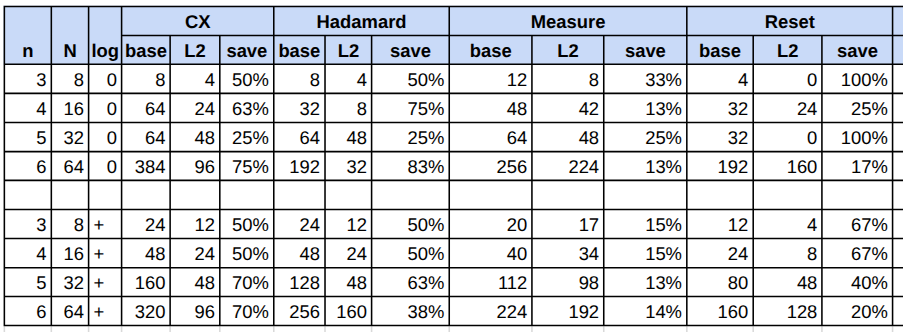

With this reduction on the number of executed gates, we would expect the reduction of the usage of quantum resource

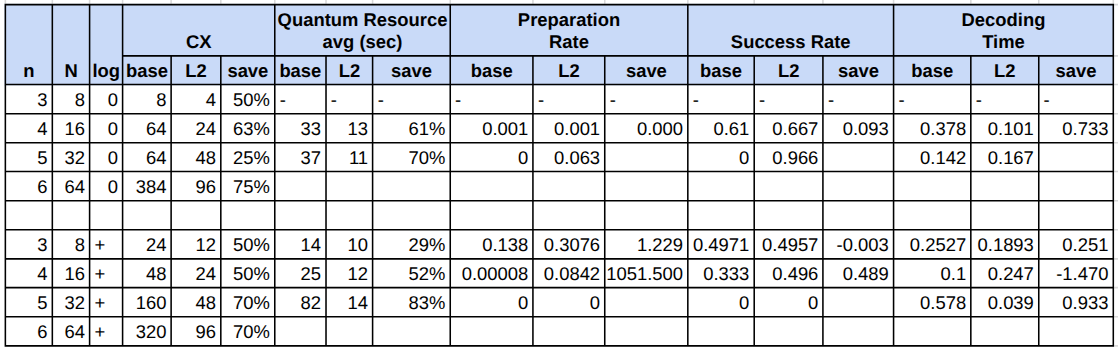

In [ ]:
list_circuit_name = ["polar_all_meas_n3_x", "polar_all_meas_n3_x", "polar_all_meas_n4_x", "polar_all_meas_n4_x",
                     "polar_all_meas_n5_x", "polar_all_meas_n5_x", # "polar_all_meas_n6_x", "polar_all_meas_n6_x",
                     "polar_all_meas_n3_z", "polar_all_meas_n3_z", "polar_all_meas_n4_z", "polar_all_meas_n4_z",
                     "polar_all_meas_n5_z", "polar_all_meas_n5_z", # "polar_all_meas_n6_z", "polar_all_meas_n6_z",
                     ]
list_code_length = [3, 3, 4, 4, 5, 5, # 6, 6,
                    3, 3, 4, 4, 5, 5, # 6, 6
                    ]
list_type = ["normal", "dynamic"]*6

list_count_cx = [24, 12, 48, 24, 160, 48, # 320, 96,
                 8,   4, 64, 24, 64, 48, # 384, 96
                 ]

# list_prep_rate = [0.138, 0.3076, 0.00008, 0.0842, 0, 0, 0, 0,
#                   0, 0, 0.001, 0.001, 0, 0.063, 0, 0
#                  ]


#### Calculate Result

In [ ]:
def calculate_result_n3_z_dynamic(result):
    count_memory = []

    shots = 5000
    for i in range(4):
        res_1 = result[i].join_data().get_counts()
        list_res_1 = convert_dict_to_list(res_1)

        count_memory.append(list_res_1)
        shots = len(list_res_1)

    final_combined_states = {}

    tmp_start_time  = time.perf_counter()

    for idx in range(shots):
        keys = []

        for i in range(4): # this is the number of repeating
            keys.append(count_memory[i][idx])

        new_key = ""
        for idx in range(3): # this is the number of measurement each circuit
            idx = idx + 1

            for key in keys:
                new_key =  key[-idx] + new_key

        if new_key in final_combined_states:
            final_combined_states[new_key] = final_combined_states[new_key] + 1
        else:
            final_combined_states[new_key] = 1

    n = 3
    lstate = "Z"

    count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

    tmp_end_time = time.perf_counter()
    combine_time = tmp_end_time - tmp_start_time


    
    return (count_accept_h1, 0, ler_h1)

# print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1, count_accept_h1/clean_num)

In [ ]:
def calculate_result_n4_x_dynamic(result):
    res_1 = result[0].join_data().get_counts()
    res_2 = result[1].join_data().get_counts()

    # shots = sum(res_1.values())
    # list_res_1 = convert_dict_to_list(res_1)
    # list_res_2 = convert_dict_to_list(res_2)
    # res_pub:SamplerPubResult = result[0]

    n = 3
    lstate = "X"

    tmp_start_time  = time.perf_counter()
    creg_counts_1, total_discard_1 = update_count_dict_n3_t2_discard(res_1)
    creg_counts_2, total_discard_2 = update_count_dict_n3_t2_discard(res_2)
    tmp_end_time = time.perf_counter()
    dec_filter_time = tmp_end_time - tmp_start_time

    list_clean_res_1 = convert_dict_to_list(creg_counts_1)
    list_clean_res_2 = convert_dict_to_list(creg_counts_2)

    final_combined_states = {}
    clean_num = len(list_clean_res_1) if len(list_clean_res_1) < len(list_clean_res_2) else len(list_clean_res_2)

    total_discard = total_discard_1 if len(list_clean_res_1) < len(list_clean_res_2) else total_discard_2

    # print(clean_num, total_discard, shots)
    for idx in range(clean_num):
        keys = []

        keys.append(list_clean_res_1[idx])
        keys.append(list_clean_res_2[idx])

        new_key = ""
        for idx in range(20): # this is the number of measurement each circuit
            idx = idx + 1

            for key in keys:
                new_key =  key[-idx] + new_key

        if new_key in final_combined_states:
            final_combined_states[new_key] = final_combined_states[new_key] + 1
        else:
            final_combined_states[new_key] = 1

    n = 4
    lstate = "X"
    count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

    return (count_accept_h1, total_discard, ler_h1)

# print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1, count_accept_h1/clean_num)

In [ ]:
def calculate_result_n5_z_dynamic(result):
    count_memory = []

    shots = 5000
    for i in range(8):
        res_1 = result[i].join_data().get_counts()
        list_res_1 = convert_dict_to_list(res_1)

        count_memory.append(list_res_1)
        shots = len(list_res_1)

    final_combined_states = {}

    tmp_start_time  = time.perf_counter()

    for idx in range(shots):
        keys = []

        for i in range(8): # this is the number of repeating
            keys.append(count_memory[i][idx])

        new_key = ""
        for idx in range(8): # this is the number of measurement each circuit
            idx = idx + 1

            for key in keys:
                new_key =  key[-idx] + new_key

        if new_key in final_combined_states:
            final_combined_states[new_key] = final_combined_states[new_key] + 1
        else:
            final_combined_states[new_key] = 1

    n = 5
    lstate = "Z"

    count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

    tmp_end_time = time.perf_counter()
    combine_time = tmp_end_time - tmp_start_time


    
    return (count_accept_h1, 0, ler_h1)

# print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1, count_accept_h1/clean_num)

In [ ]:
def get_avgs_result(n, lstate, mid_idx, creg_idx):
    res = []

    avg_n3_x_normal = 0
    shots_n3_x_normal = 0
    ler_n3_x_normal = 0

    avg_n3_x_dynamic = 0
    shots_n3_x_dynamic = 0
    ler_n3_x_dynamic = 0

    circuit_type = f"n{n}_{lstate.lower()}"
    print(circuit_type)

    for result in load_results_from_file(f"{circuit_type}_normal"):
        res_1 = result[0].data.c.get_counts()
        shots = sum(res_1.values())


        count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)

        # print(count_accept / shots, shots, count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)

        avg_n3_x_normal += count_accept / shots
        shots_n3_x_normal += shots
        ler_n3_x_normal += ler

    avg_n3_x_normal /= len(load_results_from_file(f"{circuit_type}_normal"))
    ler_n3_x_normal = 1 - (ler_n3_x_normal / len(load_results_from_file(f"{circuit_type}_normal")))
    res.append((np.round(avg_n3_x_normal, 3), shots_n3_x_normal, ler_n3_x_normal))

    for result_h1 in load_results_from_file(f"{circuit_type}_dynamic"):
        
        if n == 4 and lstate == "X":
            count_accept_h1, total_discard, ler_h1 = calculate_result_n4_x_dynamic(result_h1)

            avg_n3_x_dynamic += count_accept_h1 / (shots - total_discard)
            shots_n3_x_dynamic += (shots - total_discard)
            ler_n3_x_dynamic += ler_h1

        # elif n == 4 and lstate == "Z":
        #     res_1 = result_h1[0].join_data().get_counts()

        #     tmp_start_time  = time.perf_counter()
        #     creg_counts, total_discard = update_count_dict_n4_t2_discard(res_1)
        #     undetected_counts = shots - total_discard

        #     tmp_end_time = time.perf_counter()
        #     dec_filter_time = tmp_end_time - tmp_start_time
        #     count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)

        #     avg_n3_x_dynamic += count_accept_h1 / (shots - total_discard)
        #     shots_n3_x_dynamic += (shots - total_discard)

        elif n == 3 and lstate == "Z":
            count_accept_h1, total_discard, ler_h1 = calculate_result_n3_z_dynamic(result_h1)

            avg_n3_x_dynamic += count_accept_h1 / (shots - total_discard)
            shots_n3_x_dynamic += (shots - total_discard)
            ler_n3_x_dynamic += ler_h1

        elif n == 5 and lstate == "Z":
            count_accept_h1, total_discard, ler_h1 = calculate_result_n5_z_dynamic(result_h1)

            avg_n3_x_dynamic += count_accept_h1 / (shots - total_discard)
            shots_n3_x_dynamic += (shots - total_discard)
            ler_n3_x_dynamic += ler_h1
        
            
        elif n == 5 and lstate == "X":
            res_1 = result_h1[0].join_data().get_counts()

            tmp_start_time  = time.perf_counter()
            creg_counts, total_discard = update_count_dict_n5_t2_discard(res_1)
            undetected_counts = shots - total_discard

            tmp_end_time = time.perf_counter()
            dec_filter_time = tmp_end_time - tmp_start_time
            count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)

            avg_n3_x_dynamic += count_accept_h1 / (shots - total_discard)
            shots_n3_x_dynamic += (shots - total_discard)
            ler_n3_x_dynamic += ler_h1
            
        else:

            res_1 = result_h1[0].join_data().get_counts()

            tmp_start_time  = time.perf_counter()
            creg_counts, total_discard = update_count_dict_discard(mid_idx, creg_idx, res_1)
            undetected_counts = shots - total_discard

            tmp_end_time = time.perf_counter()
            dec_filter_time = tmp_end_time - tmp_start_time
            count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)

            avg_n3_x_dynamic += count_accept_h1 / (shots - total_discard)
            shots_n3_x_dynamic += (shots - total_discard)
            ler_n3_x_dynamic += ler_h1

    avg_n3_x_dynamic /= len(load_results_from_file(f"{circuit_type}_dynamic"))
    ler_n3_x_dynamic = 1 - (ler_n3_x_dynamic / len(load_results_from_file(f"{circuit_type}_dynamic")))
    # avg_n3_x_dynamic, shots_n3_x_dynamic, (shots_n3_x_normal - shots_n3_x_dynamic) / shots_n3_x_dynamic, (shots_n3_x_normal - shots_n3_x_dynamic) / shots_n3_x_normal

    res.append((np.round(avg_n3_x_dynamic, 3), shots_n3_x_dynamic, ler_n3_x_dynamic))

    return res



In [ ]:
# for result_h1 in load_results_from_file("n4_x_dynamic"):
#     print(calculate_result_n4_x_dynamic(result_h1))

In [ ]:
res_n3_x = get_avgs_result(3, "X", 0, 1)
res_n3_z = get_avgs_result(3, "Z", 0, 1)
res_n4_x = get_avgs_result(4, "X", 0, 1)
res_n4_z = get_avgs_result(4, "Z", 0, 2)
res_n5_x = get_avgs_result(5, "X", 0, 1)
res_n5_z = get_avgs_result(5, "Z", 0, 1)

print(res_n5_z)

In [ ]:
res_n3_x[0][0]

In [ ]:
list_prep_rate = [res_n3_x[0][0], res_n3_x[1][0], res_n4_x[0][0], res_n4_x[1][0], 
                  res_n5_x[0][0], res_n5_x[1][0],
                  res_n3_z[0][0], res_n3_z[1][0], res_n4_z[0][0], res_n4_z[1][0], 
                  res_n5_z[0][0], res_n5_z[1][0], 
                 ]

list_shots = [res_n3_x[0][1], res_n3_x[1][1], res_n4_x[0][1], res_n4_x[1][1], 
                res_n5_x[0][1], res_n5_x[1][1], 
                res_n3_z[0][1], res_n3_z[1][1], res_n4_z[0][1], res_n4_z[1][1], 
                res_n5_z[0][1], res_n5_z[1][1], 
                ]

list_ler = [res_n3_x[0][2], res_n3_x[1][2], res_n4_x[0][2], res_n4_x[1][2], 
                res_n5_x[0][2], res_n5_x[1][2], 
                res_n3_z[0][2], res_n3_z[1][2], res_n4_z[0][2], res_n4_z[1][2], 
                res_n5_z[0][2], res_n5_z[1][2], 
                ]

# list_prep_rate = [0.138, 0.3076, 0.00008, 0.0842, 0, 0, 0, 0,
#                   0, 0, 0.001, 0.001, 0, 0.063, 0, 0
#                  ]

In [ ]:
df_result = pd.DataFrame({
        'circuit_name': list_circuit_name,
        'code_length': list_code_length,
        'type': list_type,
        'count_cx': list_count_cx,
        'prep_rate': list_prep_rate,
        'shots': list_shots,
        'ler': list_ler
    })

df_result

In [ ]:
# x_labels = None
# # x_labels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0,]

# df_normal_x  = df_result.loc[(df_result['type'] == "normal")  & (df_result['circuit_name'].str.contains('_x'))].copy()
# df_dynamic_x = df_result.loc[(df_result['type'] == "dynamic") & (df_result['circuit_name'].str.contains('_x'))].copy()
# df_normal_z  = df_result.loc[(df_result['type'] == "normal")  & (df_result['circuit_name'].str.contains('_z'))].copy()
# df_dynamic_z = df_result.loc[(df_result['type'] == "dynamic") & (df_result['circuit_name'].str.contains('_z'))].copy()

# y_values = ['normal', 'dynamic']
# legends = ["|+>, Normal", 
#            "|+>, Dynamic",
#            "|0>, Normal", 
#            "|0>, Dynamic"
#            ]
# x_lim=[2.9, 6.1]
# y_lim=[0,400]
# legend_position=(0.01,0.01)
# hw_name = "ibm_sherbrooke"
# title="Comparison of CX count"
# x_index = "noise_level"

# # print(y_values)
# x_labels = None
# dfs = [df_normal_x, df_dynamic_x, df_normal_z, df_dynamic_z]

# plt = show_figure_by_opt_combined(
#     dfs, "type", y_values, "count_cx", "Count CX", f"Code length (n) ", 
#     legend=True, legends=legends, figsize=(8,4), reindex=None, x_index = "code_length", 
#     x_labels=x_labels, x_lim=x_lim, y_lim=y_lim,legend_position=(1.05,0.01),
#     circuit_name = "count_cx_comparison", hw_name = f"{hw_name}", title=title, log_val=False)

In [ ]:
x_labels = None
# x_labels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0,]

df_normal_x  = df_result.loc[(df_result['type'] == "normal")  & (df_result['circuit_name'].str.contains('_x'))].copy()
df_dynamic_x = df_result.loc[(df_result['type'] == "dynamic") & (df_result['circuit_name'].str.contains('_x'))].copy()
df_normal_z  = df_result.loc[(df_result['type'] == "normal")  & (df_result['circuit_name'].str.contains('_z'))].copy()
df_dynamic_z = df_result.loc[(df_result['type'] == "dynamic") & (df_result['circuit_name'].str.contains('_z'))].copy()

y_values = ['normal', 'dynamic']
legends = ["|+>, Normal", 
           "|+>, Dynamic",
           "|0>, Normal", 
           "|0>, Dynamic"
           ]
x_lim=[2.9, 5.1]
y_lim=[-0.01,1.02]
legend_position=(0.01,0.01)
hw_name = "ibm_sherbrooke"
title="Comparison of Preparation Rate"
x_index = "noise_level"

# print(y_values)
x_labels = None
dfs = [df_normal_x, df_dynamic_x, df_normal_z, df_dynamic_z]

plt = show_figure_by_opt_combined(
    dfs, "type", y_values, "prep_rate", "Preparation rate", f"Code length (n) ", 
    legend=True, legends=legends, figsize=(8,4), reindex=None, x_index = "code_length", 
    x_labels=x_labels, x_lim=x_lim, y_lim=y_lim,legend_position=(0.75,0.68),
    circuit_name = "real_prep_rate", hw_name = f"{hw_name}", title=title, log_val=False)

In [ ]:
x_labels = None
# x_labels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0,]

df_normal_x  = df_result.loc[(df_result['type'] == "normal")  & (df_result['circuit_name'].str.contains('_x'))].copy()
df_dynamic_x = df_result.loc[(df_result['type'] == "dynamic") & (df_result['circuit_name'].str.contains('_x'))].copy()
df_normal_z  = df_result.loc[(df_result['type'] == "normal")  & (df_result['circuit_name'].str.contains('_z'))].copy()
df_dynamic_z = df_result.loc[(df_result['type'] == "dynamic") & (df_result['circuit_name'].str.contains('_z'))].copy()

y_values = ['normal', 'dynamic']
legends = ["|+>, Normal", 
           "|+>, Dynamic",
           "|0>, Normal", 
           "|0>, Dynamic"
           ]
x_lim=[2.9, 5.1]
y_lim=[-0.01,1.02]
legend_position=(0.01,0.01)
hw_name = "ibm_sherbrooke"
title="Comparison of LER"
x_index = "noise_level"

# print(y_values)
x_labels = None
dfs = [df_normal_x, df_dynamic_x, df_normal_z, df_dynamic_z]

plt = show_figure_by_opt_combined(
    dfs, "type", y_values, "ler", "Logical Error Rate", f"Code length (n) ", 
    legend=True, legends=legends, figsize=(8,4), reindex=None, x_index = "code_length", 
    x_labels=x_labels, x_lim=x_lim, y_lim=y_lim,legend_position=(0.40,0.02),
    circuit_name = "real_ler", hw_name = f"{hw_name}", title=title, log_val=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Labels
# labels = ['N=8, log. |0>', 'N=16, log. |0>', 'N=32, log. |0>', 
#           'N=8, log. |+>', 'N=16, log. |+>', 'N=32, log. |+>']
labels = ['N=8', 'N=16', 'N=32', 
          'N=8', 'N=16', 'N=32']

# Data
normal_qr = [9, 99, 111, 42, 75, 246]
dynamic_qr = [9, 166, 33, 50, 66, 45]

normal_pr  = [1, 0.001, 0.00001, 0.138, 0.00008, 0]
dynamic_pr = [1, 0.004, 0.063  , 0.507, 0.173  , 0]

# Compute normalized improvement
improv_qr = [(n - d)/n if n != 0 else 0 for n, d in zip(normal_qr, dynamic_qr)]  # lower is better
improv_pr = [(d - n)/n if n != 0 else 0 for n, d in zip(normal_pr, dynamic_pr)]  # higher is better

# Compute speedup factor for QR (dynamic/normal)
speedup_qr = [d / n if n != 0 else 0 for n, d in zip(normal_qr, dynamic_qr)]

x = np.arange(len(labels))
width = 0.37  # slightly wider for clarity

fig, ax = plt.subplots(figsize=(7, 5))

# Bars
# '#377eb8', '#ff7f00'
bars_qr = ax.bar(x - width/2, improv_qr, width, label='Adjusted Quantum Resource ($QR_{adj}$)', color='#377eb8')
bars_pr = ax.bar(x + width/2, improv_pr, width, label='Preparation Rate ($p_{prep}$)', color='#ff7f00')

# Zero line
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Middle line
ax.axvline(2.5, color='black', linestyle='--', linewidth=1)

# Add left half background
ax.axvspan(xmin=ax.get_xlim()[0], xmax=2.5, facecolor='lightblue', alpha=0.15) # x=0 is center
ax.text(x=-0.5, y=-1.25, s="Logical $|0 \\rangle $", color="blue")

# Add right half background
ax.axvspan(xmin=2.5, xmax=ax.get_xlim()[1], facecolor='lightcoral', alpha=0.15) # x=0 is center
ax.text(x=4.5, y=-1.25, s="Logical $|+ \\rangle $", color="red")

# Labels and title
ax.set_ylabel('Normalized Improvement (Dynamic vs Normal)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, ha='center')
ax.legend()

# Add value labels above bars
def add_labels(bars, values, format_str='{:.2f}'):
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.annotate(format_str.format(val),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars_qr, improv_qr)
add_labels(bars_pr, improv_pr)

# Add speedup factors for QR
for bar, factor in zip(bars_qr, speedup_qr):
    ax.annotate(f'×{factor:.2f}', 
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.2),
                xytext=(0, -14), 
                textcoords="offset points",
                ha='center', va='top', fontsize=9, color='blue')

# Highlight extreme cases with arrows
# Case 1: N=8, |0>
ax.annotate('No improvement', xy=(x[0], 0), xytext=(-40, 40),
            textcoords='offset points', arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

# Case 2: N=32, |+>
ax.annotate('Too noisy\n(no improvement)', xy=(x[5], 0), xytext=(-60, -40),
            textcoords='offset points', arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

# Tight layout and save
plt.ylim(-1.5, 4.5)
plt.tight_layout()
plt.savefig("./output/proposal_1/result_real_backend_annotated.png", dpi=300, bbox_inches='tight')
plt.show()


#### Formula

To calculate the number of operations of state preparation, you can use this formula.

1. Calculate the CX gates

$$ s_m = \sum^n_{j=1}\prod^j_{k=1}{b_k},  \text{ where } b_k =  \left \lfloor \frac{i - d}{2^{k-1}} \right \rfloor \text{mod } 2$$

- $s_m$ is the skip-count of measurement, 
- $i = n(i)$ is the position where the qubit is frozen, 
- $b_k$ is the binary number of $i$ with LSB on the left, 
- $d = 1$ for logical 0, and $d = 1$ for logical +

$$ N_{CX} = (n - s_m)2^n $$

2. Calculate the hadamard gates

$$ z = \sum^n_{k=1}{1 - b_k}$$

$z$ is the number of 0-bit from the pattern.

$$ N_{H} = z \times 2^n +  \left\{\begin{matrix}
0, & d = 1 \\
2^n, & d = 2 \\
\end{matrix}\right. $$

We only count hadamard gate when the bit is 0 which is for the $X \otimes X$-measurement, and for logical $|+\rangle $ on the data qubits.

Applying the error detection, we can skip some gates if an error is detected, this will reduce the usage of quantum resources. We can calculate the number of operations saving by:

1. Number of skipped layers 

$$ s_l = n - \Delta $$

where $\Delta = \text{min}  \left\{ j \in  \left\{ 2, \dots, n\right\} | (b_{j-1}, b_j) = (0,1) \right\}$

$\Delta$ is the index where error can be start detected. $s_l$ is the number of layers skipped because of an error has been detected.

2. CX savings

$$CX_{skip} = s_l \times 2^n$$

3. Hadamard savings

$$ H_{skip} = z_l \times 2^n $$

where $ z_l = \sum^n_{k=\Delta + 1}{1 - b_k}$




Synthesizing the first layer of 0 ($X \otimes X$-measurement) also will add another operation reduction in each we have less $2^{n-1}$ of CX and hadamard gate. In summary we will have:

$$CX_{save} = s 2^n + 2^{n-1}$$

and

$$ H_{save} = z_l 2^n + 2^{n-1}$$

#### Drawbacks

Overhead in the usage of qubits and cbits:
- 1 extra qubit
- c extra cbits (c = number of error detection) where $c <= n - 2$



#### Conclusion

Skipping the gate execution will reduce the usage of quantum resources. Also, by adding one extra qubit and some classical bits as a flag, it can also reduce the usage of classical resources in the decoding part. 

# Factory-based approach

### $n=3$, $i=4$ for logical $|+\rangle$, b = 010

In [ ]:
qreg = QuantumRegister(18, name="q")
creg = ClassicalRegister(30, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg)

for i in range(6):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(3):
    start = i * 6 
    qc.append(qc_z2, range(start, start + 6), range(2))


m_idx = 6
for offset, qb in enumerate(range(2, 20, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx += offset + 1

qc.barrier()

expr_1 = expr.logic_or(expr.equal(creg[6], creg[7]), expr.not_equal(creg[10], creg[11]))
with qc.if_test(expr_1) as else_:
    for i in range(1):
        start = i * 12 
        qc.append(qc_x3, range(start, start + 12), range(4))
        
with else_:
    for i in range(1):
        start = i * 12 + 6
        qc.append(qc_x3, range(start, start + 12), range(4))

for offset, qb in enumerate(range(2, 20, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx += offset + 1

qc = qc.decompose()

qc.barrier()

for i in (j for j in range(18) if j % 3 != 2):
    qc.h(i)
    qc.measure(i, m_idx)
    m_idx += 1


qc_h1 = qc
qc_h1.draw("mpl", fold=-1)

In [ ]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_2 = pm.run(qc_h1)
# pubs_2 = [tqc_2]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
#              )
# sampler = Sampler(mode=backend, options=options) 
# sampler.options.experimental = {"execution_path" : "gen3-experimental"}
# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [ ]:
# d20e5idofqqs73dbkq10 ibm_brisbane factory (3s)
# d20e5kclir9s73ahs5fg ibm_brisbane factory (3s)
# d20e68tofqqs73dbkqp0 ibm_brisbane factory (3s)
# d20e6hs3s4ss73cl2670 ibm_brisbane factory (3s)


# d1ejpeh3grvg008n8fqg ibm_sherbrooke factory (10s) --saved
# d1ejtjt3grvg008n8g3g ibm_sherbrooke factory (10s) --saved
# d1ekn5mmya70008ns150 ibm_sherbrooke factory (10s) --saved
# d1f85fd5z6q0008q11v0 ibm_sherbrooke factory (11s) --saved 

In [ ]:
# job_ids = ["d20e5idofqqs73dbkq10", "d20e5kclir9s73ahs5fg", "d20e68tofqqs73dbkqp0", "d20e6hs3s4ss73cl2670"]

# save_results_to_file("bris_n3_x_factory", job_ids, service)

In [ ]:
print("Factory :")
for res in load_results_from_file("bris_n3_x_factory"):
    print(res.metadata["execution"]["execution_spans"].duration)

In [ ]:
n = 3
lstate = "X"

# job_h1 = service.job("d1f85fd5z6q0008q11v0")
# result_h1 = job_h1.result()

# result_h1 = load_results_from_file("n3_x_factory")[0]
avg_prep_rate = 0
avg_success_rate = 0

total_res = len(load_results_from_file("n3_x_factory"))
for result_h1 in load_results_from_file("n3_x_factory"):
    count_all = result_h1[0].join_data().get_counts()
    final_combined_states = {}

    count_a = 0
    count_b = 0

    tmp_start_time  = time.perf_counter()
    for key, value in count_all.items():
        key_l2 = key[-12:-6]
        key_l3 = key[-18:-12]
        key_data = key[-30:-18]
        

        if (key_l2[-2:] == "00" or key_l2[-2:] == "11") or (key_l2[:2] == "01" or key_l2[:2] == "10"):
            new_creg = key_data[-8:] + key_l3[-4:] + key_l2[-4:] + "0000"
            count_a += 1
            # print(key_l2, key_l3, key_data)
        else:
            new_creg = key_data[:8] + key_l3[:4] + key_l2[:4] + "0000"
            count_b += 1

        # print(new_creg, len(new_creg))
        # print(key_data[:8] , key_l3[:4] , key_l2[:4] , "0000", len(new_creg))
        if new_creg in final_combined_states:
            final_combined_states[new_creg] += value
        else:
            final_combined_states[new_creg] = value

        # print(new_creg, len(new_creg), key)

    tmp_end_time = time.perf_counter()
    dec_filter_time = tmp_end_time - tmp_start_time

    print(count_a, count_b)


    count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)
    print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1, count_accept_h1/shots)
    avg_success_rate += ler_h1
    avg_prep_rate += count_accept_h1/shots


print(avg_prep_rate / total_res, avg_success_rate / total_res) 

__The average of preparation rate is increased from average 0.30 to average 0.36__

### $n=4$, $i=7$ for logical $|0\rangle$, b = 0110

For factory approach, our idea is to use dynamic circuit and depending where is an error detected we can choose path A or B or skip everything.

In [ ]:
qreg = QuantumRegister(30, name="q")
creg = ClassicalRegister(20, name="c")
l2 = ClassicalRegister(10, name="l2")
l3 = ClassicalRegister(10, name="l3")
l4 = ClassicalRegister(10, name="l4")
mid = ClassicalRegister(2, name="mid")
qc = QuantumCircuit(qreg,creg,l2,l3,l4)
m_idx = 0

for i in range(10):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(5):
    start = i * 6
    qubits = range(start, start + 6)       
    clbits = range(2)  
    qc.append(qc_z2, qubits, clbits)

for offset, qb in enumerate(range(2, 30, 3)): 
    qc.measure(qb, l2[offset])
    qc.reset(qb)

# qc.barrier()

expr_1 = expr.logic_or(expr.equal(l2[0], l2[1]), expr.not_equal(l2[8], l2[9]))
with qc.if_test(expr_1) as else_:
    for i in range(2):    
        start = i * 12
        qubits = range(start, start + 12)
        clbits = range(4)
        qc.append(qc_z3, qubits, clbits)

with else_:

    for i in range(2):    
        start = i * 12 + 6
        qubits = range(start, start + 12)
        clbits = range(4)
        qc.append(qc_z3, qubits, clbits)

# qc.measure(24, mid[0])

for offset, qb in enumerate(range(2, 30, 3)): 
    qc.measure(qb, l3[offset])
    qc.reset(qb)

# qc.barrier()

# expr_2 = expr.logic_and( 
#             expr.logic_or( 
#             expr.logic_and(
#             expr.logic_and(expr.equal(creg[4], creg[6]) , expr.equal(creg[5], creg[7])),
#             expr.logic_and(expr.equal(creg[8], creg[10]) , expr.equal(creg[9], creg[11])) 
#             ),
#             expr.logic_and(
#             expr.logic_and(expr.not_equal(creg[4], creg[6]) , expr.not_equal(creg[5], creg[7])),
#             expr.logic_and(expr.not_equal(creg[8], creg[10]) , expr.not_equal(creg[9], creg[11])) 
#             )
#            ),
#         expr.equal(mid, 0b00)
#         )
expr_2 = expr.logic_or(expr.equal(l2[0], l2[1]), expr.not_equal(l2[8], l2[9]))
with qc.if_test(expr_2) as else_:
    for i in range(1):    
        start = i * 24 
        qubits = range(start, start + 24)
        clbits = range(8)
        qc.append(qc_x4, qubits, clbits)
with else_:
    for i in range(1):    
        start = i * 24 + 6
        qubits = range(start, start + 24)
        clbits = range(8)
        qc.append(qc_x4, qubits, clbits)

# qc.measure(24, mid[1])

for offset, qb in enumerate(range(2, 30, 3)): 
    qc.measure(qb, l4[offset])
    qc.reset(qb)

qc = qc.decompose()

# qc.barrier()

m_idx = 0
for i in (j for j in range(30) if j % 3 != 2):
    qc.measure(i, m_idx)
    m_idx += 1

qc_h1 = qc
qc_h1.draw("mpl", fold=-1)

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options import SamplerOptions

tqc_2 = pm.run(qc_h1)
pubs_2 = [tqc_2]

shots = 5000
options = SamplerOptions(
                default_shots=shots,
                # dynamical_decoupling=dd_options,
                # twirling= twirling_options
             )
sampler = Sampler(mode=backend, options=options) 
sampler.options.experimental = {"execution_path" : "gen3-experimental"}

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)




In [ ]:
# d20e8r3ni11c73fcjaug ibm_brisbane factory (4s) -- saved
# d20e8ttofqqs73dbkt8g ibm_brisbane factory (4s) -- saved



# ------------------------

# d1ehmmt3grvg008n8csg ibm_sherbrooke factory (11s) -- saved
# d1ej8ma3grvg008n8eng ibm_sherbrooke factory (11s) -- saved
# d1ejagjmya70008nrxt0 ibm_sherbrooke factory (5s) -- saved
# d1ejakj5z6q0008py5a0 ibm_sherbrooke factory (11s) -- saved



# ------------------------

# d1ehmmt3grvg008n8csg ibm_sherbrooke factory (11s) -- saved
# d1ej8ma3grvg008n8eng ibm_sherbrooke factory (11s) -- saved
# d1ejagjmya70008nrxt0 ibm_sherbrooke factory (5s) -- saved
# d1ejakj5z6q0008py5a0 ibm_sherbrooke factory (11s) -- saved

In [ ]:
# job_ids = ["d20e8r3ni11c73fcjaug", "d20e8ttofqqs73dbkt8g"]

# save_results_to_file("bris_n4_z_factory", job_ids, service)

In [ ]:
print("Factory :")
for res in load_results_from_file("bris_n4_z_factory"):
    print(res.metadata["execution"]["execution_spans"].duration)

In [ ]:
# count_l2 = result_h1[0].data.l2.get_counts()

# tmp_1 = {}
# tmp_2 = {}

# for key, value in count_l2.items():
#     key_1 = key[-2:]
#     key_2 = key[:2]

#     if key_1 in tmp_1:
#         tmp_1[key_1] += value
#     else:
#         tmp_1[key_1] = value

#     if key_2 in tmp_2:
#         tmp_2[key_2] += value
#     else:
#         tmp_2[key_2] = value

In [ ]:
n = 4
lstate = "Z"

# job_h1 = service.job("d1ejakj5z6q0008py5a0")
# result_h1 = job_h1.result()

# result_h1 = load_results_from_file("n4_z_factory")[0]

# print(result_h1)

avg_prep_rate = 0
avg_success_rate = 0

total_res = len(load_results_from_file("bris_n4_z_factory"))
for result_h1 in load_results_from_file("bris_n4_z_factory"):

    count_all = result_h1[0].join_data().get_counts()
    final_combined_states = {}

    count_a = 0
    count_b = 0

    tmp_start_time  = time.perf_counter()
    for key, value in count_all.items():
        key_data = key[-20:]
        key_l2 = key[-30:-20]
        key_l3 = key[-40:-30]
        key_l4 = key[-50:-40]
        new_creg = "00000000"

        if (key_l2[-2:] == "00" or key_l2[-2:] == "11") or (key_l2[:2] == "01" or key_l2[:2] == "10"):
        # if (key_l2[-2:] == "00" or key_l2[-2:] == "11") :
            new_creg = key_data[-16:] + key_l4[-8:] + key_l3[-8:] + key_l2[-8:] + new_creg

            # new_creg = key_data[:16] + key_l4[:8] + key_l3[:8] + key_l2[:8] + new_creg
            count_a += 1
            # print(key_l2, key_l3, key_data)
        else:
            new_creg = key_data[:16] + key_l4[:8] + key_l3[:8] + key_l2[:8] + new_creg
            
            # new_creg = key_data[-16:] + key_l4[-8:] + key_l3[-8:] + key_l2[-8:] + new_creg
            count_b += 1

        # print(new_creg, len(new_creg))
        if new_creg in final_combined_states:
            final_combined_states[new_creg] += value
        else:
            final_combined_states[new_creg] = value

    tmp_end_time = time.perf_counter()
    dec_filter_time = tmp_end_time - tmp_start_time

    print(count_a, count_b)

    count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)
    print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1)

    avg_success_rate += ler_h1
    avg_prep_rate += count_accept_h1/shots


print(avg_prep_rate / total_res, avg_success_rate / total_res) 


__The average of preparation rate is increased from average 0.001 to average 0.00185__

# Simulation Custom Backend

In [ ]:
import numpy as np
import rustworkx as rx
 
from qiskit.providers import BackendV2, Options
from qiskit.transpiler import Target, InstructionProperties
from qiskit.circuit.library import XGate, SXGate, RZGate, CZGate, ECRGate, CXGate, HGate
from qiskit.circuit import Measure, Delay, Parameter, Reset
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_gate_map 
from qiskit.circuit.controlflow import IfElseOp, WhileLoopOp, ForLoopOp, SwitchCaseOp

class FakeGridBackend(BackendV2):
    """Fake grid backend."""
 
    def __init__(self, rows=3, cols=3):

        super().__init__(name="square")

        # Create a heavy-hex graph using the rustworkx library, then instantiate a new target
        self._graph = rx.generators.directed_grid_graph(rows, cols)
        num_qubits = len(self._graph)
        self._target = Target(
            "Fake grid backend", num_qubits=num_qubits
        )
        number_of_chips = 1
 
        # Generate instruction properties for single qubit gates and a measurement, delay,
        #  and reset operation to every qubit in the backend.
        rng = np.random.default_rng(seed=12345678942)
        rz_props = {}
        x_props = {}
        sx_props = {}
        measure_props = {}
        delay_props = {}
 
        # Add 1q gates. Globally use virtual rz, x, sx, and measure
        for i in range(num_qubits):
            qarg = (i,)
            rz_props[qarg] = InstructionProperties(error=0.0, duration=0.0)
            x_props[qarg] = InstructionProperties(
                error=rng.uniform(1e-6, 1e-4),
                duration=rng.uniform(1e-8, 9e-7),
            )
            sx_props[qarg] = InstructionProperties(
                error=rng.uniform(1e-6, 1e-4),
                duration=rng.uniform(1e-8, 9e-7),
            )
            measure_props[qarg] = InstructionProperties(
                error=rng.uniform(1e-3, 1e-1),
                duration=rng.uniform(1e-8, 9e-7),
            )
            delay_props[qarg] = None
        self._target.add_instruction(XGate(), x_props)
        self._target.add_instruction(HGate(), x_props)
        self._target.add_instruction(SXGate(), sx_props)
        self._target.add_instruction(RZGate(Parameter("theta")), rz_props)
        self._target.add_instruction(Measure(), measure_props)
        self._target.add_instruction(Reset(), measure_props)
 
        self._target.add_instruction(Delay(Parameter("t")), delay_props)
        
        # Add chip local 2q gate which is CX
        cx_props = {}
        for i in range(number_of_chips):
            for root_edge in self._graph.edge_list():
                edge = (root_edge[0], root_edge[1])
                cx_props[edge] = InstructionProperties(
                    error=rng.uniform(7e-4, 5e-3),
                    duration=rng.uniform(1e-8, 9e-7),
                )
        self._target.add_instruction(CXGate(), cx_props)

        self._target.add_instruction(IfElseOp,    name="if_else")
        self._target.add_instruction(WhileLoopOp,  name="while_loop")
        self._target.add_instruction(ForLoopOp,    name="for_loop")
        self._target.add_instruction(SwitchCaseOp, name="switch_case")
 
 
    @property
    def target(self):
        return self._target
 
    @property
    def max_circuits(self):
        return None
 
    @property
    def graph(self):
        return self._graph
 
    @classmethod
    def _default_options(cls):
        return Options(shots=1024)
 
    def run(self, circuit, **kwargs):
        raise NotImplementedError(
            "This backend does not contain a run method"
        )

In [ ]:
rows = 8
cols = 8
backend_grid = FakeGridBackend(rows, cols)
 
 
target = backend_grid.target
coupling_map_backend = target.build_coupling_map()

coordinates = []

for i in range(0,-1 * cols,-1):
    for j in range(rows):
        coordinates.append((i,j))
 
single_qubit_coordinates = []
total_qubit_coordinates = []
 
 
for coordinate in coordinates:
    total_qubit_coordinates.append(coordinate)
 
for coordinate in coordinates:
    total_qubit_coordinates.append(
        (-1 * coordinate[0] + 1, coordinate[1] + 4)
    )
 
for coordinate in coordinates:
    total_qubit_coordinates.append((coordinate[0], coordinate[1] + 8))
 
 
line_colors = ["#adaaab" for edge in coupling_map_backend.get_edges()]
ecr_edges = []
 
# Get tuples for the edges which have an ecr instruction attached
for instruction in target.instructions:
    if instruction[0].name == "ecr":
        ecr_edges.append(instruction[1])
 
for i, edge in enumerate(coupling_map_backend.get_edges()):
    if edge in ecr_edges:
        line_colors[i] = "#000000"

In [ ]:
print(backend_grid.name)
plot_gate_map(
    backend_grid,
    plot_directed=True,
    qubit_coordinates=coordinates,
    line_color=line_colors,
).savefig("./output/proposal_1/backend_custom.png", dpi=300, bbox_inches='tight')



In [ ]:
from qiskit.visualization import plot_error_map
 
plot_error_map(backend_grid, figsize=(15, 12))

## Benchmark

In [ ]:
list_circuit_name = []
list_code_length = []
for i in range(3,7):
    list_circuit_name.append("polar_z_n{}".format(i))
    list_code_length.append(i)
    
for i in range(3,7):
    list_circuit_name.append("polar_x_n{}".format(i))
    list_code_length.append(i)


In [ ]:
list_2q = []
list_x = []
list_depth = []
list_2q_depth = []

for i in range(3,7):
    for op in polar_circuits[i].count_ops().items():
        if(op[0] == "cx"):
            list_2q.append(op[1])

    
    x_count = polar_circuits[i].count_ops()["x"] if "x" in  polar_circuits[i].count_ops() else 0 
    list_x.append(x_count)
            
    list_depth.append(polar_circuits[i].depth())
    list_2q_depth.append(polar_circuits[i].depth(lambda operation: operation.name in ['cx']))
    
for i in range(3,7):
    for op in polar_circuits_x[i].count_ops().items():
        if(op[0] == "cx"):
            list_2q.append(op[1])

    x_count = polar_circuits_x[i].count_ops()["x"] if "x" in  polar_circuits_x[i].count_ops() else 0 
    list_x.append(x_count)
    
    list_depth.append(polar_circuits_x[i].depth())
    list_2q_depth.append(polar_circuits_x[i].depth(lambda operation: operation.name in ['cx']))

In [ ]:
# list_2q_z4 = []
# list_x_z4 = []
# list_depth_z4 = []
# list_2q_depth_z4 = []

# ## change later back to 3
# pm = generate_preset_pass_manager(
#     optimization_level=3, backend=backend
# )

# for i in range(3,7):
#     circuit = polar_circuits[i]
#     transpiled = pm.run(circuit)
    
#     for op in transpiled.count_ops().items():
#         if(op[0] == "ecr"):
#             list_2q_z4.append(op[1])
            
#     x_count = transpiled.count_ops()["x"] if "x" in  transpiled.count_ops() else 0 
#     list_x_z4.append(x_count)
    
#     list_depth_z4.append(transpiled.depth())
#     list_2q_depth_z4.append(transpiled.depth(lambda operation: operation.name in ['ecr']))
    

# for i in range(3,7):
#     circuit = polar_circuits_x[i]
#     transpiled = pm.run(circuit)
    
#     for op in transpiled.count_ops().items():
#         if(op[0] == "ecr"):
#             list_2q_z4.append(op[1])

#     x_count = transpiled.count_ops()["x"] if "x" in  transpiled.count_ops() else 0 
#     list_x_z4.append(x_count)
    
#     list_depth_z4.append(transpiled.depth())
#     list_2q_depth_z4.append(transpiled.depth(lambda operation: operation.name in ['ecr']))


# list_2q_z5 = []
# list_depth_z5 = []
# list_2q_depth_z5 = []

# rows = 10
# cols = 10
# backend_grid = FakeGridBackend(rows, cols)

# pm = generate_preset_pass_manager(
#     optimization_level=3, backend=backend_grid
# )

# for i in range(3,7):
#     circuit = polar_circuits[i]
#     transpiled = pm.run(circuit)
    
#     for op in transpiled.count_ops().items():
#         if(op[0] == "cx"):
#             list_2q_z5.append(op[1])
#     list_depth_z5.append(transpiled.depth())
#     list_2q_depth_z5.append(transpiled.depth(lambda gate: gate[0].name in ['cx']))

# for i in range(3,7):
#     circuit = polar_circuits_x[i]
#     transpiled = pm.run(circuit)
    
#     for op in transpiled.count_ops().items():
#         if(op[0] == "cx"):
#             list_2q_z5.append(op[1])
#     list_depth_z5.append(transpiled.depth())
#     list_2q_depth_z5.append(transpiled.depth(lambda gate: gate[0].name in ['cx']))


In [ ]:
# df_polar = pd.DataFrame({
#         'circuit_name': list_circuit_name,
#         'code_length': list_code_length,

#         'base_2q': list_2q,
#         'z4_2q': list_2q_z4,
#         'z5_2q': list_2q_z5,
    
#         'base_depth': list_depth,
#         'z4_depth': list_depth_z4,
#         'z5_depth': list_depth_z5,
    
#         'base_2q_depth': list_2q_depth,
#         'z4_2q_depth': list_2q_depth_z4,
#         'z5_2q_depth': list_2q_depth_z5,
#     })

# df_polar.to_csv("./output/polar_cx.csv")

df_polar = pd.read_csv("./output/polar_cx.csv")
df_polar

In [ ]:
df_melted = pd.melt(
    df_polar,
    id_vars=['code_length', 'circuit_name'],
    value_vars=['base_2q', 'z4_2q', 'z5_2q'],
    var_name='variant',
    value_name='count_cx'
)

df_melted.head()


In [ ]:
x_labels = None
# x_labels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0,]

df_base_x  = df_melted.loc[(df_melted['variant'] == "base_2q")  & (df_melted['circuit_name'].str.contains('_x'))].copy()
df_z4_x = df_melted.loc[(df_melted['variant'] == "z4_2q") & (df_melted['circuit_name'].str.contains('_x'))].copy()
df_z5_x  = df_melted.loc[(df_melted['variant'] == "z5_2q")  & (df_melted['circuit_name'].str.contains('_x'))].copy()
df_base_z  = df_melted.loc[(df_melted['variant'] == "base_2q")  & (df_melted['circuit_name'].str.contains('_z'))].copy()
df_z4_z = df_melted.loc[(df_melted['variant'] == "z4_2q") & (df_melted['circuit_name'].str.contains('_z'))].copy()
df_z5_z  = df_melted.loc[(df_melted['variant'] == "z5_2q")  & (df_melted['circuit_name'].str.contains('_z'))].copy()

y_values = ['base_2q', 'z4_2q', "z5_2q"]
legends = ["|+>, Base", 
           "|+>, Z4",
           "|+>, Z5", 
           "|0>, Base", 
           "|0>, Z4",
           "|0>, Z5"
           ]
x_lim=[2.9, 6.1]
y_lim=[0,400]
legend_position=(0.01,0.01)
hw_name = "ibm_sherbrooke"
title="Comparison of CX count"
x_index = "noise_level"

# print(y_values)
x_labels = None
dfs = [df_base_x, df_z4_x, df_z5_x, df_base_z, df_z4_z, df_z5_z]

plt = show_figure_by_opt_combined(
    dfs, "variant", y_values, "count_cx", "Count CX", f"Code length (n) ", 
    legend=True, legends=legends, figsize=(12,4), reindex=None, x_index = "code_length", 
    x_labels=x_labels, x_lim=x_lim, y_lim=y_lim,legend_position=(1.05,0.01),
    circuit_name = "count_cx_comparison", hw_name = f"{hw_name}", title=title, log_val=False)

By changing the topology from heavy hex lattice to square lattice, the implementation of state preparation for quantum polar code will be feasible up to n = 5 for both |0> and |+> . 

As based on IBM roadmap, they will start focusing with the architechture of square lattice assisted with c-couplers, I will start simulating using the square lattice.

## Build simulation

In [ ]:
backend_grid = FakeGridBackend(rows=4, cols=4)

toy_qc = QuantumCircuit(6,3)
toy_qc.h(0)
toy_qc.cx(0,1)
toy_qc.cx(0,2)
toy_qc.cx(0,3)
toy_qc.cx(0,4)
toy_qc.cx(0,5)
toy_qc.measure([0,1,2],[0,1,2])


## change later back to 3
pm_custom = generate_preset_pass_manager(
    optimization_level=3, backend=backend_grid
    #, seed_transpiler=12345
)

toy_tqc = pm_custom.run(toy_qc)
toy_tqc.draw("mpl")

In [ ]:
def create_noise_model_all_qubits(noise_level_dep_1q, noise_level_dep_2q, noise_level_meas):

    # Create an empty noise model
    noise_model = NoiseModel()

    # Add depolarizing error to all single qubit u1, u2, u3 gates
    error = depolarizing_error(noise_level_dep_1q, 1)
    noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3"])
    
    error_2q = depolarizing_error(noise_level_dep_2q, 2)
    noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])

    # Measurement misassignment probabilities
    p0given1 = noise_level_meas
    p1given0 = noise_level_meas
    readout_error = ReadoutError([[1 - p1given0, p1given0], [p0given1, 1 - p0given1]])

    noise_model.add_all_qubit_readout_error(readout_error) 

    # # Add CX error
    # p_gate1 = noise_level_CX
    # error_gate1 = pauli_error([('X',p_gate1), ('I', 1 - p_gate1)])
    # error_gate2 = error_gate1.tensor(error_gate1)
    # noise_model.add_all_qubit_quantum_error(error_gate2, ["cx"])

    return noise_model



In [ ]:
noise_level_dep_1q = 0.01
noise_level_dep_2q = 0.01
noise_level_meas = 0.01

noise_model = create_noise_model_all_qubits (noise_level_dep_1q, noise_level_dep_2q, noise_level_meas)
sim_custom = AerSimulator(
    noise_model=noise_model,
    coupling_map=backend_grid.coupling_map
    # basis_gates=noise_model.basis_gates,
)

result = sim_custom.run(toy_tqc, shots = shots).result()
result.get_counts()

## Implementation

ibm_sherbrooke data: (v1.6.117 per 1 July 2025)
- Median ECR error: 5.981E-3
- Median readout error: 2.173E-2
- Median SX error: 2.173E-4
- Median T1: 272.48 us
- Median T2: 217.56 us

In [ ]:
def run_simulation_custom_backend(qc, circuit_name, exp_type, size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator, sim, error_scale = 1, memory = False):

    # backend_grid = FakeGridBackend(rows=size, cols=size)

    # noise_model = create_noise_model_all_qubits (noise_level_dep_1q, noise_level_dep_2q, noise_level_meas)
    # # sim_custom = AerSimulator(
    # #     noise_model=noise_model,
    # #     coupling_map=backend_grid.coupling_map
    # #     # basis_gate
    # s=noise_model.basis_gates,
    # # )

    # sim_custom_gpu = AerSimulator(method='statevector', 
    #                          device='GPU',
    #                          coupling_map=backend_grid.coupling_map,
    #                          noise_model = noise_model)


    # ## change later back to 3
    # pm_custom = generate_preset_pass_manager(
    #     optimization_level=3, backend=backend_grid
    # )

    # tqc = pm_custom.run(qc)
    result = sim.run(qc, shots = shots, seed_simulator=seed_simulator, memory = memory).result()

    save_result_to_file(result, hw_name, circuit_name, exp_type, error_scale, seed_simulator)

    counts = result.get_counts()

    return counts

In [ ]:
def run_simulation_scaling_all(qcs, circuit_name, size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator, memory=False):

    results_normal = {}
    results_dynamic = {}

    for error_scale in range(1,11):
        error_scale = error_scale / 10

        results_normal[error_scale] = []
        results_dynamic[error_scale] = []

    for error_scale in range(1,11):
        error_scale = error_scale / 10

        tmp_noise_level_dep_1q = noise_level_dep_1q * error_scale
        tmp_noise_level_dep_2q = noise_level_dep_2q * error_scale
        tmp_noise_level_meas = noise_level_meas * error_scale

        # print("Error scale :", error_scale)

        # for simulation from ibm backend
        # noise_model, sim_gpu, coupling_map = get_noisy_simulator(backend, error_scale, False)
        
        backend_grid = FakeGridBackend(rows=size, cols=size)

        noise_model = create_noise_model_all_qubits (tmp_noise_level_dep_1q, tmp_noise_level_dep_2q, tmp_noise_level_meas)
        sim_custom = AerSimulator(method='statevector', 
                                #  device='GPU',
                                 coupling_map=backend_grid.coupling_map,
                                 
                                 noise_model = noise_model
                                 
                                 )


        counts = run_simulation_custom_backend(qcs[0], circuit_name, "normal", size, shots, tmp_noise_level_dep_1q, tmp_noise_level_dep_2q, tmp_noise_level_meas, seed_simulator, sim_custom, error_scale, memory = False)
        
        # count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts)
        # # print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal, 0)
        
        # results_normal[error_scale].append((count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal, 0))

        counts = run_simulation_custom_backend(qcs[1], circuit_name, "dynamic", size, shots, tmp_noise_level_dep_1q, tmp_noise_level_dep_2q, tmp_noise_level_meas, seed_simulator, sim_custom, error_scale, memory=memory)

        # tmp_start_time  = time.perf_counter()
        # creg_counts, total_discard = update_count_dict_n3_t2_discard(counts)
        # tmp_end_time = time.perf_counter()
        # dec_filter_time = tmp_end_time - tmp_start_time
        # count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)

        # # print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1, total_discard)

        # results_dynamic[error_scale].append((count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1, total_discard))

    return results_normal, results_dynamic

In [ ]:
def combined_fragmented_result(tmp, circuit_name, skip_mid = False):
    tmp_merged = {}

    if circuit_name == "n4_x_m":
        n_meas = 20
    elif circuit_name == "n3_z_m":
        n_meas = 3
    elif circuit_name == "n5_z_m":
        n_meas = 8

    for res in tmp:
        shots = res.results[0].shots
        count_memory = []
        n_frag = len(res.results)
        
        for i in range(n_frag):
            count_memory.append(res.get_memory(i))

        for idx in range(shots):
            keys = []


            for i in range(n_frag): # this is the number of repeating
                keys.append(count_memory[i][idx])

            new_key = ""
            for idx in range(n_meas): # this is the number of measurement each circuit
                idx = idx + 1

                for key in keys:
                    new_key =  key[-idx] + new_key
                    
            # get the mid part for the error detection
            if not skip_mid:
                mid_part = ""
                for key in keys:
                    mid_part += key[0]

                # print(mid_part, new_key)
                new_key = mid_part + new_key
            else:
                mid_part = ""
                for key in keys:
                    mid_part += "0"
                new_key = mid_part + new_key
                

            if new_key in tmp_merged:
                tmp_merged[new_key] = tmp_merged[new_key] + 1
            else:
                tmp_merged[new_key] = 1
                
    return tmp_merged

In [95]:

def get_counts_merged(hw_name, circuit_name, exp_type, skip_mid = False):
    counts_merged = {}

    for error_scale in range(1,11):
        error_scale = error_scale / 10

        tmp = load_results_simulations_from_file(hw_name, circuit_name, exp_type, error_scale)
        tmp_merged = {}
        if "_m" in circuit_name and exp_type == "dynamic":
            tmp_merged = combined_fragmented_result(tmp, circuit_name, skip_mid)
        
        elif circuit_name == "n4_x_m" and exp_type == "normal":
            for res in tmp:
                for key, value in res.get_counts().items():
                    new_key = key[-40:]
                    if new_key in tmp_merged:
                        tmp_merged[new_key] += value
                    else:
                        tmp_merged[new_key] = value
        elif circuit_name == "n3_z_m" and exp_type == "normal":
            for res in tmp:
                for key, value in res.get_counts().items():
                    new_key = key[-12:]
                    if new_key in tmp_merged:
                        tmp_merged[new_key] += value
                    else:
                        tmp_merged[new_key] = value
        else:

            for res in tmp:
                for key, value in res.get_counts().items():
                    if key in tmp_merged:
                        tmp_merged[key] += value
                    else:
                        tmp_merged[key] = value

        
            
        counts_merged[error_scale] = tmp_merged

    return counts_merged


In [96]:
def calculate_results(counts_merged, exp_type, n, lstate, func, mid_idx=None, creg_idx=None):
    results = {}
    for error_scale in range(1,11):
        error_scale = error_scale / 10
        results[error_scale] = []

        counts = counts_merged[error_scale]
        if exp_type == "normal" or mid_idx == None:
            total_discard = 0
            creg_counts = counts
        else:
            creg_counts, total_discard = func(mid_idx, creg_idx, counts)
        
        shots = sum(counts.values())
        # print(shots)
        
        count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, creg_counts)
        results[error_scale].append((count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal, total_discard, shots))

    return results

### $n=3$, $i=4$ for logical $|0\rangle$, b = 110


In [ ]:
# hw_name = "custom"
# seed_simulator = randint(1, 9999999)
# shots = 5000 
# size = 4
# qcs = [polar_n3_z_meas_data, qc_dynamic_n3_z]
# noise_level_dep_1q = 2.173e-4
# noise_level_dep_2q = 5.918e-3
# noise_level_meas   = 2.173e-2

# n = 3
# lstate = "Z"

# results_normal, results_dynamic = run_simulation_scaling_all(qcs, "n3_z", size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator)


In [ ]:
hw_name = "custom"

In [ ]:
# backend_grid = FakeGridBackend(rows=size, cols=size)
# pm_custom = generate_preset_pass_manager(
#         optimization_level=3, backend=backend_grid
#     )

# for i in range(1):
#     seed_simulator = randint(1, 9999999)
#     shots = 50000 
#     tqc_n3_z = pm_custom.run(polar_n3_z_meas_data)

#     tqc_h1s = [] 

#     tmp = pm.run(qc_dynamic_n3_z)
#     tqc_h1s.append(tmp)
#     # print(tmp.count_ops())
#     # print(get_initial_layout_from_circuit(tmp))

#     used_qbts = get_initial_layout_from_circuit(tmp)

#     for i in range(3):

#         cm = backend_grid.coupling_map
#         cm = build_idle_coupling_map(cm, used_qbts)

#         pm_3 = generate_preset_pass_manager(
#                 optimization_level=3, backend=backend_grid, coupling_map=cm
#             )
#         tmp = pm_3.run(qc_dynamic_n3_z)
#         tqc_h1s.append(tmp)

#         # print(tmp.count_ops())
#         # print(get_initial_layout_from_circuit(tmp))

#         qbts = get_initial_layout_from_circuit(tmp)

#         for q in qbts:
#             used_qbts.append(q)


#     qcs = [tqc_n3_z, tqc_h1s]

#     noise_level_dep_1q = 2.173e-4
#     noise_level_dep_2q = 5.918e-3
#     noise_level_meas   = 2.173e-2
#     circuit_name = "n3_z_m"

#     n = 3
#     lstate = "Z"
#     results_normal, results_dynamic = run_simulation_scaling_all(qcs, circuit_name, size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator, memory=True)

### $n=3$, $i=4$ for logical $|+\rangle$, b = 010

In [ ]:
# seed_simulator = randint(1, 9999999)
# shots = 5000 
# size = 4
# noise_level_dep_1q = 0.01
# noise_level_dep_2q = 0.01
# noise_level_meas = 0.01
# circuit_name = "n3_x"
# exp_type = "normal"

# n = 3
# lstate = "X"

# counts = run_simulation_custom_backend(polar_n3_x_meas_data, circuit_name, exp_type, size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator)
# count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts)
# print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)

In [ ]:
# exp_type = "dynamic"
# counts = run_simulation_custom_backend(qc_dynamic_n3_x, circuit_name, exp_type, size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator)

# tmp_start_time  = time.perf_counter()
# creg_counts, total_discard = update_count_dict_n3_t2_discard(counts)
# tmp_end_time = time.perf_counter()
# dec_filter_time = tmp_end_time - tmp_start_time
# count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)

# print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1, total_discard)

#### Simulate error



In [ ]:
# seed_simulator = randint(1, 9999999)
# shots = 5000 
# size = 4
# qcs = [polar_n3_x_meas_data, qc_dynamic_n3_x]
# noise_level_dep_1q = 2.173e-4
# noise_level_dep_2q = 5.918e-3
# noise_level_meas   = 2.173e-2

# results_normal, results_dynamic = run_simulation_scaling_all(qcs, "n3_x", size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator)


In [ ]:
# # Result for n3_x
# hw_name = "custom"
# circuit_code = "n3_x"
# n = 3
# lstate = "X"
# # func = update_count_dict_n3_t2_discard
# func = update_count_dict_discard

# counts_merged_normal = get_counts_merged(hw_name, circuit_code, "normal")
# counts_merged_dynamic = get_counts_merged(hw_name, circuit_code, "dynamic")

# results_normal = calculate_results(counts_merged_normal, "normal", n, lstate, func)
# results_dynamic = calculate_results(counts_merged_dynamic, "dynamic", n, lstate, func, 0, 1)

In [ ]:
aaaa

In [ ]:
# list_circuit_name = []
# list_error_scale = []
# list_type = []

# list_count_accepted = []
# list_prep_rate = []
# list_success_rate = []
# list_ler = []
# list_total_discard = []
# list_shots = []

# # Result for n3_x
# hw_name = "custom"
# circuit_code = "n3_x"
# n = 3
# lstate = "X"
# # func = update_count_dict_n3_t2_discard
# func = update_count_dict_discard

# counts_merged_normal = get_counts_merged(hw_name, circuit_code, "normal")
# counts_merged_dynamic = get_counts_merged(hw_name, circuit_code, "dynamic")

# results_normal = calculate_results(counts_merged_normal, "normal", n, lstate, func)
# results_dynamic = calculate_results(counts_merged_dynamic, "dynamic", n, lstate, func, 0, 1)

# circuit_name = f"polar_all_meas_{circuit_code}"
# for error_scale in range(1,11):
#         error_scale = error_scale / 10

#         total_shots = results_normal[error_scale][0][7]
#         list_circuit_name.append(circuit_name)
#         list_type.append("normal")
#         list_error_scale.append(error_scale)
#         list_count_accepted.append(results_normal[error_scale][0][0])
#         list_prep_rate.append(results_normal[error_scale][0][0] / total_shots)
#         list_success_rate.append(results_normal[error_scale][0][3])
#         list_ler.append(1 - results_normal[error_scale][0][3])
#         list_total_discard.append(results_normal[error_scale][0][6] / total_shots)
#         list_shots.append(total_shots)

#         total_shots_d = results_dynamic[error_scale][0][7]
#         total_discard_d = results_dynamic[error_scale][0][6]
#         remaining_shots = total_shots_d - total_discard_d
#         list_circuit_name.append(circuit_name)
#         list_type.append("dynamic")
#         list_error_scale.append(error_scale)
#         list_count_accepted.append(results_dynamic[error_scale][0][0])
#         list_prep_rate.append(results_dynamic[error_scale][0][0] / remaining_shots)
#         list_success_rate.append(results_dynamic[error_scale][0][3])
#         list_ler.append(1 - results_dynamic[error_scale][0][3])
#         list_total_discard.append(total_discard_d / total_shots_d)
#         list_shots.append(remaining_shots)




In [ ]:
list_circuit_name = []
list_error_scale = []
list_type = []

list_count_accepted = []
list_prep_rate = []
list_success_rate = []
list_ler = []
list_total_discard = []
list_shots = []

hw_name = "custom"
circuit_code = "n3_z_m"
n = 3
lstate = "Z"
func = update_count_dict_discard

counts_merged_normal = get_counts_merged(hw_name, circuit_code, "normal")
counts_merged_dynamic = get_counts_merged(hw_name, circuit_code, "dynamic", True)

results_normal = calculate_results(counts_merged_normal, "normal", n, lstate, func)
results_dynamic = calculate_results(counts_merged_dynamic, "dynamic", n, lstate, func, 0, 4)

circuit_name = f"polar_all_meas_{circuit_code}"
for error_scale in range(1,11):
        error_scale = error_scale / 10

        total_shots = results_normal[error_scale][0][7]
        list_circuit_name.append(circuit_name)
        list_type.append("normal")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_normal[error_scale][0][0])
        list_prep_rate.append(results_normal[error_scale][0][0] / total_shots)
        list_success_rate.append(results_normal[error_scale][0][3])
        list_ler.append(1 - results_normal[error_scale][0][3])
        list_total_discard.append(results_normal[error_scale][0][6] / total_shots)
        list_shots.append(total_shots)

        total_shots_d = results_dynamic[error_scale][0][7]
        total_discard_d = results_dynamic[error_scale][0][6]
        remaining_shots = total_shots_d - total_discard_d
        list_circuit_name.append(circuit_name)
        list_type.append("dynamic")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_dynamic[error_scale][0][0])
        list_prep_rate.append(results_dynamic[error_scale][0][0] / remaining_shots)
        list_success_rate.append(results_dynamic[error_scale][0][3])
        list_ler.append(1 - results_dynamic[error_scale][0][3])
        list_total_discard.append(total_discard_d / total_shots_d)
        list_shots.append(remaining_shots)

NameError: name 'get_counts_merged' is not defined

In [ ]:
list_circuit_name = []
list_error_scale = []
list_type = []

list_count_accepted = []
list_prep_rate = []
list_success_rate = []
list_ler = []
list_total_discard = []
list_shots = []


hw_name = "custom"
circuit_code = "n4_x_m"
n = 4
lstate = "X"
func = update_count_dict_discard

counts_merged_normal = get_counts_merged(hw_name, circuit_code, "normal")
counts_merged_dynamic = get_counts_merged(hw_name, circuit_code, "dynamic")

results_normal = calculate_results(counts_merged_normal, "normal", n, lstate, func)
results_dynamic = calculate_results(counts_merged_dynamic, "dynamic", n, lstate, func, 0, 2)

circuit_name = f"polar_all_meas_{circuit_code}"
for error_scale in range(1,11):
        error_scale = error_scale / 10

        total_shots = results_normal[error_scale][0][7]
        list_circuit_name.append(circuit_name)
        list_type.append("normal")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_normal[error_scale][0][0])
        list_prep_rate.append(results_normal[error_scale][0][0] / total_shots)
        list_success_rate.append(results_normal[error_scale][0][3])
        list_ler.append(1 - results_normal[error_scale][0][3])
        list_total_discard.append(results_normal[error_scale][0][6] / total_shots)
        list_shots.append(total_shots)

        total_shots_d = results_dynamic[error_scale][0][7]
        total_discard_d = results_dynamic[error_scale][0][6]
        remaining_shots = total_shots_d - total_discard_d
        list_circuit_name.append(circuit_name)
        list_type.append("dynamic")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_dynamic[error_scale][0][0])
        list_prep_rate.append(results_dynamic[error_scale][0][0] / remaining_shots)
        list_success_rate.append(results_dynamic[error_scale][0][3])
        list_ler.append(1 - results_dynamic[error_scale][0][3])
        list_total_discard.append(total_discard_d / total_shots_d)
        list_shots.append(remaining_shots)

In [ ]:
# list_circuit_name = []
# list_error_scale = []
# list_type = []

# list_count_accepted = []
# list_prep_rate = []
# list_success_rate = []
# list_ler = []
# list_total_discard = []
# list_shots = []


hw_name = "custom"
circuit_code = "n4_z"
n = 4
lstate = "Z"
func = update_count_dict_discard

counts_merged_normal = get_counts_merged(hw_name, circuit_code, "normal")
counts_merged_dynamic = get_counts_merged(hw_name, circuit_code, "dynamic")

results_normal = calculate_results(counts_merged_normal, "normal", n, lstate, func)
results_dynamic = calculate_results(counts_merged_dynamic, "dynamic", n, lstate, func, 1, 2)

circuit_name = f"polar_all_meas_{circuit_code}"
for error_scale in range(1,11):
        error_scale = error_scale / 10

        total_shots = results_normal[error_scale][0][7]
        list_circuit_name.append(circuit_name)
        list_type.append("normal")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_normal[error_scale][0][0])
        list_prep_rate.append(results_normal[error_scale][0][0] / total_shots)
        list_success_rate.append(results_normal[error_scale][0][3])
        list_ler.append(1 - results_normal[error_scale][0][3])
        list_total_discard.append(results_normal[error_scale][0][6] / total_shots)
        list_shots.append(total_shots)

        total_shots_d = results_dynamic[error_scale][0][7]
        total_discard_d = results_dynamic[error_scale][0][6]
        remaining_shots = total_shots_d - total_discard_d
        list_circuit_name.append(circuit_name)
        list_type.append("dynamic")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_dynamic[error_scale][0][0])
        list_prep_rate.append(results_dynamic[error_scale][0][0] / remaining_shots)
        list_success_rate.append(results_dynamic[error_scale][0][3])
        list_ler.append(1 - results_dynamic[error_scale][0][3])
        list_total_discard.append(total_discard_d / total_shots_d)
        list_shots.append(remaining_shots)

In [97]:
list_circuit_name = []
list_error_scale = []
list_type = []

list_count_accepted = []
list_prep_rate = []
list_success_rate = []
list_ler = []
list_total_discard = []
list_shots = []


hw_name = "custom"
circuit_code = "n4_z_13"
n = 4
lstate = "Z"
func = update_count_dict_discard

counts_merged_normal = get_counts_merged(hw_name, circuit_code, "normal")
counts_merged_dynamic = get_counts_merged(hw_name, circuit_code, "dynamic")

results_normal = calculate_results(counts_merged_normal, "normal", n, lstate, func)
results_dynamic = calculate_results(counts_merged_dynamic, "dynamic", n, lstate, func, 1, 2)

circuit_name = f"polar_all_meas_{circuit_code}"
# for error_scale in range(1,11):
for error_scale in range(1,11):
        error_scale = error_scale / 10

        total_shots = results_normal[error_scale][0][7]
        list_circuit_name.append(circuit_name)
        list_type.append("normal")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_normal[error_scale][0][0])
        list_prep_rate.append(results_normal[error_scale][0][0] / total_shots)
        list_success_rate.append(results_normal[error_scale][0][3])
        list_ler.append(1 - results_normal[error_scale][0][3])
        list_total_discard.append(results_normal[error_scale][0][6] / total_shots)
        list_shots.append(total_shots)

        total_shots_d = results_dynamic[error_scale][0][7]
        total_discard_d = results_dynamic[error_scale][0][6]
        remaining_shots = total_shots_d - total_discard_d
        # print(total_shots_d, total_discard_d, remaining_shots)
        list_circuit_name.append(circuit_name)
        list_type.append("dynamic")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_dynamic[error_scale][0][0])
        list_prep_rate.append(results_dynamic[error_scale][0][0] / remaining_shots)
        list_success_rate.append(results_dynamic[error_scale][0][3])
        list_ler.append(1 - results_dynamic[error_scale][0][3])
        list_total_discard.append(total_discard_d / total_shots_d)
        list_shots.append(remaining_shots)

In [ ]:
list_circuit_name = []
list_error_scale = []
list_type = []

list_count_accepted = []
list_prep_rate = []
list_success_rate = []
list_ler = []
list_total_discard = []
list_shots = []

hw_name = "custom"
circuit_code = "n5_z_m"
n = 5
lstate = "Z"
func = update_count_dict_discard

# counts_merged_normal = get_counts_merged(hw_name, circuit_code, "normal")
counts_merged_dynamic = get_counts_merged(hw_name, circuit_code, "dynamic")

# results_normal = calculate_results(counts_merged_normal, "normal", n, lstate, func)
results_dynamic = calculate_results(counts_merged_dynamic, "dynamic", n, lstate, func, 0, 8)

circuit_name = f"polar_all_meas_{circuit_code}"
for error_scale in range(1,2):
        error_scale = error_scale / 10

        list_circuit_name.append(circuit_name)
        list_type.append("normal")
        list_error_scale.append(error_scale)
        list_count_accepted.append(0)
        list_prep_rate.append(0)
        list_success_rate.append(0)
        list_ler.append(0)
        list_total_discard.append(0)
        list_shots.append(0)

        total_shots_d = results_dynamic[error_scale][0][7]
        total_discard_d = results_dynamic[error_scale][0][6]
        remaining_shots = total_shots_d - total_discard_d
        list_circuit_name.append(circuit_name)
        list_type.append("dynamic")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_dynamic[error_scale][0][0])
        list_prep_rate.append(results_dynamic[error_scale][0][0] / remaining_shots)
        list_success_rate.append(results_dynamic[error_scale][0][3])
        list_ler.append(1 - results_dynamic[error_scale][0][3])
        list_total_discard.append(total_discard_d / total_shots_d)
        list_shots.append(remaining_shots)

In [ ]:
list_circuit_name = []
list_error_scale = []
list_type = []

list_count_accepted = []
list_prep_rate = []
list_success_rate = []
list_ler = []
list_total_discard = []
list_shots = []

circuit_name = f"polar_all_meas_{circuit_code}"
for error_scale in range(1,2):
        error_scale = error_scale / 10

        list_circuit_name.append(circuit_name)
        list_type.append("normal")
        list_error_scale.append(error_scale)
        list_count_accepted.append(0)
        list_prep_rate.append(0)
        list_success_rate.append(0)
        list_ler.append(0)
        list_total_discard.append(0)
        list_shots.append(0)

        total_shots_d = results_dynamic[error_scale][0][7]
        total_discard_d = results_dynamic[error_scale][0][6]
        remaining_shots = total_shots_d - total_discard_d
        list_circuit_name.append(circuit_name)
        list_type.append("dynamic")
        list_error_scale.append(error_scale)
        list_count_accepted.append(results_dynamic[error_scale][0][0])
        list_prep_rate.append(results_dynamic[error_scale][0][0] / remaining_shots)
        list_success_rate.append(results_dynamic[error_scale][0][3])
        list_ler.append(1 - results_dynamic[error_scale][0][3])
        list_total_discard.append(total_discard_d / total_shots_d)
        list_shots.append(remaining_shots)

In [ ]:
# mid_part = {}
# for key, value in counts_merged_dynamic[0.1].items():
#     mid_key = key[1]

#     if mid_key in mid_part:
#         mid_part[mid_key] += value
#     else:
#         mid_part[mid_key] = value
# mid_part

# creg_counts = update_count_dict_discard(1,2,counts_merged_dynamic[0.1])[0]
# count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, creg_counts)
# count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal,

In [98]:
df_result = pd.DataFrame({
        'circuit_name': list_circuit_name,
        'type': list_type,
        'error_scale': list_error_scale,
        'count_accepted': list_count_accepted,
        'prep_rate': list_prep_rate,
        'success_rate': list_success_rate,
        'ler': list_ler,
        'total_discard': list_total_discard,
        'shots': list_shots,
    })

df_result

,circuit_name,type,error_scale,count_accepted,prep_rate,success_rate,ler,total_discard,shots
0,polar_all_meas_n4_z_13,normal,0.1,42846,0.890769,0.999907,0.000093,0.000000,48100
1,polar_all_meas_n4_z_13,dynamic,0.1,42226,0.908594,0.999787,0.000213,0.033805,46474
2,polar_all_meas_n4_z_13,normal,0.2,38246,0.795135,0.999739,0.000261,0.000000,48100
3,polar_all_meas_n4_z_13,dynamic,0.2,37121,0.828242,0.999542,0.000458,0.068212,44819
4,polar_all_meas_n4_z_13,normal,0.3,34137,0.709709,0.999356,0.000644,0.000000,48100
5,polar_all_meas_n4_z_13,dynamic,0.3,32750,0.755618,0.999084,0.000916,0.098919,43342
6,polar_all_meas_n4_z_13,normal,0.4,30569,0.635530,0.998888,0.001112,0.000000,48100
7,polar_all_meas_n4_z_13,dynamic,0.4,28972,0.690961,0.998585,0.001415,0.128274,41930
8,polar_all_meas_n4_z_13,normal,0.5,27213,0.565759,0.998126,0.001874,0.000000,48100
9,polar_all_meas_n4_z_13,dynamic,0.5,25500,0.628326,0.997843,0.002157,0.156258,40584


In [99]:

df_result.to_csv("./output/result_custom_9.csv")

In [100]:
df_results = []

for i in range(1, 10):
    df_results.append(pd.read_csv(f"./output/result_custom_{i}.csv"))

combined_df = pd.concat(df_results, ignore_index=True)

# 2. Group by the keys and then aggregate with sum or mean
df_result = combined_df.groupby(['circuit_name', 'type', 'error_scale']).agg({
    'count_accepted': 'sum',
    'prep_rate': 'mean',
    'success_rate': 'mean',
    'ler': 'mean',
    'total_discard': 'mean',
    'shots': 'sum'
}).reset_index()

df_result

,circuit_name,type,error_scale,count_accepted,prep_rate,success_rate,ler,total_discard,shots
0,polar_all_meas_n3_x,dynamic,0.1,53126,0.980347,0.987671,0.012329,0.014709,54191
1,polar_all_meas_n3_x,dynamic,0.2,51379,0.961451,0.974815,0.025185,0.028382,53439
2,polar_all_meas_n3_x,dynamic,0.3,49730,0.944306,0.963040,0.036960,0.042491,52663
3,polar_all_meas_n3_x,dynamic,0.4,48190,0.928839,0.951836,0.048164,0.056691,51882
4,polar_all_meas_n3_x,dynamic,0.5,46552,0.909752,0.937661,0.062339,0.069636,51170
...,...,...,...,...,...,...,...,...,...
115,polar_all_meas_n5_z_m,normal,0.6,0,0.000000,0.000000,0.000000,0.000000,0
116,polar_all_meas_n5_z_m,normal,0.7,0,0.000000,0.000000,0.000000,0.000000,0
117,polar_all_meas_n5_z_m,normal,0.8,0,0.000000,0.000000,0.000000,0.000000,0
118,polar_all_meas_n5_z_m,normal,0.9,0,0.000000,0.000000,0.000000,0.000000,0


In [101]:
df_4_n4_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n3_z_m")].copy()
df_4_n4_z

,circuit_name,type,error_scale,count_accepted,prep_rate,success_rate,ler,total_discard,shots
20,polar_all_meas_n3_z_m,dynamic,0.1,500000,1.0,0.999956,0.000044,0.0,500000
21,polar_all_meas_n3_z_m,dynamic,0.2,500000,1.0,0.999756,0.000244,0.0,500000
22,polar_all_meas_n3_z_m,dynamic,0.3,500000,1.0,0.999504,0.000496,0.0,500000
23,polar_all_meas_n3_z_m,dynamic,0.4,500000,1.0,0.999056,0.000944,0.0,500000
24,polar_all_meas_n3_z_m,dynamic,0.5,500000,1.0,0.998508,0.001492,0.0,500000
25,polar_all_meas_n3_z_m,dynamic,0.6,500000,1.0,0.997854,0.002146,0.0,500000
26,polar_all_meas_n3_z_m,dynamic,0.7,500000,1.0,0.997096,0.002904,0.0,500000
27,polar_all_meas_n3_z_m,dynamic,0.8,500000,1.0,0.996256,0.003744,0.0,500000
28,polar_all_meas_n3_z_m,dynamic,0.9,500000,1.0,0.995372,0.004628,0.0,500000
29,polar_all_meas_n3_z_m,dynamic,1.0,500000,1.0,0.994242,0.005758,0.0,500000


In [102]:
df_4_n5_z = df_result.loc[(df_result['error_scale'] == 1.0)].copy() 
df_4_n5_z

,circuit_name,type,error_scale,count_accepted,prep_rate,success_rate,ler,total_discard,shots
9,polar_all_meas_n3_x,dynamic,1.0,40119,0.839362,0.882300,0.117700,0.130964,47797
19,polar_all_meas_n3_x,normal,1.0,39312,0.714764,0.899598,0.100402,0.000000,55000
29,polar_all_meas_n3_z_m,dynamic,1.0,500000,1.000000,0.994242,0.005758,0.000000,500000
39,polar_all_meas_n3_z_m,normal,1.0,500000,1.000000,0.993274,0.006726,0.000000,500000
49,polar_all_meas_n4_x_m,dynamic,1.0,20369,0.614184,0.949992,0.050008,0.263008,33166
59,polar_all_meas_n4_x_m,normal,1.0,21820,0.484792,0.968462,0.031538,0.000000,45000
69,polar_all_meas_n4_z,dynamic,1.0,15768,0.383192,0.947001,0.052999,0.142172,41187
79,polar_all_meas_n4_z,normal,1.0,17085,0.355339,0.976052,0.023948,0.000000,48000
89,polar_all_meas_n4_z_13,dynamic,1.0,13303,0.394023,0.990679,0.009321,0.283185,33762
99,polar_all_meas_n4_z_13,normal,1.0,15274,0.324289,0.992929,0.007071,0.000000,47100


In [103]:
# df_4_n5_z = df_result.loc[(df_result['error_scale'] == 0.2)].copy()
df_results = df_result.copy()
df_results[["circuit_name", "type", "shots"]]

df_pivoted = df_results.pivot(index=["circuit_name", "error_scale"], columns="type", values="shots")
df_pivoted["diff"] = df_pivoted["normal"] - df_pivoted["dynamic"] 
df_pivoted["adj"] = (df_pivoted["diff"] / df_pivoted["dynamic"]) + 1

df_shots = df_pivoted.reset_index().melt(
    id_vars=["circuit_name", "error_scale", "diff", "adj"],
    value_vars=["dynamic", "normal"],
    var_name="type",
    value_name="shots"
)
df_shots

,circuit_name,error_scale,diff,adj,type,shots
0,polar_all_meas_n3_x,0.1,809,1.014929,dynamic,54191
1,polar_all_meas_n3_x,0.2,1561,1.029211,dynamic,53439
2,polar_all_meas_n3_x,0.3,2337,1.044377,dynamic,52663
3,polar_all_meas_n3_x,0.4,3118,1.060098,dynamic,51882
4,polar_all_meas_n3_x,0.5,3830,1.074849,dynamic,51170
...,...,...,...,...,...,...
115,polar_all_meas_n5_z_m,0.6,-1308000,0.000000,normal,0
116,polar_all_meas_n5_z_m,0.7,-1308000,0.000000,normal,0
117,polar_all_meas_n5_z_m,0.8,-1308000,0.000000,normal,0
118,polar_all_meas_n5_z_m,0.9,-1308000,0.000000,normal,0


##### Plot Result

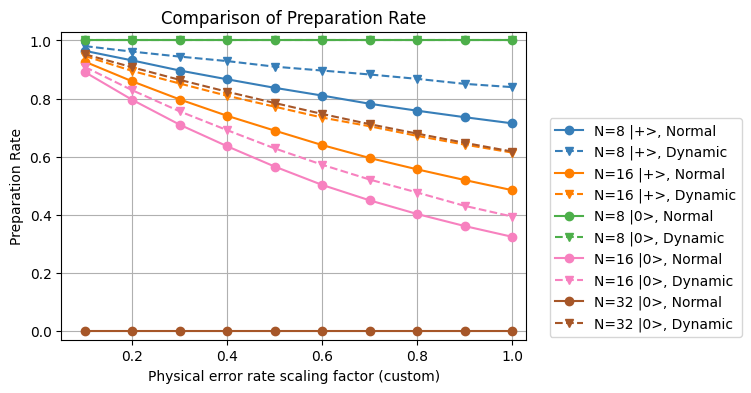

In [104]:
x_labels = None
# x_labels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0,]

df_4_n3_x = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n3_x")].copy()
df_4_n3_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n3_z_m")].copy()
df_4_n4_x = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_x_m")].copy()
# df_4_n4_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_z")].copy()
df_4_n4_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_z_13")].copy()
df_4_n5_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n5_z_m")].copy()


y_values = ['normal', 'dynamic']
legends = ["N=8 |+>, Normal", 
           "N=8 |+>, Dynamic",
           "N=16 |+>, Normal", 
           "N=16 |+>, Dynamic",
           "N=8 |0>, Normal", 
           "N=8 |0>, Dynamic",
           "N=16 |0>, Normal", 
           "N=16 |0>, Dynamic",
           "N=32 |0>, Normal", 
           "N=32 |0>, Dynamic",
           ]
x_lim=[0.05, 1.03]
y_lim=[-0.03,1.03]
legend_position=(0.01,0.01)
hw_name = "custom"
title="Comparison of Preparation Rate"
x_index = "noise_level"

linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':']

# print(y_values)
x_labels = None
dfs = [df_4_n3_x, df_4_n4_x, df_4_n3_z, df_4_n4_z, df_4_n5_z]

plt = show_figure_by_opt_combined(
    dfs, "type", y_values, "prep_rate", "Preparation Rate", f"Physical error rate scaling factor ({hw_name})", 
    legend=True, legends=legends, figsize=(6,4), reindex=None, x_index = "error_scale", 
    x_labels=x_labels, x_lim=x_lim, y_lim=y_lim,legend_position=(1.05,0.01),
    circuit_name = "prep_rate_2", hw_name = f"{hw_name}", title=title, log_val=False)

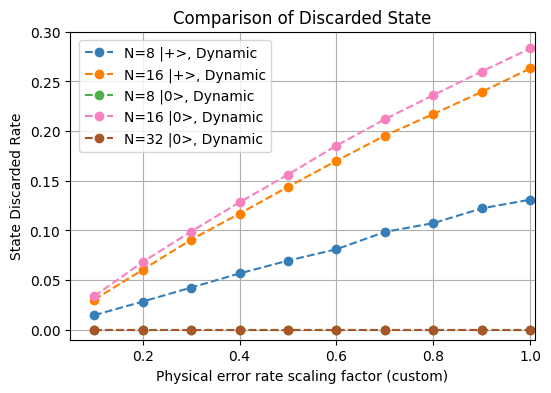

In [105]:
x_labels = None
# x_labels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0,]

df_4_n3_x = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n3_x")].copy()
df_4_n3_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n3_z_m")].copy()
df_4_n4_x = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_x_m")].copy()
# df_4_n4_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_z")].copy()
df_4_n4_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_z_13")].copy()
df_4_n5_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n5_z_m")].copy()


y_values = ['dynamic']
legends = [
           "N=8 |+>, Dynamic",
           "N=16 |+>, Dynamic",
           "N=8 |0>, Dynamic",
           "N=16 |0>, Dynamic",
           "N=32 |0>, Dynamic",
           ]
x_lim=[0.05, 1.01]
y_lim=[-0.01,0.3]
legend_position=(0.01,0.01)
hw_name = "custom"
title="Comparison of Discarded State"
x_index = "noise_level"

# print(y_values)
x_labels = None
dfs = [df_4_n3_x, df_4_n4_x, df_4_n3_z, df_4_n4_z, df_4_n5_z]


linestyles = ['--', '--', '-.', ':', '-', '--', '-.', ':']

plt = show_figure_by_opt_combined(
    dfs, "type", y_values, "total_discard", "State Discarded Rate", f"Physical error rate scaling factor ({hw_name})", 
    legend=True, legends=legends, figsize=(6,4), reindex=None, x_index = "error_scale", 
    x_labels=x_labels, x_lim=x_lim, y_lim=y_lim,legend_position=(0.02,0.61),
    circuit_name = "state_discard", hw_name = f"{hw_name}", title=title, log_val=False)

In [106]:
df_results = df_result.copy()
df_results[["circuit_name", "type", "shots"]]

df_pivoted = df_results.pivot(index=["circuit_name", "error_scale"], columns="type", values="shots")
df_pivoted["diff"] = df_pivoted["normal"] - df_pivoted["dynamic"] 
df_pivoted["adj"] = (df_pivoted["diff"] / df_pivoted["dynamic"]) + 1

df_shots = df_pivoted.reset_index().melt(
    id_vars=["circuit_name", "error_scale", "diff", "adj"],
    value_vars=["dynamic", "normal"],
    var_name="type",
    value_name="shots"
)
df_shots

df_shots.loc[(df_shots['circuit_name'] == "polar_all_meas_n4_z") & (df_shots['error_scale'] == 0.1) & (df_shots['type'] == "dynamic")]["adj"] 

df_shots.loc[
    (df_shots['circuit_name'] == "polar_all_meas_n4_z") &
    (df_shots['error_scale'] == 0.1) &
    (df_shots['type'] == "dynamic"),
    "adj"
] = 1.015229

In [107]:
df_shots.loc[(df_shots['circuit_name'] == "polar_all_meas_n4_z") & (df_shots['error_scale'] == 0.1) & (df_shots['type'] == "dynamic")]["adj"] 

df_shots

,circuit_name,error_scale,diff,adj,type,shots
0,polar_all_meas_n3_x,0.1,809,1.014929,dynamic,54191
1,polar_all_meas_n3_x,0.2,1561,1.029211,dynamic,53439
2,polar_all_meas_n3_x,0.3,2337,1.044377,dynamic,52663
3,polar_all_meas_n3_x,0.4,3118,1.060098,dynamic,51882
4,polar_all_meas_n3_x,0.5,3830,1.074849,dynamic,51170
...,...,...,...,...,...,...
115,polar_all_meas_n5_z_m,0.6,-1308000,0.000000,normal,0
116,polar_all_meas_n5_z_m,0.7,-1308000,0.000000,normal,0
117,polar_all_meas_n5_z_m,0.8,-1308000,0.000000,normal,0
118,polar_all_meas_n5_z_m,0.9,-1308000,0.000000,normal,0


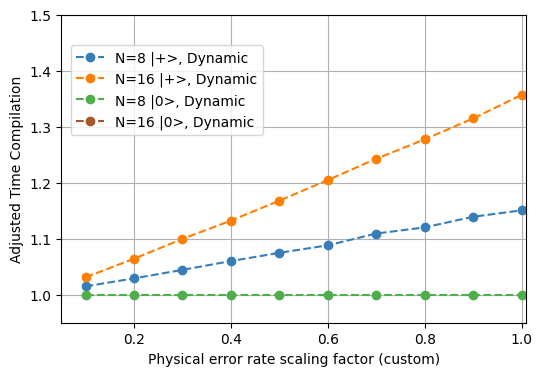

In [108]:
x_labels = None
# x_labels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0,]

df_4_n3_x = df_shots.loc[(df_shots['circuit_name'] == "polar_all_meas_n3_x")].copy()
df_4_n3_z = df_shots.loc[(df_shots['circuit_name'] == "polar_all_meas_n3_z_m")].copy()
df_4_n4_x = df_shots.loc[(df_shots['circuit_name'] == "polar_all_meas_n4_x_m")].copy()
# df_4_n4_z = df_shots.loc[(df_shots['circuit_name'] == "polar_all_meas_n4_z")].copy()
df_4_n4_z = df_shots.loc[(df_result['circuit_name'] == "polar_all_meas_n4_z_13")].copy()
df_4_n5_z = df_shots.loc[(df_shots['circuit_name'] == "polar_all_meas_n5_z_m")].copy()


y_values = ['dynamic']
legends = [
           "N=8 |+>, Dynamic",
           "N=16 |+>, Dynamic",
           "N=8 |0>, Dynamic",
           "N=16 |0>, Dynamic",
           "N=32 |0>, Dynamic",
           ]
x_lim=[0.05, 1.01]
y_lim=[0.95,1.5]
legend_position=(0.01,0.01)
hw_name = "custom"
# title="Comparison of Discarded State"
title=None
x_index = "noise_level"

# print(y_values)
x_labels = None
dfs = [df_4_n3_x, df_4_n4_x, df_4_n3_z, df_4_n4_z, df_4_n5_z]


linestyles = ['--', '--', '-.', ':', '-', '--', '-.', ':']

plt = show_figure_by_opt_combined(
    dfs, "type", y_values, "adj", "Adjusted Time Compilation", f"Physical error rate scaling factor ({hw_name})", 
    legend=True, legends=legends, figsize=(6,4), reindex=None, x_index = "error_scale", 
    x_labels=x_labels, x_lim=x_lim, y_lim=y_lim,legend_position=(0.02,0.61),
    circuit_name = "state_discard", hw_name = f"{hw_name}", title=title, log_val=False)

In [109]:
df_4_n3_x

,circuit_name,error_scale,diff,adj,type,shots
0,polar_all_meas_n3_x,0.1,809,1.014929,dynamic,54191
1,polar_all_meas_n3_x,0.2,1561,1.029211,dynamic,53439
2,polar_all_meas_n3_x,0.3,2337,1.044377,dynamic,52663
3,polar_all_meas_n3_x,0.4,3118,1.060098,dynamic,51882
4,polar_all_meas_n3_x,0.5,3830,1.074849,dynamic,51170
5,polar_all_meas_n3_x,0.6,4457,1.088182,dynamic,50543
6,polar_all_meas_n3_x,0.7,5418,1.109274,dynamic,49582
7,polar_all_meas_n3_x,0.8,5903,1.120231,dynamic,49097
8,polar_all_meas_n3_x,0.9,6721,1.139212,dynamic,48279
9,polar_all_meas_n3_x,1.0,7203,1.150700,dynamic,47797


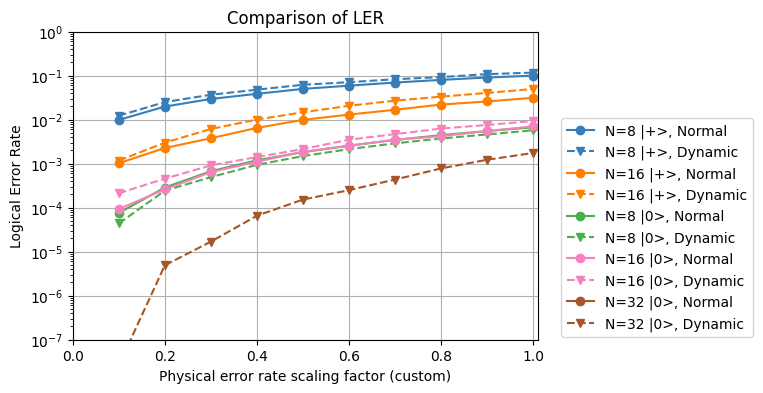

In [110]:
x_labels = None
# x_labels = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0,]

df_4_n3_x = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n3_x")].copy()
df_4_n3_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n3_z_m")].copy()
df_4_n4_x = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_x_m")].copy()
# df_4_n4_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_z")].copy()
df_4_n4_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n4_z_13")].copy()
df_4_n5_z = df_result.loc[(df_result['circuit_name'] == "polar_all_meas_n5_z_m")].copy()


y_values = ['normal', 'dynamic']
legends = ["N=8 |+>, Normal", 
           "N=8 |+>, Dynamic",
           "N=16 |+>, Normal", 
           "N=16 |+>, Dynamic",
           "N=8 |0>, Normal", 
           "N=8 |0>, Dynamic",
           "N=16 |0>, Normal", 
           "N=16 |0>, Dynamic",
           "N=32 |0>, Normal", 
           "N=32 |0>, Dynamic",
           ]
# legends = []
x_lim=[0, 1.01]
y_lim=[0.0000001,1]
legend_position=(0.01,0.01)
hw_name = "custom"
title="Comparison of LER"
x_index = "noise_level"

linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':']

# print(y_values)
x_labels = None
dfs = [df_4_n3_x, df_4_n4_x, df_4_n3_z, df_4_n4_z, df_4_n5_z]
# dfs = [df_4_n3_z, df_4_n4_z, df_4_n5_z]


plt = show_figure_by_opt_combined(
    dfs, "type", y_values, "ler", "Logical Error Rate", f"Physical error rate scaling factor ({hw_name})", 
    legend=True, legends=legends, figsize=(6,4), reindex=None, x_index = "error_scale", 
    x_labels=x_labels, x_lim=x_lim, y_lim=y_lim,legend_position=(1.05,0.01),
    circuit_name = "ler", hw_name = f"{hw_name}", title=title, log_val=True)

### $n=4$, $i=7$ for logical $|0\rangle$, b = 0110

In [ ]:
# seed_simulator = randint(1, 9999999)
# shots = 5000 
# size = 5
# qcs = [polar_n4_z_meas_data, qc_dynamic_n4_z]
# noise_level_dep_1q = 2.173e-4
# noise_level_dep_2q = 5.918e-3
# noise_level_meas   = 2.173e-2
# circuit_name = "n4_z"

# results_normal, results_dynamic = run_simulation_scaling_all(qcs, circuit_name, size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator)


### $n=4$, $i=6$ for logical $|+\rangle$, b = 1010

In [ ]:
# seed_simulator = randint(1, 9999999)
# shots = 5000 
# size = 5
# qcs = [polar_n4_x_meas_data, qc_dynamic_n4_x]
# noise_level_dep_1q = 2.173e-4
# noise_level_dep_2q = 5.918e-3
# noise_level_meas   = 2.173e-2
# circuit_name = "n4_x"

# results_normal, results_dynamic = run_simulation_scaling_all(qcs, circuit_name, size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator)




### $n=5$, $i=8$ for logical $|0\rangle$, b = 11100

In [ ]:
qc_dummy = QuantumCircuit(2,2)
qc_dummy.h(0)
qc_dummy.cx(0,1)
qc_dummy.measure([0,1],[0,1])

for i in range(1):
    seed_simulator = randint(1, 9999999)
    shots = 5000 
    size = 9

    # backend_grid = FakeGridBackend(rows=size, cols=size)

    # pm_custom = generate_preset_pass_manager(
    #         optimization_level=3, backend=backend_grid
    #     )

    # tqc_n5_z = pm_custom.run(polar_n5_z_meas_data)
    tqc_n5_z = pm.run(qc_dummy)

    tqc_h1s = [] 

    tmp = pm.run(qc_dynamic_n5_z)
    tqc_h1s.append(tmp)
    # print(tmp.count_ops())
    # print(get_initial_layout_from_circuit(tmp))

    used_qbts = get_initial_layout_from_circuit(tmp)

    for i in range(7):

        cm = backend.coupling_map
        cm = build_idle_coupling_map(cm, used_qbts)

        pm_3 = generate_preset_pass_manager(
                optimization_level=3, backend=backend, coupling_map=cm
            )
        tmp = pm_3.run(qc_dynamic_n5_z)
        tqc_h1s.append(tmp)

        # print(tmp.count_ops())
        # print(get_initial_layout_from_circuit(tmp))

        qbts = get_initial_layout_from_circuit(tmp)

        for q in qbts:
            used_qbts.append(q)


    qcs = [tqc_n5_z, tqc_h1s]

    noise_level_dep_1q = 2.173e-4
    noise_level_dep_2q = 5.918e-3
    noise_level_meas   = 2.173e-2
    circuit_name = "n5_z_m"

    n = 5
    lstate = "Z"
    results_normal, results_dynamic = run_simulation_scaling_all(qcs, circuit_name, size, shots, noise_level_dep_1q, noise_level_dep_2q, noise_level_meas, seed_simulator, memory=True)




